# Non-Higgs Model Diagnostics

Now, I am going to do a short convergence test through NEQs=8 for a random non-Higgs inflationary model. A viable model ($n_s$ range of interest) seems to appear when I have the following initial parameters for my base:

(Below was ran with seed set to 0 and phi=0)

$\phi$:

$H$:

$\epsilon$: 7.3957755954e-03

$\sigma$: 6.9439539348e-02

$\lambda_2$ (NEQs=5): 1.4308967742e-03

$\lambda_3$ (NEQs=6): 1.0695001459e-03

$\lambda_4$ (NEQs=7): 6.3157423789e-05

$\lambda_5$ (NEQs=8): -2.7942304326e-05


Let's include our imports below:

In [1]:
import numpy
import random
from scipy.integrate import solve_ivp
import pygsl.rng #random num generator
import pandas as pd
import matplotlib.pyplot as plt

import sys
import os
import glob


#Should modify the Python import path at runtime
sys.path.append('/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/InflationModels')

import numpy as np
import random
from scipy.integrate import solve_ivp
import pygsl.rng #random num generator
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm


from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import re

from scipy.interpolate import UnivariateSpline, splrep, splev, CubicSpline, interp1d, PchipInterpolator, InterpolatedUnivariateSpline
import numdifftools as nd
from scipy.integrate import cumulative_trapezoid, solve_ivp, odeint


from pathlib import Path



# Convergence Tests for Non-Higgs Model

For the cells below these were run for models that vary only the last slow roll parameter.

In [77]:
LAM_BASE = {
    6: ("lam3", 5.7446484628e-06),
    7: ("lam4",  1.7216377653e-04),
    8: ("lam5", -2.7942304326e-05),
}

#To pull base files 

def get_base_dir(NEQS, param_name, base_value, base_path_root):
    val_str = f"{base_value:.10e}"
    folder = os.path.join(
        base_path_root,
        f"neqs{NEQS}",
        f"{param_name}_{val_str}"
    )

    if not os.path.exists(folder):
        raise FileNotFoundError(f"Missing base folder: {folder}")

    return folder


#We can upload them like so which will print which ones we are uploading:
base_path_root = "/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests"

base_dirs = {}

for NEQS, (param_name, base_val) in LAM_BASE.items():
    folder = get_base_dir(NEQS, param_name, base_val, base_path_root)
    base_dirs[NEQS] = {
        "param_name": param_name,
        "value": base_val,
        "folder": folder
    }

    print(f"NEQS={NEQS}: {folder}")
    
#And then we can check out their observables and N_end
def load_base_summary_row(NEQS, param_name, base_value, base_path_root):
    summary_file = f"{base_path_root}/neqs{NEQS}/neqs{NEQS}_summary.csv"
    df = pd.read_csv(summary_file)

    idx = np.argmin(np.abs(df[param_name] - base_value))
    return df.iloc[idx]

rows = []

for NEQS, (param_name, base_val) in LAM_BASE.items():
    row = load_base_summary_row(NEQS, param_name, base_val, base_path_root)

    rows.append({
        "NEQS": NEQS,
        "param": param_name,
        "value": row[param_name],
        "n_s": row["n_s"],
        "r": row["r"],
        "original_N_end": row["original_N_end"],
        "spectrum_N_start": row["spectrum_N_start"],
        "path_N_end": row["path_N_end"],
    })

base_summary_df = pd.DataFrame(rows)
print(base_summary_df.to_string(index=False))

#Compare relative to 6 base
ref = base_summary_df.loc[base_summary_df["NEQS"] == 6, "original_N_end"].iloc[0]

base_summary_df["delta_N_vs_NEQS6"] = (
    base_summary_df["original_N_end"] - ref
)


#This will print the information
print(base_summary_df.to_string(index=False))

NEQS=6: /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests/neqs6/lam3_5.7446484628e-06
NEQS=7: /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests/neqs7/lam4_1.7216377653e-04
NEQS=8: /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests/neqs8/lam5_-2.7942304326e-05
 NEQS param     value      n_s        r  original_N_end  spectrum_N_start  path_N_end
    6  lam3  0.000006 0.960860 0.007277      700.652205          0.000157        60.0
    7  lam4  0.000172 0.962031 0.000095      746.540732          0.000157        60.0
    8  lam5 -0.000028 0.963624 0.000049      757.902354          0.000156        60.0
 NEQS param     value      n_s        r  original_N_end  spectrum_N_start  path_N_end  delta_N_vs_NEQS6
    6  lam3  0.000006 0.960860 0.007277      700.652205 

## Functions that will get re-used

In [78]:
SCAN_INFO = {
    5: ("lam2",  r"\lambda_2"),
    6: ("lam3",  r"\lambda_3"),
    7: ("lam4",  r"\lambda_4"),
    8: ("lam5",  r"\lambda_5"),
    9: ("lam6",  r"\lambda_6"),
    10: ("lam7", r"\lambda_7"),
    11: ("lam8", r"\lambda_8"),
    12: ("lam9", r"\lambda_9"),
    13: ("lam10", r"\lambda_{10}"),
}

colors = {
    5: "mediumseagreen",
    6: "lightskyblue",
    7: "paleturquoise",
    8: "thistle",
    9: "pink",
}

def load_path_data(NEQS, param_name, value):
    val_str = f"{value:.10e}"
    folder = os.path.join(
        base_path_root,
        f"neqs{NEQS}",
        f"{param_name}_{val_str}",
    )
    file_path = os.path.join(
        folder,
        f"path_neqs{NEQS}_{param_name}_{val_str}.dat",
    )
    return pd.read_csv(file_path, sep=r"\s+", header=None).values

def folder_for(NEQS, param_name, value):
    val_str = f"{value:.10e}"
    return os.path.join(
        base_path_root,
        f"neqs{NEQS}",
        f"{param_name}_{val_str}"
    )

def load_specs(NEQS, param_name, value):
    folder = folder_for(NEQS, param_name, value)

    s = np.loadtxt(os.path.join(folder, f"spec_s_neqs{NEQS}.dat"))
    t = np.loadtxt(os.path.join(folder, f"spec_t_neqs{NEQS}.dat"))

    k_s = s[:, 0]
    Ps = np.abs(s[:, 1])

    k_t = t[:, 0]
    Pt = np.abs(t[:, 1])

    return k_s, Ps, k_t, Pt


    
def prepare_increasing(x, y):
    x = np.asarray(x)
    y = np.asarray(y)
    order = np.argsort(x)
    return x[order], y[order]

def normalize_curve_at_Nref(N, Y, N_ref=60.0, ref_floor=1e-20):
    N_use, Y_use = prepare_increasing(N, Y)

    if not (N_use.min() <= N_ref <= N_use.max()):
        raise ValueError(
            f"N_ref={N_ref} outside range [{N_use.min()}, {N_use.max()}]"
        )

    Y_ref = np.interp(N_ref, N_use, Y_use)

    if np.abs(Y_ref) < ref_floor:
        raise ValueError(f"Reference too small: {Y_ref:.3e}")

    return N_use, Y_use / Y_ref, Y_ref

def normalize_at_ref(k, P):
        k, P = prepare_increasing(k, P)
        P_ref = np.interp(k_ref, k, P)
        return k, P / P_ref, P_ref


def fractional_difference_on_overlap(x, y, x_ref, y_ref, frac_floor=1e-30):
    x, y = prepare_increasing(x, y)
    x_ref, y_ref = prepare_increasing(x_ref, y_ref)

    xmin = max(np.min(x), np.min(x_ref))
    xmax = min(np.max(x), np.max(x_ref))

    mask = (x >= xmin) & (x <= xmax)

    x_use = x[mask]
    y_use = y[mask]

    y_ref_interp = np.interp(x_use, x_ref, y_ref)

    frac = (y_use - y_ref_interp) / np.where(
        np.abs(y_ref_interp) > frac_floor,
        y_ref_interp,
        np.nan,
    )

    return x_use, frac


def get_base_dir(NEQS, param_name, base_value, base_path_root):
    val_str = f"{base_value:.10e}"
    folder = os.path.join(
        base_path_root,
        f"neqs{NEQS}",
        f"{param_name}_{val_str}"
    )

    if not os.path.exists(folder):
        raise FileNotFoundError(f"Missing base folder: {folder}")

    return folder



def get_param_values_from_dirs(NEQS, param_name, base_path_root, show_summary=True):
    base_path = f"{base_path_root}/neqs{NEQS}"
    pattern = os.path.join(base_path, f"{param_name}_*")
    dirs = glob.glob(pattern)

    values = []

    for d in dirs:
        try:
            base = os.path.basename(d)
            val_str = base.replace(f"{param_name}_", "")
            val = float(val_str)
            label = rf"${param_name} = {val:.1e}$"
            values.append((val, label))
        except Exception as e:
            print(f"Skipping {d}: {e}")

    values.sort(key=lambda x: x[0])

    if show_summary:
        print(f"\n{'='*60}")
        print(f"Summary for NEQS={NEQS}, parameter={param_name}")
        print(f"{'='*60}")
        print(f"Total models found: {len(values)}")
        if len(values) > 0:
            print(f"Parameter range: {values[0][0]:.3e} to {values[-1][0]:.3e}")
        else:
            print("Parameter range: none found")
        print(f"{'='*60}\n")

    return values


## BEFORE SHIFTING

In [79]:
def plot_HV_shape_only_with_frac_error_limitedN(
    base_path_root,
    save_name=None,
    suptitle=None,
    N_ref=60.0,
    ref_floor=1e-20,
    frac_floor=1e-30,
    N_min=20.0,
    N_max=60.0,
):
    plt.rcParams.update({
        "text.usetex": False,
        "mathtext.fontset": "cm",
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman", "DejaVu Serif"],
        "axes.labelsize": 20,
        "axes.titlesize": 18,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 12,
        "figure.titlesize": 22,
        "axes.linewidth": 1.3,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
    })

    base_models = {
#         6: ("lam3", 0.0),
        7: ("lam4",  1.7216377653e-04),
        8: ("lam5", -2.7942304326e-05),
    }
    
    
    def apply_N_window(N, Y):
        mask = (N >= N_min) & (N <= N_max)
        return N[mask], Y[mask]

    model_data = {}

    for NEQS, (param_name, base_value) in base_models.items():
        data = load_path_data(NEQS, param_name, base_value)

        N = data[:, NEQS]
        H = data[:, 1]
        V = data[:, NEQS + 1]

        N_H, H_norm, Hstar = normalize_curve_at_Nref(
            N,
            H,
            N_ref=N_ref,
            ref_floor=ref_floor,
        )

        N_V, V_norm, Vstar = normalize_curve_at_Nref(
            N,
            V,
            N_ref=N_ref,
            ref_floor=ref_floor,
        )

        N_H, H_norm = apply_N_window(N_H, H_norm)
        N_V, V_norm = apply_N_window(N_V, V_norm)

        model_data[NEQS] = {
            "N_H": N_H,
            "H_norm": H_norm,
            "H_ref": Hstar,

            "N_V": N_V,
            "V_norm": V_norm,
            "V_ref": Vstar,

            "param_name": param_name,
            "base_value": base_value,
        }

    ref_curve = model_data[7]

    fig, axs = plt.subplots(
        2,
        2,
        figsize=(18, 10),
        constrained_layout=True,
    )

    ax_H, ax_V = axs[0]
    ax_dH, ax_dV = axs[1]

    # -------------------------------------------------
    # Top row: normalized H and V
    # -------------------------------------------------
    for NEQS, d in model_data.items():
        label = rf"NEQS={NEQS}, ${d['param_name']}={d['base_value']:.2e}$"

        ax_H.plot(
            d["N_H"],
            d["H_norm"],
            lw=2.4,
            color=colors[NEQS],
            label=label,
        )

        ax_V.plot(
            d["N_V"],
            d["V_norm"],
            lw=2.4,
            color=colors[NEQS],
            label=label,
        )

    ax_H.set_title(rf"Shape-only Hubble evolution: $H/H(N={N_ref})$")
    ax_V.set_title(rf"Shape-only potential evolution: $V/V(N={N_ref})$")

    ax_H.set_ylabel(rf"$H/H(N={N_ref})$")
    ax_V.set_ylabel(rf"$V/V(N={N_ref})$")

    # -------------------------------------------------
    # Bottom row: fractional differences vs NEQS=6
    # -------------------------------------------------
    for NEQS, d in model_data.items():
        N_use_H, frac_H = fractional_difference_on_overlap(
            d["N_H"],
            d["H_norm"],
            ref_curve["N_H"],
            ref_curve["H_norm"],
            frac_floor=frac_floor,
        )

        N_use_V, frac_V = fractional_difference_on_overlap(
            d["N_V"],
            d["V_norm"],
            ref_curve["N_V"],
            ref_curve["V_norm"],
            frac_floor=frac_floor,
        )

        ax_dH.plot(
            N_use_H,
            100.0 * frac_H,
            lw=2.2,
            color=colors[NEQS],
            label=rf"NEQS={NEQS}",
        )

        ax_dV.plot(
            N_use_V,
            100.0 * frac_V,
            lw=2.2,
            color=colors[NEQS],
            label=rf"NEQS={NEQS}",
        )

    ax_dH.axhline(0.0, color="black", linestyle="--", lw=1.1, alpha=0.65)
    ax_dV.axhline(0.0, color="black", linestyle="--", lw=1.1, alpha=0.65)

    ax_dH.set_title(r"Fractional difference in $H(N)$ relative to NEQS=6")
    ax_dV.set_title(r"Fractional difference in $V(N)$ relative to NEQS=6")

    ax_dH.set_xlabel(r"$N$")
    ax_dV.set_xlabel(r"$N$")

    ax_dH.set_ylabel(r"$100\times\Delta H/H_{\rm NEQS=6}$")
    ax_dV.set_ylabel(r"$100\times\Delta V/V_{\rm NEQS=6}$")

    # -------------------------------------------------
    # Styling
    # -------------------------------------------------
    for ax in axs.ravel():
        ax.invert_xaxis()
        ax.grid(True, which="major", alpha=0.25)
        ax.grid(True, which="minor", alpha=0.12)
        ax.minorticks_on()

        handles, labels = ax.get_legend_handles_labels()
        if len(handles) > 0:
            ax.legend(frameon=False, fontsize=11)

    if suptitle is None:
        suptitle = rf"Base-model background convergence over ${N_min}<N<{N_max}$"

    fig.suptitle(suptitle, fontsize=22)

    if save_name is None:
        save_name = "HV_shape_only_windowed_with_frac_errors.png"

    plt.savefig(save_name, dpi=300, bbox_inches="tight")
    plt.show()

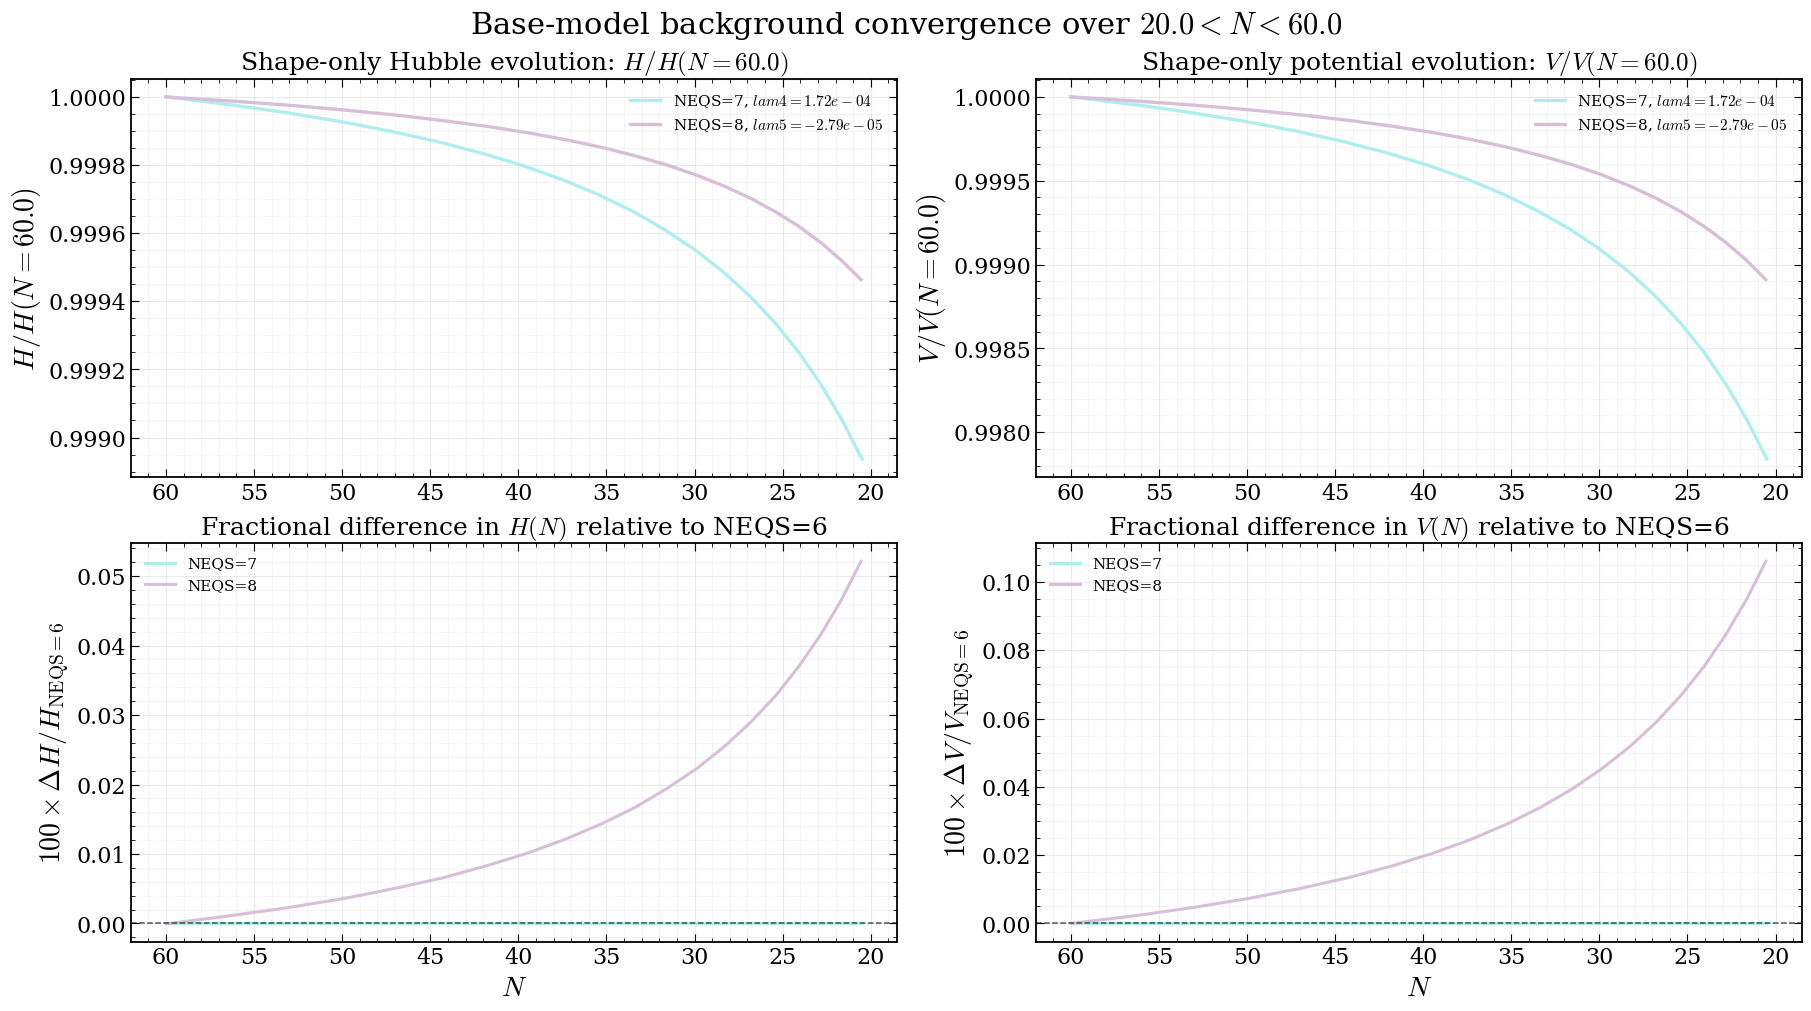

In [80]:
plot_HV_shape_only_with_frac_error_limitedN(
    base_path_root=base_path_root,
    N_ref=60.0,
    N_min=20.0,
    N_max=60.0,
    save_name="HV_shape_only_windowed_with_frac_errors.png",
    
)



In [81]:
def plot_base_spectra_overlay_with_frac_errors(
    base_path_root,
    base_params=None,
    ref_NEQS=6,
    k_ref=0.05,
    k_min_scalar=1e-4,
    k_max_scalar=1e-1,
    normalize=True,
    tolerance=5.0,
    save_name=None,
    show=True,
):
    if base_params is None:

        base_params = {
    #         6: ("lam3", 0.0),
            7: ("lam4",  1.7216377653e-04),
            8: ("lam5", -2.7942304326e-05),
        }
    

    plt.rcParams.update({
        "text.usetex": False,
        "mathtext.fontset": "cm",
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman", "DejaVu Serif"],
        "axes.labelsize": 20,
        "axes.titlesize": 18,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 12,
        "figure.titlesize": 22,
        "axes.linewidth": 1.3,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
    })

    def folder_for(NEQS, param_name, value):
        val_str = f"{value:.10e}"
        return os.path.join(
            base_path_root,
            f"neqs{NEQS}",
            f"{param_name}_{val_str}",
        )

    def load_specs_local(NEQS, param_name, value):
        folder = folder_for(NEQS, param_name, value)

        s = np.loadtxt(os.path.join(folder, f"spec_s_neqs{NEQS}.dat"))
        t = np.loadtxt(os.path.join(folder, f"spec_t_neqs{NEQS}.dat"))

        k_s, Ps = prepare_increasing(s[:, 0], np.abs(s[:, 1]))
        k_t, Pt = prepare_increasing(t[:, 0], np.abs(t[:, 1]))

        return k_s, Ps, k_t, Pt

    def normalize_at_ref(k, P):
        k, P = prepare_increasing(k, P)

        if not (k.min() <= k_ref <= k.max()):
            raise ValueError(
                f"k_ref={k_ref} outside range [{k.min():.3e}, {k.max():.3e}]"
            )

        P_ref = np.interp(k_ref, k, P)

        if np.abs(P_ref) < 1e-30:
            raise ValueError(f"Reference spectrum too small at k={k_ref}")

        return k, P / P_ref, P_ref

    def frac_on_ref_grid(k_ref_grid, P_ref, k_cmp, P_cmp, kmin=None, kmax=None):
        k_ref_grid, P_ref = prepare_increasing(k_ref_grid, P_ref)
        k_cmp, P_cmp = prepare_increasing(k_cmp, P_cmp)

        xmin = max(k_ref_grid.min(), k_cmp.min())
        xmax = min(k_ref_grid.max(), k_cmp.max())

        if kmin is not None:
            xmin = max(xmin, kmin)

        if kmax is not None:
            xmax = min(xmax, kmax)

        mask = (k_ref_grid >= xmin) & (k_ref_grid <= xmax)

        k_use = k_ref_grid[mask]
        P_ref_use = P_ref[mask]

        if len(k_use) == 0:
            raise ValueError("No overlapping k range for fractional error.")

        P_cmp_interp = np.interp(k_use, k_cmp, P_cmp)

        frac = (P_cmp_interp - P_ref_use) / P_ref_use

        return k_use, frac

    # Load reference model
    ref_param, ref_value = base_params[ref_NEQS]

    k_s_ref_raw, Ps_ref_raw, k_t_ref_raw, Pt_ref_raw = load_specs_local(
        ref_NEQS,
        ref_param,
        ref_value,
    )

    if normalize:
        k_s_ref, Ps_ref, _ = normalize_at_ref(k_s_ref_raw, Ps_ref_raw)
        k_t_ref, Pt_ref, _ = normalize_at_ref(k_t_ref_raw, Pt_ref_raw)
        ylab_s = rf"$P_s/P_s(k={k_ref})$"
        ylab_t = rf"$P_t/P_t(k={k_ref})$"
    else:
        k_s_ref, Ps_ref = prepare_increasing(k_s_ref_raw, Ps_ref_raw)
        k_t_ref, Pt_ref = prepare_increasing(k_t_ref_raw, Pt_ref_raw)
        ylab_s = r"$P_s(k)$"
        ylab_t = r"$P_t(k)$"

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(18, 12),
        constrained_layout=True,
    )

    ax_s, ax_t = axes[0]
    ax_s_err, ax_t_err = axes[1]

    rows = []

    for NEQS, (param_name, value) in base_params.items():
        k_s_raw, Ps_raw, k_t_raw, Pt_raw = load_specs_local(
            NEQS,
            param_name,
            value,
        )

        if normalize:
            k_s, Ps_plot, _ = normalize_at_ref(k_s_raw, Ps_raw)
            k_t, Pt_plot, _ = normalize_at_ref(k_t_raw, Pt_raw)
        else:
            k_s, Ps_plot = prepare_increasing(k_s_raw, Ps_raw)
            k_t, Pt_plot = prepare_increasing(k_t_raw, Pt_raw)

        color = colors.get(NEQS, None)
        label = rf"NEQS={NEQS}, ${param_name}={value:.2e}$"

        scalar_mask = np.ones_like(k_s, dtype=bool)

        if k_min_scalar is not None:
            scalar_mask &= k_s >= k_min_scalar

        if k_max_scalar is not None:
            scalar_mask &= k_s <= k_max_scalar

        ax_s.loglog(
            k_s[scalar_mask],
            Ps_plot[scalar_mask],
            color=color,
            lw=2.3,
            label=label,
        )

        ax_t.loglog(
            k_t,
            Pt_plot,
            color=color,
            lw=2.3,
            label=label,
        )

        k_s_err, frac_s = frac_on_ref_grid(
            k_s_ref,
            Ps_ref,
            k_s,
            Ps_plot,
            kmin=k_min_scalar,
            kmax=k_max_scalar,
        )

        k_t_err, frac_t = frac_on_ref_grid(
            k_t_ref,
            Pt_ref,
            k_t,
            Pt_plot,
            kmin=None,
            kmax=None,
        )

        ax_s_err.semilogx(
            k_s_err,
            100.0 * frac_s,
            color=color,
            lw=2.0,
            label=rf"NEQS={NEQS}",
        )

        ax_t_err.semilogx(
            k_t_err,
            100.0 * frac_t,
            color=color,
            lw=2.0,
            label=rf"NEQS={NEQS}",
        )

        rows.append({
            "NEQS": NEQS,
            "param_name": param_name,
            "value": value,
            "mean_abs_dPs_pct": 100.0 * np.nanmean(np.abs(frac_s)),
            "max_abs_dPs_pct": 100.0 * np.nanmax(np.abs(frac_s)),
            "mean_abs_dPt_pct": 100.0 * np.nanmean(np.abs(frac_t)),
            "max_abs_dPt_pct": 100.0 * np.nanmax(np.abs(frac_t)),
        })

    # Reference lines
    ax_s.axvline(k_ref, color="black", ls=":", lw=1.2, alpha=0.7)
    ax_t.axvline(k_ref, color="black", ls=":", lw=1.2, alpha=0.7)

    for ax in [ax_s_err, ax_t_err]:
        ax.axhline(0.0, color="black", ls="--", lw=1.0, alpha=0.7)
        ax.axhline(
            tolerance,
            color="black",
            ls=":",
            lw=1.4,
            alpha=0.8,
            label=rf"${tolerance:.0f}\%$ tolerance",
        )
        ax.axhline(
            -tolerance,
            color="black",
            ls=":",
            lw=1.4,
            alpha=0.8,
        )

    ax_s.set_title(r"Base scalar spectra")
    ax_t.set_title(r"Base tensor spectra")
    ax_s_err.set_title(rf"Scalar fractional difference relative to NEQS={ref_NEQS}")
    ax_t_err.set_title(rf"Tensor fractional difference relative to NEQS={ref_NEQS}")

    ax_s.set_xlabel(r"$k$")
    ax_t.set_xlabel(r"$k$")
    ax_s_err.set_xlabel(r"$k$")
    ax_t_err.set_xlabel(r"$k$")

    ax_s.set_ylabel(ylab_s)
    ax_t.set_ylabel(ylab_t)
    ax_s_err.set_ylabel(r"$100\times\Delta P_s/P_{s,\rm NEQS=6}$")
    ax_t_err.set_ylabel(r"$100\times\Delta P_t/P_{t,\rm NEQS=6}$")

    ax_s.set_xlim(k_min_scalar, k_max_scalar)
    ax_s_err.set_xlim(k_min_scalar, k_max_scalar)

    for ax in axes.ravel():
        ax.grid(True, which="major", alpha=0.25)
        ax.grid(True, which="minor", alpha=0.12)
        ax.minorticks_on()
        ax.legend(frameon=False, fontsize=11)

    fig.suptitle(
        rf"Base-model spectra convergence relative to NEQS={ref_NEQS}",
        fontsize=22,
    )

    if save_name is None:
        save_name = "base_spectra_convergence_with_fractional_errors.png"

    plt.savefig(save_name, dpi=300, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close(fig)

    summary_df = pd.DataFrame(rows)

    print("\n=== Base spectra convergence summary ===")
    print(summary_df.to_string(index=False))

    return summary_df

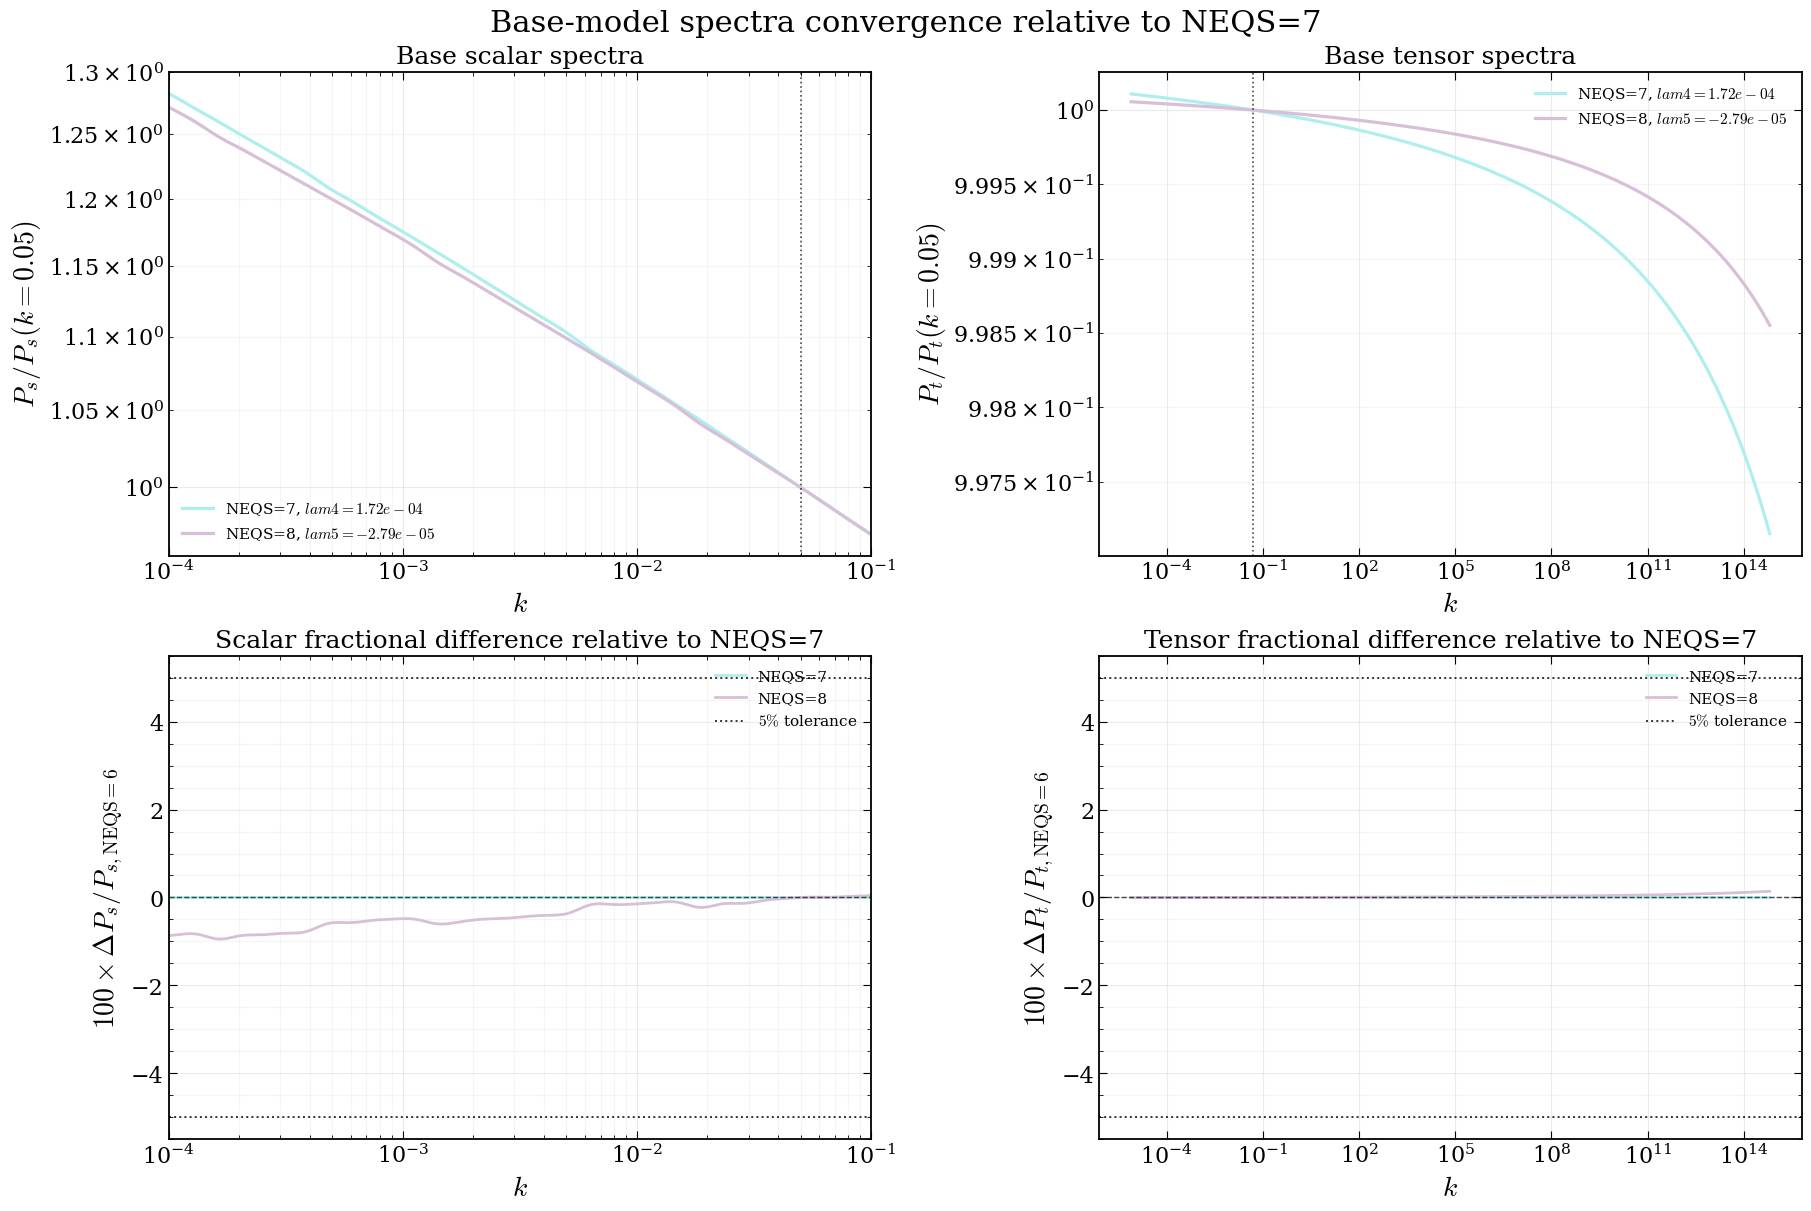


=== Base spectra convergence summary ===
 NEQS param_name     value  mean_abs_dPs_pct  max_abs_dPs_pct  mean_abs_dPt_pct  max_abs_dPt_pct
    7       lam4  0.000172          0.000000         0.000000          0.000000         0.000000
    8       lam5 -0.000028          0.408376         0.945806          0.029806         0.140374


In [82]:
base_spectra_summary_df = plot_base_spectra_overlay_with_frac_errors(
    base_path_root=base_path_root, 
    
    base_params = {
#         6: ("lam3", 0.0),
        7: ("lam4",  1.7216377653e-04),
        8: ("lam5", -2.7942304326e-05),
    },
    
    ref_NEQS=7,
    k_ref=0.05,
    k_min_scalar=1e-4,
    k_max_scalar=1e-1,
    tolerance=5.0,
    save_name="base_spectra_convergence_relative_to_neqs6_preshift.png",
)

In [83]:
def plot_base_spectra_derivative_convergence(
    base_path_root,
    base_params=None,
    ref_NEQS=6,
    k_min_plot_s=1e-4,
    k_max_plot_s=1e-1,
    k_min_plot_t=None,
    k_max_plot_t=None,
    smoothing=0.0,
    tolerance=5.0,
    save_name=None,
    show=True,
):
    if base_params is None:
        base_params = {
#         6: ("lam3", 0.0),
        7: ("lam4",  1.7216377653e-04),
        8: ("lam5", -2.7942304326e-05),
    },

    plt.rcParams.update({
        "text.usetex": False,
        "mathtext.fontset": "cm",
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman", "DejaVu Serif"],

        "axes.labelsize": 20,
        "axes.titlesize": 18,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 12,
        "figure.titlesize": 22,

        "axes.linewidth": 1.3,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
    })

    def folder_for(NEQS, param_name, value):
        val_str = f"{value:.10e}"
        return os.path.join(
            base_path_root,
            f"neqs{NEQS}",
            f"{param_name}_{val_str}",
        )

    def load_specs_local(NEQS, param_name, value):
        folder = folder_for(NEQS, param_name, value)

        s = np.loadtxt(os.path.join(folder, f"spec_s_neqs{NEQS}.dat"))
        t = np.loadtxt(os.path.join(folder, f"spec_t_neqs{NEQS}.dat"))

        k_s, Ps = prepare_increasing(s[:, 0], np.abs(s[:, 1]))
        k_t, Pt = prepare_increasing(t[:, 0], np.abs(t[:, 1]))

        return k_s, Ps, k_t, Pt

    def prepare_log_spline(k, P, smoothing=0.0):
        k = np.asarray(k)
        P = np.asarray(P)

        mask = (
            (k > 0)
            & (P > 0)
            & np.isfinite(k)
            & np.isfinite(P)
        )

        k = k[mask]
        P = P[mask]

        order = np.argsort(k)
        k = k[order]
        P = P[order]

        x = np.log(k)
        y = np.log(P)

        x_unique = np.unique(x)
        y_unique = np.array([np.mean(y[x == xu]) for xu in x_unique])

        if len(x_unique) < 4:
            raise ValueError("Need at least 4 unique k values for cubic spline.")

        spl = UnivariateSpline(x_unique, y_unique, s=smoothing, k=3)

        d1 = spl.derivative(1)(x_unique)

        return np.exp(x_unique), d1

    def apply_k_window(k, y, kmin=None, kmax=None):
        mask = np.ones_like(k, dtype=bool)

        if kmin is not None:
            mask &= k >= kmin

        if kmax is not None:
            mask &= k <= kmax

        return k[mask], y[mask]

    def frac_on_ref_grid(k_ref, y_ref, k_cmp, y_cmp, floor=1e-30):
        k_ref, y_ref = prepare_increasing(k_ref, y_ref)
        k_cmp, y_cmp = prepare_increasing(k_cmp, y_cmp)

        xmin = max(k_ref.min(), k_cmp.min())
        xmax = min(k_ref.max(), k_cmp.max())

        mask = (k_ref >= xmin) & (k_ref <= xmax)

        k_use = k_ref[mask]
        y_ref_use = y_ref[mask]

        if len(k_use) == 0:
            raise ValueError("No overlapping k range for derivative comparison.")

        y_cmp_interp = np.interp(k_use, k_cmp, y_cmp)

        frac = (y_cmp_interp - y_ref_use) / np.where(
            np.abs(y_ref_use) > floor,
            y_ref_use,
            np.nan,
        )

        return k_use, frac

    # -------------------------------------------------
    # Reference derivatives
    # -------------------------------------------------
    ref_param, ref_value = base_params[ref_NEQS]

    k_s_ref_raw, Ps_ref_raw, k_t_ref_raw, Pt_ref_raw = load_specs_local(
        ref_NEQS,
        ref_param,
        ref_value,
    )

    k_s_ref, dlnPs_ref = prepare_log_spline(
        k_s_ref_raw,
        Ps_ref_raw,
        smoothing=smoothing,
    )

    k_t_ref, dlnPt_ref = prepare_log_spline(
        k_t_ref_raw,
        Pt_ref_raw,
        smoothing=smoothing,
    )

    # -------------------------------------------------
    # Figure
    # -------------------------------------------------
    fig, axes = plt.subplots(
        2,
        2,
        figsize=(18, 12),
        constrained_layout=True,
    )

    ax_dPs, ax_dPt = axes[0]
    ax_errPs, ax_errPt = axes[1]

    rows = []

    for NEQS, (param_name, value) in base_params.items():
        k_s_raw, Ps_raw, k_t_raw, Pt_raw = load_specs_local(
            NEQS,
            param_name,
            value,
        )

        k_s, dlnPs = prepare_log_spline(
            k_s_raw,
            Ps_raw,
            smoothing=smoothing,
        )

        k_t, dlnPt = prepare_log_spline(
            k_t_raw,
            Pt_raw,
            smoothing=smoothing,
        )

        color = colors.get(NEQS, None)
        label = rf"NEQS={NEQS}, ${param_name}={value:.2e}$"

        k_s_plot, dlnPs_plot = apply_k_window(
            k_s,
            dlnPs,
            kmin=k_min_plot_s,
            kmax=k_max_plot_s,
        )

        k_t_plot, dlnPt_plot = apply_k_window(
            k_t,
            dlnPt,
            kmin=k_min_plot_t,
            kmax=k_max_plot_t,
        )

        ax_dPs.semilogx(
            k_s_plot,
            dlnPs_plot,
            color=color,
            lw=2.4,
            alpha=0.95,
            label=label,
        )

        ax_dPt.semilogx(
            k_t_plot,
            dlnPt_plot,
            color=color,
            lw=2.4,
            alpha=0.95,
            label=label,
        )

        k_s_err, frac_s = frac_on_ref_grid(
            k_s_ref,
            dlnPs_ref,
            k_s,
            dlnPs,
        )

        k_t_err, frac_t = frac_on_ref_grid(
            k_t_ref,
            dlnPt_ref,
            k_t,
            dlnPt,
        )

        k_s_err, frac_s = apply_k_window(
            k_s_err,
            frac_s,
            kmin=k_min_plot_s,
            kmax=k_max_plot_s,
        )

        k_t_err, frac_t = apply_k_window(
            k_t_err,
            frac_t,
            kmin=k_min_plot_t,
            kmax=k_max_plot_t,
        )

        ax_errPs.semilogx(
            k_s_err,
            100.0 * frac_s,
            color=color,
            lw=2.2,
            alpha=0.95,
            label=rf"NEQS={NEQS}",
        )

        ax_errPt.semilogx(
            k_t_err,
            100.0 * frac_t,
            color=color,
            lw=2.2,
            alpha=0.95,
            label=rf"NEQS={NEQS}",
        )

        rows.append({
            "NEQS": NEQS,
            "param_name": param_name,
            "value": value,
            "mean_abs_dlnPs_pct": 100.0 * np.nanmean(np.abs(frac_s)),
            "max_abs_dlnPs_pct": 100.0 * np.nanmax(np.abs(frac_s)),
            "mean_abs_dlnPt_pct": 100.0 * np.nanmean(np.abs(frac_t)),
            "max_abs_dlnPt_pct": 100.0 * np.nanmax(np.abs(frac_t)),
        })

    # -------------------------------------------------
    # Reference/tolerance lines
    # -------------------------------------------------
    for ax in [ax_dPs, ax_dPt]:
        ax.axhline(
            0.0,
            color="black",
            ls="--",
            lw=1.0,
            alpha=0.55,
        )

    for ax in [ax_errPs, ax_errPt]:
        ax.axhline(
            0.0,
            color="black",
            ls="--",
            lw=1.0,
            alpha=0.65,
        )

        ax.axhline(
            tolerance,
            color="black",
            ls=":",
            lw=1.5,
            alpha=0.8,
        )

        ax.axhline(
            -tolerance,
            color="black",
            ls=":",
            lw=1.5,
            alpha=0.8,
        )

        ax.text(
            0.97,
            0.92,
            rf"$\pm {tolerance:.0f}\%$",
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=11,
            bbox=dict(
                facecolor="white",
                edgecolor="none",
                alpha=0.80,
            ),
        )

    # -------------------------------------------------
    # Labels
    # -------------------------------------------------
    ax_dPs.set_title(r"Scalar spectral derivative")
    ax_dPt.set_title(r"Tensor spectral derivative")

    ax_errPs.set_title(rf"Scalar derivative difference relative to NEQS={ref_NEQS}")
    ax_errPt.set_title(rf"Tensor derivative difference relative to NEQS={ref_NEQS}")

    ax_dPs.set_ylabel(r"$d\ln P_s/d\ln k$")
    ax_dPt.set_ylabel(r"$d\ln P_t/d\ln k$")

    ax_errPs.set_ylabel(
        rf"$100\times\Delta(d\ln P_s/d\ln k)/(d\ln P_s/d\ln k)_{{\rm NEQS={ref_NEQS}}}$"
    )

    ax_errPt.set_ylabel(
        rf"$100\times\Delta(d\ln P_t/d\ln k)/(d\ln P_t/d\ln k)_{{\rm NEQS={ref_NEQS}}}$"
    )

    for ax in axes.ravel():
        ax.set_xlabel(r"$k$")
        ax.grid(True, which="major", alpha=0.25)
        ax.grid(True, which="minor", alpha=0.12)
        ax.minorticks_on()

        handles, labels = ax.get_legend_handles_labels()
        if len(handles) > 0:
            ax.legend(
                frameon=False,
                fontsize=11,
                loc="best",
            )

    if k_min_plot_s is not None or k_max_plot_s is not None:
        xmin_s = k_min_plot_s if k_min_plot_s is not None else k_s_ref.min()
        xmax_s = k_max_plot_s if k_max_plot_s is not None else k_s_ref.max()
        ax_dPs.set_xlim(xmin_s, xmax_s)
        ax_errPs.set_xlim(xmin_s, xmax_s)

    if k_min_plot_t is not None or k_max_plot_t is not None:
        xmin_t = k_min_plot_t if k_min_plot_t is not None else k_t_ref.min()
        xmax_t = k_max_plot_t if k_max_plot_t is not None else k_t_ref.max()
        ax_dPt.set_xlim(xmin_t, xmax_t)
        ax_errPt.set_xlim(xmin_t, xmax_t)

    fig.suptitle(
        rf"B-spline derivative convergence of base spectra relative to NEQS={ref_NEQS}",
        fontsize=22,
    )

    if save_name is None:
        save_name = "base_spectra_derivative_convergence.png"

    plt.savefig(save_name, dpi=300, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close(fig)

    summary_df = pd.DataFrame(rows)

    print("\n=== Base spectra derivative convergence summary ===")
    print(summary_df.to_string(index=False))

    return summary_df



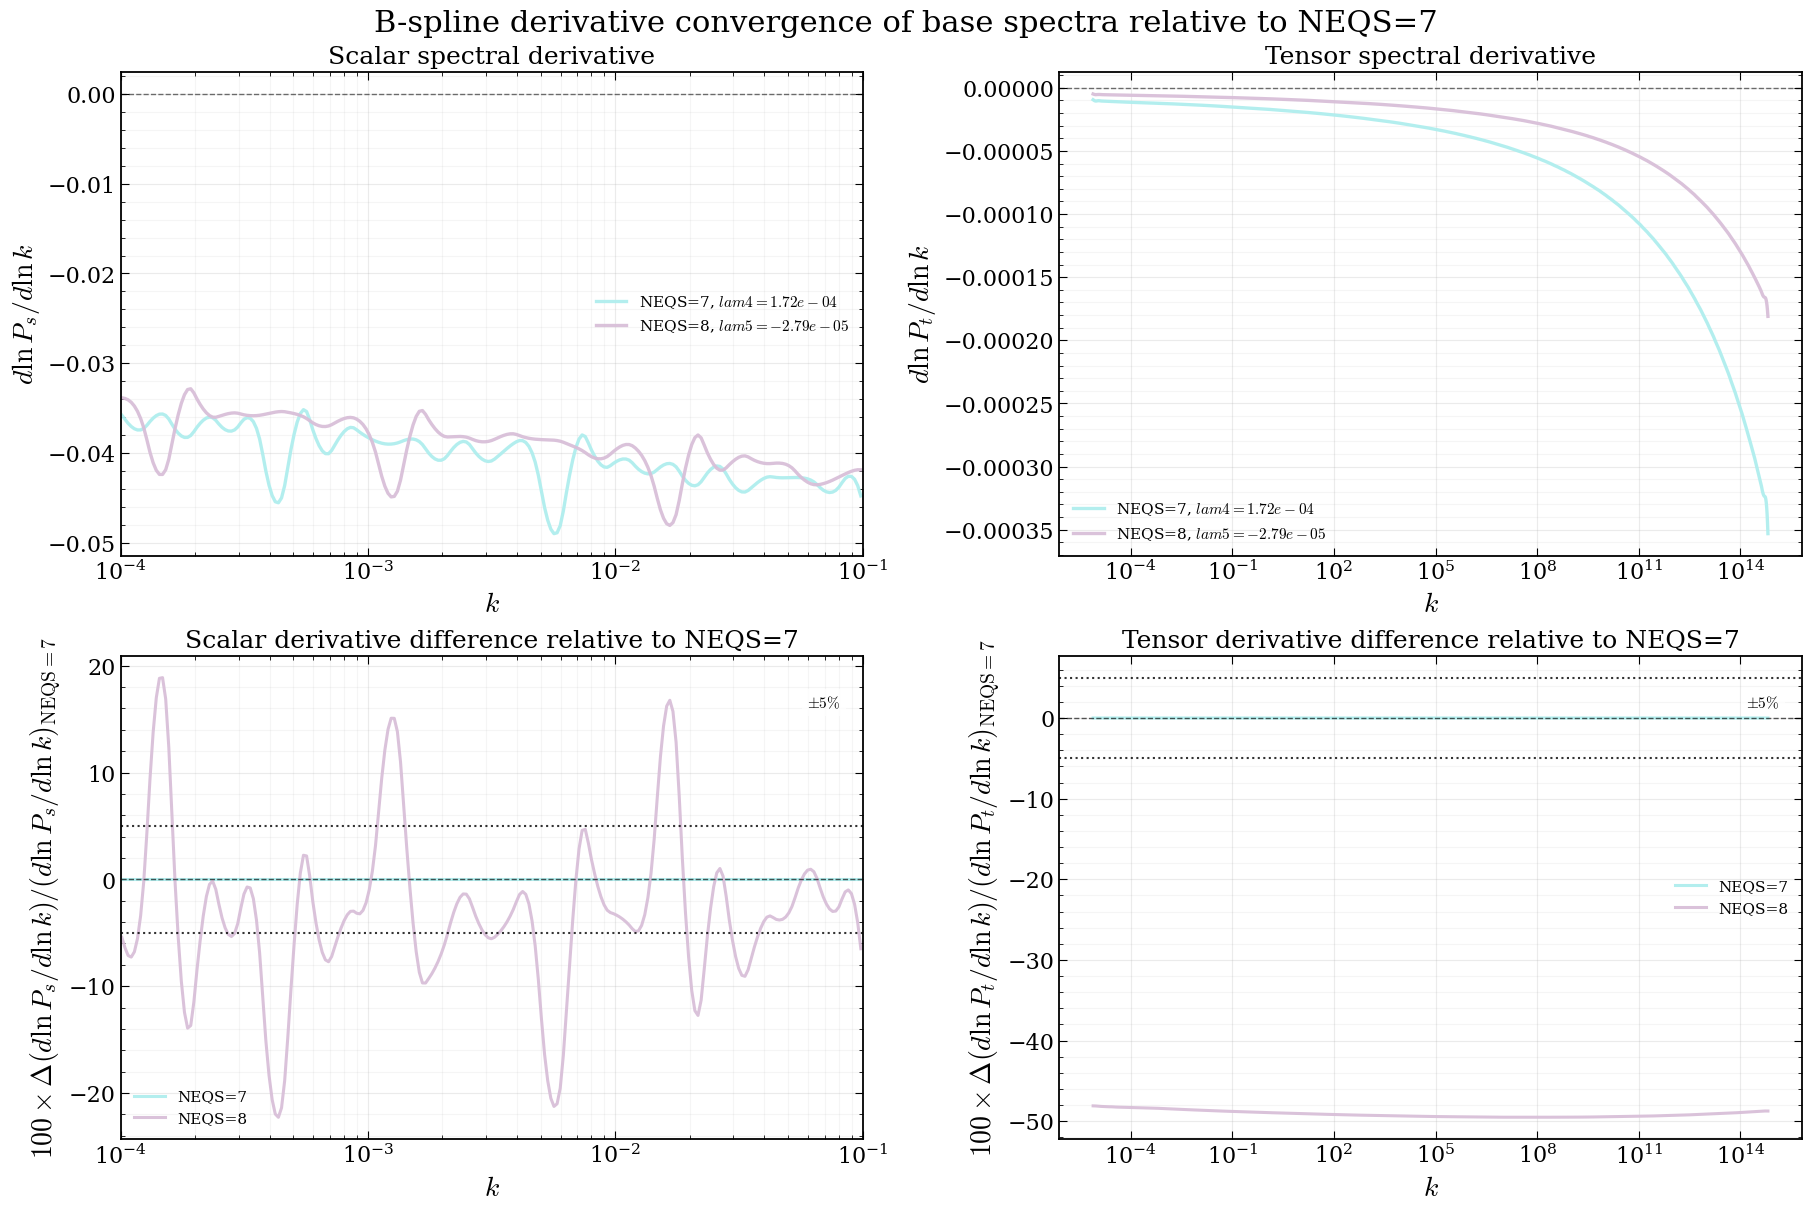


=== Base spectra derivative convergence summary ===
 NEQS param_name     value  mean_abs_dlnPs_pct  max_abs_dlnPs_pct  mean_abs_dlnPt_pct  max_abs_dlnPt_pct
    7       lam4  0.000172            0.000000           0.000000            0.000000           0.000000
    8       lam5 -0.000028            6.147193          22.276677           49.088045          49.508666


In [84]:
deriv_summary_df = plot_base_spectra_derivative_convergence(
    base_path_root=base_path_root,
    base_params = {
#         6: ("lam3", 0.0),
        7: ("lam4",  1.7216377653e-04),
        8: ("lam5", -2.7942304326e-05),
    },
    ref_NEQS=7,
    k_min_plot_s=1e-4,
    k_max_plot_s=1e-1,
    k_min_plot_t=None,
    k_max_plot_t=None,
    smoothing=0.0,
    tolerance=5.0,
    save_name="base_spectra_derivative_convergence_neqs6_8.png",
)

## AFTER SHIFTING

In [85]:
def test_k_shift_equivalence_scalar_tensor(
    base_path_root,
    base_params,
    base_summary_df,
    ref_NEQS=6,
    k_norm=0.05,
    k_min_scalar=1e-4,
    k_max_scalar=1e-1,
    tolerance=5.0,
    save_name=None,
    show=True,
):
    plt.rcParams.update({
        "text.usetex": False,
        "mathtext.fontset": "cm",
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman", "DejaVu Serif"],
        "axes.labelsize": 20,
        "axes.titlesize": 18,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 12,
        "figure.titlesize": 22,
        "axes.linewidth": 1.3,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
    })

    def load_specs(NEQS, param, val):
        val_str = f"{val:.10e}"
        folder = os.path.join(
            base_path_root,
            f"neqs{NEQS}",
            f"{param}_{val_str}",
        )

        s = np.loadtxt(os.path.join(folder, f"spec_s_neqs{NEQS}.dat"))
        t = np.loadtxt(os.path.join(folder, f"spec_t_neqs{NEQS}.dat"))

        k_s, Ps = prepare_increasing(s[:, 0], np.abs(s[:, 1]))
        k_t, Pt = prepare_increasing(t[:, 0], np.abs(t[:, 1]))

        return k_s, Ps, k_t, Pt

    def normalize_at_k(k, P, k_ref):
        k, P = prepare_increasing(k, P)

        if not (k.min() <= k_ref <= k.max()):
            raise ValueError(
                f"k_ref={k_ref} outside range [{k.min():.3e}, {k.max():.3e}]"
            )

        P_ref = np.interp(k_ref, k, P)

        if np.abs(P_ref) < 1e-30:
            raise ValueError(f"Reference spectrum too small at k={k_ref}")

        return P / P_ref

    def frac_on_ref_grid(k_ref_grid, P_ref_norm, k_cmp, P_cmp_norm, kmin=None, kmax=None):
        k_ref_grid, P_ref_norm = prepare_increasing(k_ref_grid, P_ref_norm)
        k_cmp, P_cmp_norm = prepare_increasing(k_cmp, P_cmp_norm)

        xmin = max(k_ref_grid.min(), k_cmp.min())
        xmax = min(k_ref_grid.max(), k_cmp.max())

        if kmin is not None:
            xmin = max(xmin, kmin)

        if kmax is not None:
            xmax = min(xmax, kmax)

        if xmin >= xmax:
            return np.array([]), np.array([])

        mask = (k_ref_grid >= xmin) & (k_ref_grid <= xmax)
        k_use = k_ref_grid[mask]

        if len(k_use) == 0:
            return np.array([]), np.array([])

        P_ref_use = P_ref_norm[mask]
        P_cmp_interp = np.interp(k_use, k_cmp, P_cmp_norm)

        frac = (P_cmp_interp - P_ref_use) / P_ref_use

        return k_use, frac

    ref_param, ref_val = base_params[ref_NEQS]

    k_s_ref, Ps_ref_raw, k_t_ref, Pt_ref_raw = load_specs(
        ref_NEQS,
        ref_param,
        ref_val,
    )

    Ps_ref = normalize_at_k(k_s_ref, Ps_ref_raw, k_norm)
    Pt_ref = normalize_at_k(k_t_ref, Pt_ref_raw, k_norm)

    ref_N_end = base_summary_df.loc[
        base_summary_df["NEQS"] == ref_NEQS,
        "original_N_end",
    ].iloc[0]

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(18, 12),
        constrained_layout=True,
    )

    ax_s, ax_t = axes[0]
    ax_s_err, ax_t_err = axes[1]

    scalar_ref_mask = np.ones_like(k_s_ref, dtype=bool)
    scalar_ref_mask &= k_s_ref >= k_min_scalar
    scalar_ref_mask &= k_s_ref <= k_max_scalar

    ax_s.loglog(
        k_s_ref[scalar_ref_mask],
        Ps_ref[scalar_ref_mask],
        lw=3.2,
        color="black",
        linestyle="--",
        label=rf"NEQS={ref_NEQS} reference",
    )

    ax_t.loglog(
        k_t_ref,
        Pt_ref,
        lw=3.2,
        color="black",
        linestyle="--",
        label=rf"NEQS={ref_NEQS} reference",
    )

    rows = []

    for NEQS, (param, val) in base_params.items():
        if NEQS == ref_NEQS:
            continue

        N_end = base_summary_df.loc[
            base_summary_df["NEQS"] == NEQS,
            "original_N_end",
        ].iloc[0]

        deltaN = N_end - ref_N_end

        print(f"NEQS={NEQS}")
        print(f"  N_end  = {N_end:.6f}")
        print(f"  deltaN = {deltaN:.6f}")
        print(f"  exp(-deltaN) = {np.exp(-deltaN):.6e}")

        k_s, Ps, k_t, Pt = load_specs(NEQS, param, val)

        k_s_shifted = k_s * np.exp(-deltaN)
        k_t_shifted = k_t * np.exp(-deltaN)

        Ps_shifted_norm = normalize_at_k(k_s_shifted, Ps, k_norm)
        Pt_shifted_norm = normalize_at_k(k_t_shifted, Pt, k_norm)

        color = colors.get(NEQS, None)
        label = rf"NEQS={NEQS}, $\Delta N={deltaN:.2f}$"

        scalar_mask = np.ones_like(k_s_shifted, dtype=bool)
        scalar_mask &= k_s_shifted >= k_min_scalar
        scalar_mask &= k_s_shifted <= k_max_scalar

        ax_s.loglog(
            k_s_shifted[scalar_mask],
            Ps_shifted_norm[scalar_mask],
            lw=2.5,
            linestyle="-",
            color=color,
            label=label,
        )

        ax_t.loglog(
            k_t_shifted,
            Pt_shifted_norm,
            lw=2.5,
            linestyle="-",
            color=color,
            label=label,
        )

        k_s_frac, frac_s = frac_on_ref_grid(
            k_s_ref,
            Ps_ref,
            k_s_shifted,
            Ps_shifted_norm,
            kmin=k_min_scalar,
            kmax=k_max_scalar,
        )

        k_t_frac, frac_t = frac_on_ref_grid(
            k_t_ref,
            Pt_ref,
            k_t_shifted,
            Pt_shifted_norm,
            kmin=None,
            kmax=None,
        )

        ax_s_err.semilogx(
            k_s_frac,
            100.0 * frac_s,
            lw=2.2,
            color=color,
            label=rf"NEQS={NEQS}",
        )

        ax_t_err.semilogx(
            k_t_frac,
            100.0 * frac_t,
            lw=2.2,
            color=color,
            label=rf"NEQS={NEQS}",
        )

        rows.append({
            "NEQS": NEQS,
            "param": param,
            "value": val,
            "original_N_end": N_end,
            "deltaN_from_ref": deltaN,
            "mean_abs_dPs_pct": 100.0 * np.nanmean(np.abs(frac_s)),
            "max_abs_dPs_pct": 100.0 * np.nanmax(np.abs(frac_s)),
            "mean_abs_dPt_pct": 100.0 * np.nanmean(np.abs(frac_t)),
            "max_abs_dPt_pct": 100.0 * np.nanmax(np.abs(frac_t)),
        })

    for ax in [ax_s, ax_t]:
        ax.axvline(
            k_norm,
            color="black",
            ls=":",
            lw=1.3,
            alpha=0.7,
        )

    for ax in [ax_s_err, ax_t_err]:
        ax.axhline(0.0, color="black", ls="--", lw=1.1, alpha=0.7)

        ax.axhline(
            tolerance,
            color="black",
            ls=":",
            lw=1.4,
            alpha=0.85,
        )

        ax.axhline(
            -tolerance,
            color="black",
            ls=":",
            lw=1.4,
            alpha=0.85,
        )

        ax.text(
            0.97,
            0.92,
            rf"$\pm {tolerance:.0f}\%$",
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=11,
            bbox=dict(
                facecolor="white",
                edgecolor="none",
                alpha=0.85,
            ),
        )

    ax_s.set_title(r"Scalar spectra after $k \rightarrow k e^{-\Delta N}$")
    ax_t.set_title(r"Tensor spectra after $k \rightarrow k e^{-\Delta N}$")

    ax_s_err.set_title(rf"Scalar fractional difference relative to NEQS={ref_NEQS}")
    ax_t_err.set_title(rf"Tensor fractional difference relative to NEQS={ref_NEQS}")

    ax_s.set_xlabel(r"shifted $k$")
    ax_t.set_xlabel(r"shifted $k$")
    ax_s_err.set_xlabel(r"shifted $k$")
    ax_t_err.set_xlabel(r"shifted $k$")

    ax_s.set_ylabel(rf"$P_s/P_s(k={k_norm})$")
    ax_t.set_ylabel(rf"$P_t/P_t(k={k_norm})$")

    ax_s_err.set_ylabel(rf"$100\times\Delta P_s/P_{{s,\rm NEQS={ref_NEQS}}}$")
    ax_t_err.set_ylabel(rf"$100\times\Delta P_t/P_{{t,\rm NEQS={ref_NEQS}}}$")

    ax_s.set_xlim(k_min_scalar, k_max_scalar)
    ax_s_err.set_xlim(k_min_scalar, k_max_scalar)

    for ax in axes.ravel():
        ax.grid(True, which="major", alpha=0.25)
        ax.grid(True, which="minor", alpha=0.12)
        ax.minorticks_on()

        handles, labels = ax.get_legend_handles_labels()
        if len(handles) > 0:
            ax.legend(frameon=False, fontsize=11, loc="lower left")

    fig.suptitle(
        r"Testing whether base spectra differ mainly by a $k$-shift",
        fontsize=22,
    )

    if save_name is not None:
        plt.savefig(save_name, dpi=300, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close(fig)

    summary_df = pd.DataFrame(rows)

    print("\n=== Shifted base spectra summary ===")
    print(summary_df.to_string(index=False))

    return summary_df




NEQS=8
  N_end  = 757.902354
  deltaN = 11.361622
  exp(-deltaN) = 1.163350e-05


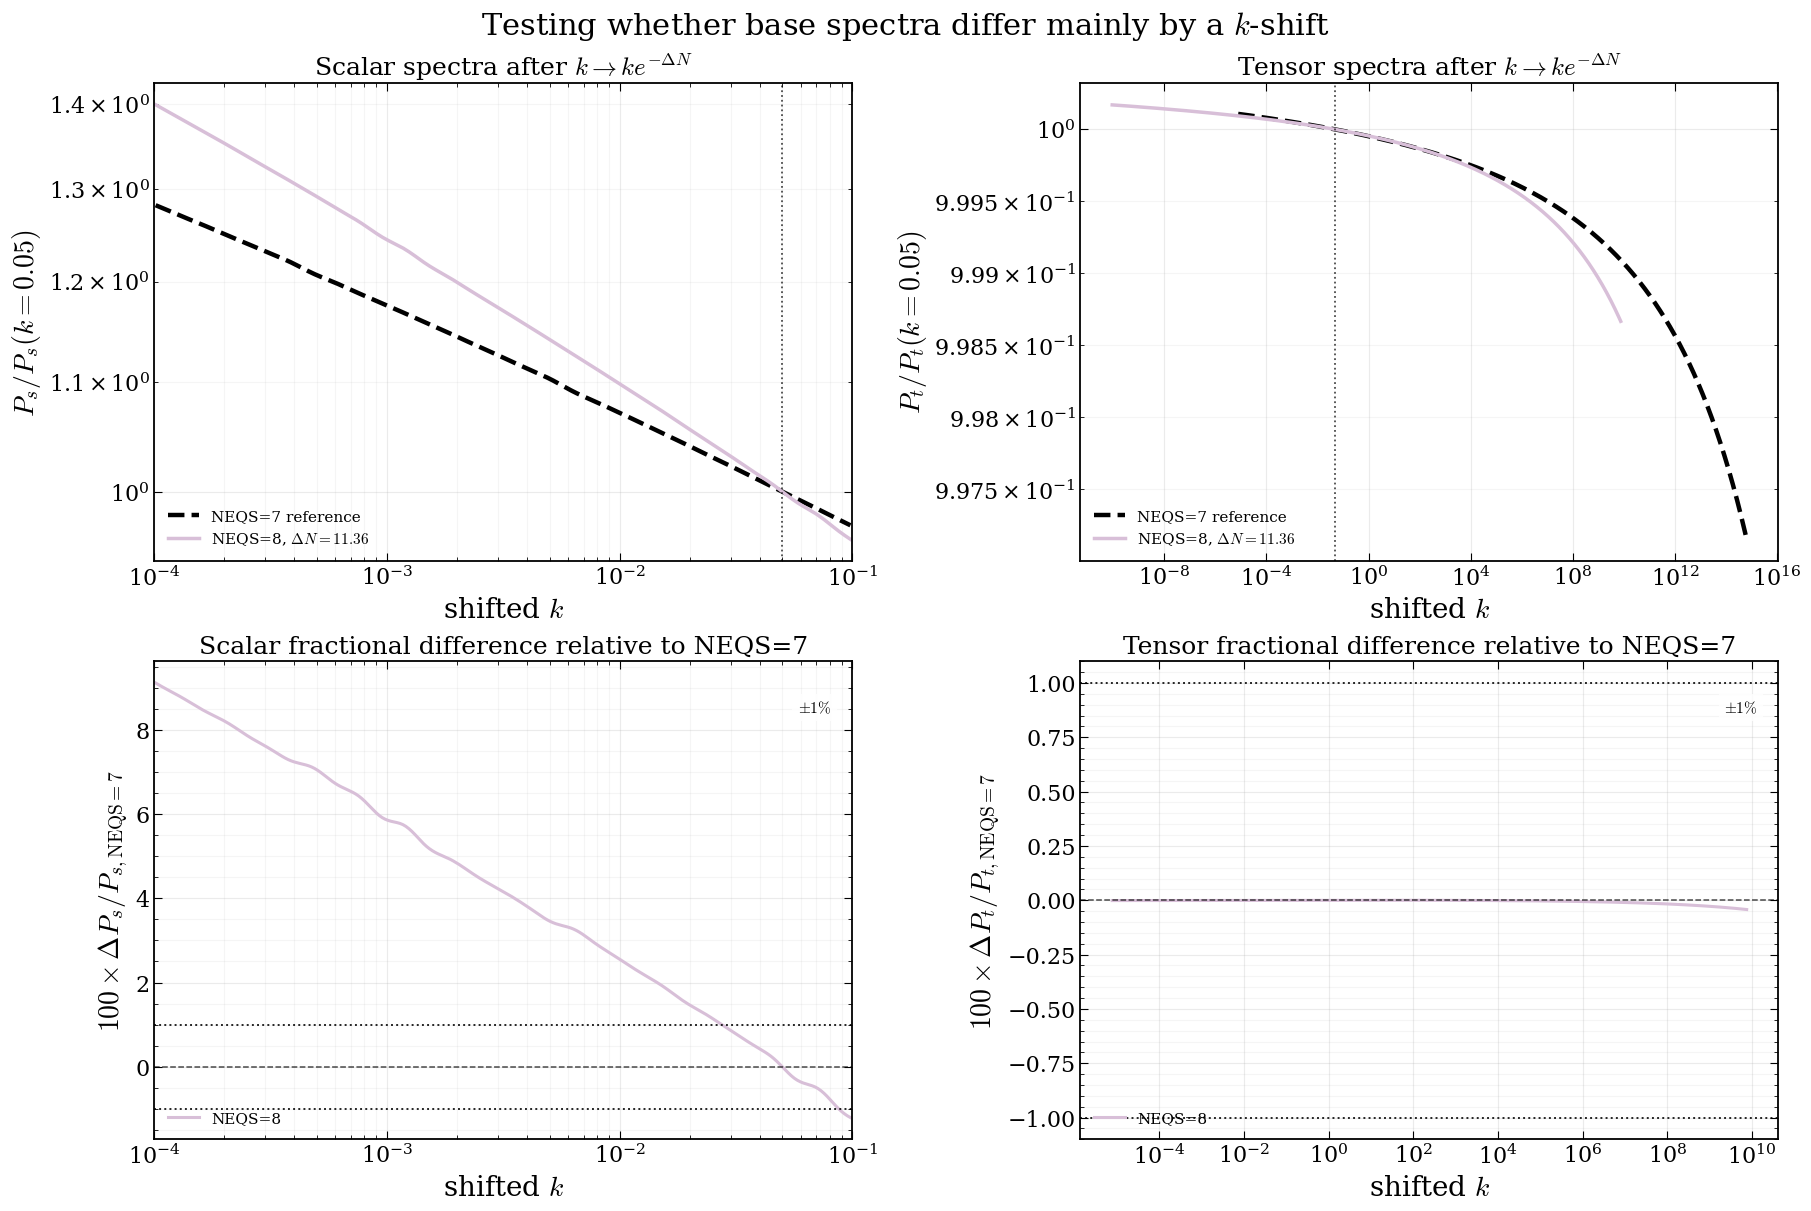


=== Shifted base spectra summary ===
 NEQS param     value  original_N_end  deltaN_from_ref  mean_abs_dPs_pct  max_abs_dPs_pct  mean_abs_dPt_pct  max_abs_dPt_pct
    8  lam5 -0.000028      757.902354        11.361622          4.288155         9.113247          0.005631         0.042612


In [86]:
BASE_PARAMS = {
#        6: ("lam3", 0.0),
        7: ("lam4",  1.7216377653e-04),
        8: ("lam5", -2.7942304326e-05),
    }

kshift_summary_df = test_k_shift_equivalence_scalar_tensor(
    base_path_root=base_path_root,
    base_params=BASE_PARAMS,
    base_summary_df=base_summary_df,
    ref_NEQS=7,
    k_norm=0.05,
    k_min_scalar=1e-4,
    k_max_scalar=1e-1,
    tolerance=1.0,
    save_name="base_scalar_tensor_kshift_equivalence_relative_to_neqs7.png",
)



In [87]:
def plot_base_spectra_derivatives_bspline_2x2_kshifted(
    base_path_root,
    base_summary_df,
    base_params=None,
    ref_NEQS=6,
    apply_k_shift=True,
    k_min_plot_s=1e-4,
    k_max_plot_s=1e-1,
    k_min_plot_t=None,
    k_max_plot_t=None,
    smoothing=0.0,
    save_name=None,
    show=True,
):
    if base_params is None:
        base_params = {
#        6: ("lam3", 0.0),
        7: ("lam4",  1.7216377653e-04),
        8: ("lam5", -2.7942304326e-05),
    }
        
    plt.rcParams.update({
        "text.usetex": False,
        "mathtext.fontset": "cm",
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman", "DejaVu Serif"],

        "axes.labelsize": 20,
        "axes.titlesize": 18,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 12,
        "figure.titlesize": 22,

        "axes.linewidth": 1.3,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
    })

    def get_N_end(summary_df, NEQS):
        matches = summary_df.loc[summary_df["NEQS"].astype(int) == int(NEQS)]

        if len(matches) == 0:
            raise ValueError(f"No original_N_end found for NEQS={NEQS}")

        return float(matches.iloc[0]["original_N_end"])

    def prepare_log_spline(k, P, smoothing=0.0):
        k = np.asarray(k)
        P = np.asarray(P)

        mask = (
            (k > 0)
            & (P > 0)
            & np.isfinite(k)
            & np.isfinite(P)
        )

        k = k[mask]
        P = P[mask]

        order = np.argsort(k)
        k = k[order]
        P = P[order]

        x = np.log(k)
        y = np.log(P)

        x_unique = np.unique(x)
        y_unique = np.array([
            np.mean(y[x == xu]) for xu in x_unique
        ])

        if len(x_unique) < 4:
            raise ValueError("Need at least 4 unique k values for cubic spline.")

        spl = UnivariateSpline(x_unique, y_unique, s=smoothing, k=3)

        d1 = spl.derivative(1)(x_unique)
        d2 = spl.derivative(2)(x_unique)

        return np.exp(x_unique), d1, d2

    def apply_k_window(k, y, kmin=None, kmax=None):
        mask = np.ones_like(k, dtype=bool)

        if kmin is not None:
            mask &= k >= kmin

        if kmax is not None:
            mask &= k <= kmax

        return k[mask], y[mask]

    ref_N_end = get_N_end(base_summary_df, ref_NEQS)

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(18, 12),
        constrained_layout=True,
    )

    ax_d1Ps, ax_d1Pt = axes[0]
    ax_d2Ps, ax_d2Pt = axes[1]

    rows = []

    for NEQS, (param_name, value) in base_params.items():
        k_s, Ps, k_t, Pt = load_specs(NEQS, param_name, value)

        if apply_k_shift:
            N_end = get_N_end(base_summary_df, NEQS)
            deltaN = N_end - ref_N_end

            k_s = k_s * np.exp(-deltaN)
            k_t = k_t * np.exp(-deltaN)
        else:
            N_end = get_N_end(base_summary_df, NEQS)
            deltaN = 0.0

        k_s_use, d1Ps, d2Ps = prepare_log_spline(
            k_s,
            Ps,
            smoothing=smoothing,
        )

        k_t_use, d1Pt, d2Pt = prepare_log_spline(
            k_t,
            Pt,
            smoothing=smoothing,
        )

        k_s_d1, d1Ps_plot = apply_k_window(
            k_s_use,
            d1Ps,
            kmin=k_min_plot_s,
            kmax=k_max_plot_s,
        )

        k_s_d2, d2Ps_plot = apply_k_window(
            k_s_use,
            d2Ps,
            kmin=k_min_plot_s,
            kmax=k_max_plot_s,
        )

        k_t_d1, d1Pt_plot = apply_k_window(
            k_t_use,
            d1Pt,
            kmin=k_min_plot_t,
            kmax=k_max_plot_t,
        )

        k_t_d2, d2Pt_plot = apply_k_window(
            k_t_use,
            d2Pt,
            kmin=k_min_plot_t,
            kmax=k_max_plot_t,
        )

        color = colors.get(NEQS, None)

        if apply_k_shift:
            label = rf"NEQS={NEQS}, $\Delta N={deltaN:.2f}$"
        else:
            label = rf"NEQS={NEQS}"

        ax_d1Ps.semilogx(
            k_s_d1,
            d1Ps_plot,
            color=color,
            lw=2.4,
            alpha=0.95,
            label=label,
        )

        ax_d1Pt.semilogx(
            k_t_d1,
            d1Pt_plot,
            color=color,
            lw=2.4,
            alpha=0.95,
            label=label,
        )

        ax_d2Ps.semilogx(
            k_s_d2,
            d2Ps_plot,
            color=color,
            lw=2.4,
            alpha=0.95,
            label=label,
        )

        ax_d2Pt.semilogx(
            k_t_d2,
            d2Pt_plot,
            color=color,
            lw=2.4,
            alpha=0.95,
            label=label,
        )

        rows.append({
            "NEQS": NEQS,
            "param_name": param_name,
            "value": value,
            "original_N_end": N_end,
            "deltaN_from_ref": deltaN,
            "exp_minus_deltaN": np.exp(-deltaN),
            "k_s_min_shifted": np.nanmin(k_s_use),
            "k_s_max_shifted": np.nanmax(k_s_use),
            "k_t_min_shifted": np.nanmin(k_t_use),
            "k_t_max_shifted": np.nanmax(k_t_use),
        })

    shift_label = (
        r"$k \rightarrow k e^{-\Delta N}$"
        if apply_k_shift
        else r"no $k$ shift"
    )

    # Titles
    ax_d1Ps.set_title(rf"Scalar first derivative after {shift_label}")
    ax_d1Pt.set_title(rf"Tensor first derivative after {shift_label}")
    ax_d2Ps.set_title(rf"Scalar second derivative after {shift_label}")
    ax_d2Pt.set_title(rf"Tensor second derivative after {shift_label}")

    # Labels
    ax_d1Ps.set_ylabel(r"$d\ln P_s/d\ln k$")
    ax_d1Pt.set_ylabel(r"$d\ln P_t/d\ln k$")
    ax_d2Ps.set_ylabel(r"$d^2\ln P_s/d(\ln k)^2$")
    ax_d2Pt.set_ylabel(r"$d^2\ln P_t/d(\ln k)^2$")

    for ax in axes.ravel():
        ax.axhline(
            0.0,
            color="black",
            ls="--",
            lw=1.0,
            alpha=0.55,
        )

        ax.set_xlabel(r"shifted $k$" if apply_k_shift else r"$k$")

        ax.grid(True, which="major", alpha=0.25)
        ax.grid(True, which="minor", alpha=0.12)
        ax.minorticks_on()

        handles, labels = ax.get_legend_handles_labels()
        if len(handles) > 0:
            ax.legend(
                frameon=False,
                fontsize=11,
                loc="best",
            )

    if k_min_plot_s is not None or k_max_plot_s is not None:
        xmin_s = k_min_plot_s if k_min_plot_s is not None else None
        xmax_s = k_max_plot_s if k_max_plot_s is not None else None
        ax_d1Ps.set_xlim(xmin_s, xmax_s)
        ax_d2Ps.set_xlim(xmin_s, xmax_s)

    if k_min_plot_t is not None or k_max_plot_t is not None:
        xmin_t = k_min_plot_t if k_min_plot_t is not None else None
        xmax_t = k_max_plot_t if k_max_plot_t is not None else None
        ax_d1Pt.set_xlim(xmin_t, xmax_t)
        ax_d2Pt.set_xlim(xmin_t, xmax_t)

    fig.suptitle(
        rf"B-spline spectral derivatives for base models after {shift_label}",
        fontsize=22,
    )

    if save_name is None:
        suffix = "kshifted" if apply_k_shift else "unshifted"
        save_name = f"base_spectra_derivatives_neqs6_8_{suffix}.png"

    plt.savefig(save_name, dpi=300, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close(fig)

    summary_df = pd.DataFrame(rows)

    print("\n=== Shifted derivative summary ===")
    print(summary_df.to_string(index=False))

    return summary_df



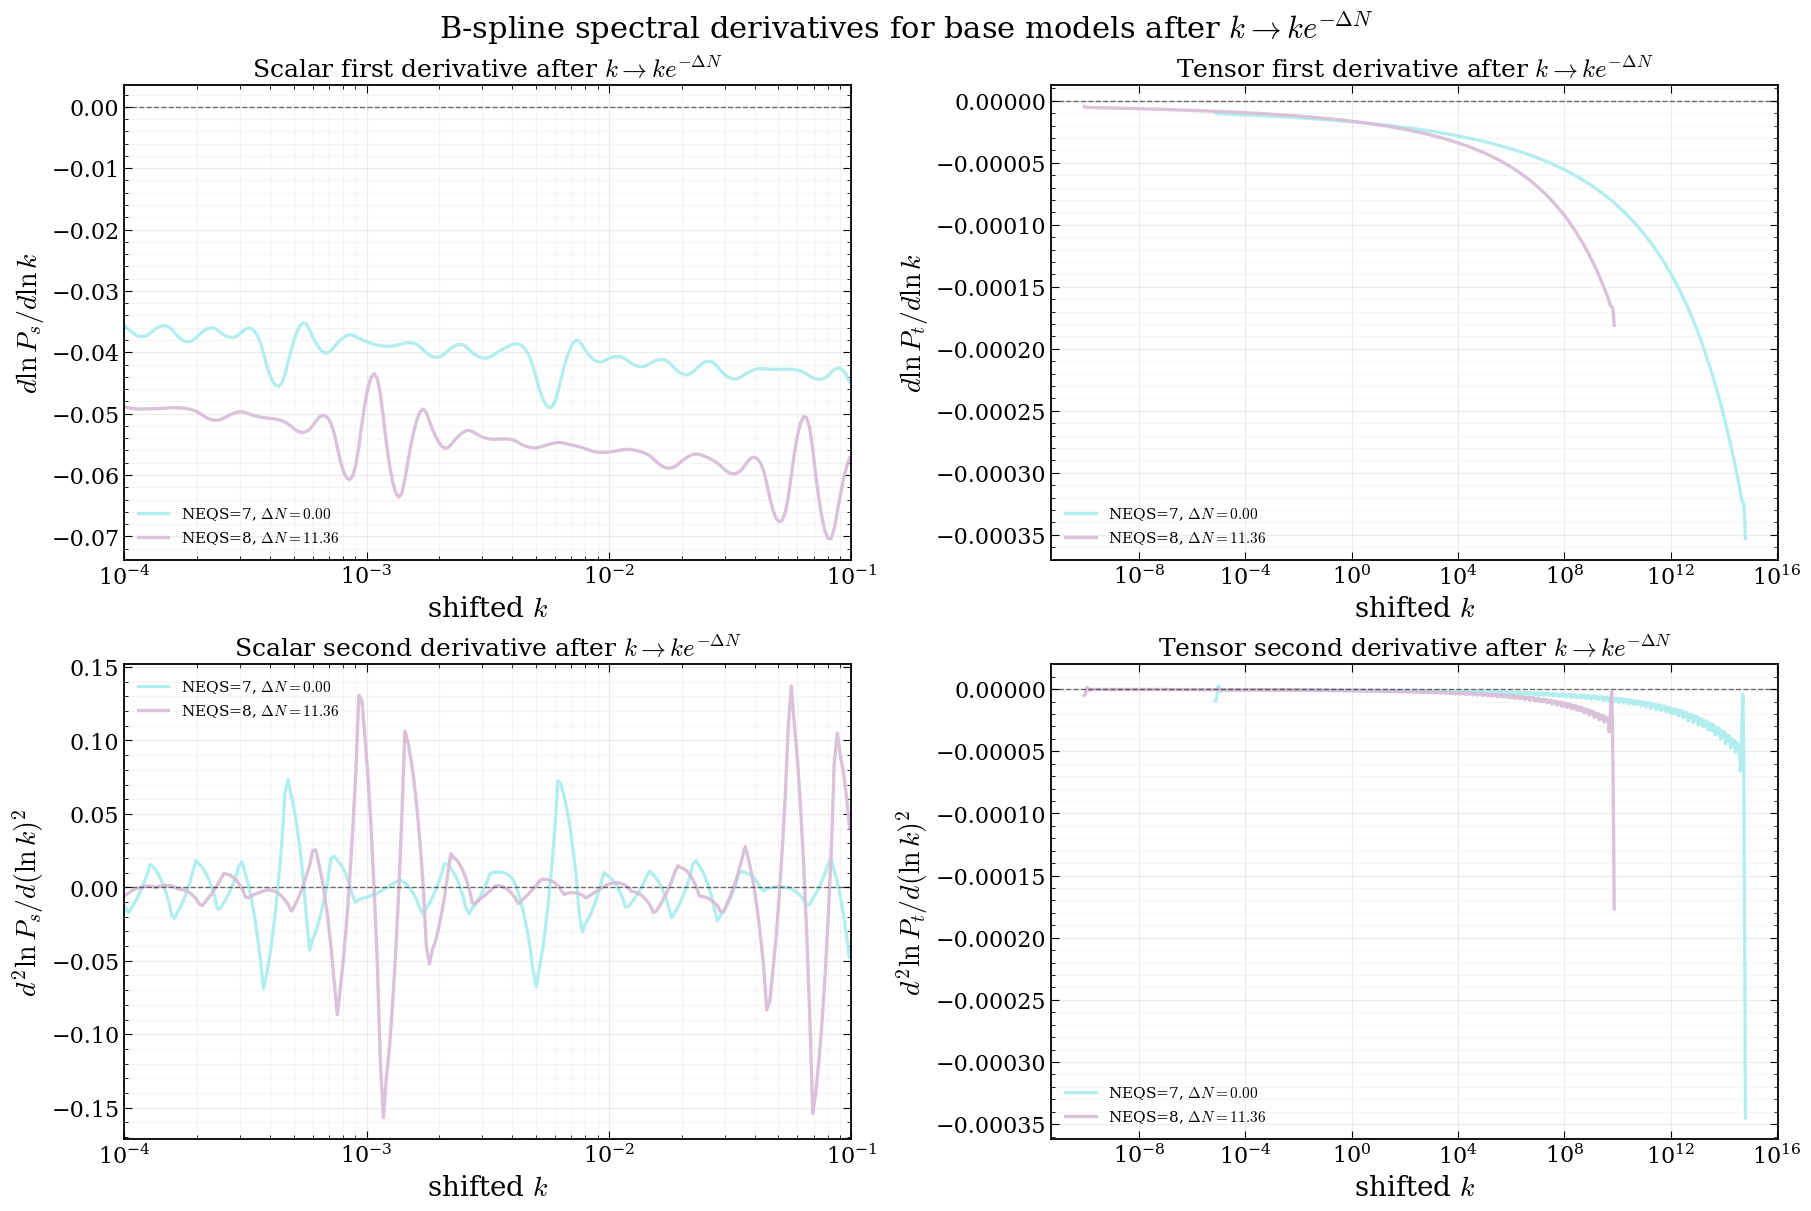


=== Shifted derivative summary ===
 NEQS param_name     value  original_N_end  deltaN_from_ref  exp_minus_deltaN  k_s_min_shifted  k_s_max_shifted  k_t_min_shifted  k_t_max_shifted
    7       lam4  0.000172      746.540732         0.000000          1.000000     7.791357e-06     6.470000e+14     7.791357e-06     6.470000e+14
    8       lam5 -0.000028      757.902354        11.361622          0.000012     9.064071e-11     7.526872e+09     9.064071e-11     7.526872e+09


In [88]:
deriv_shift_summary_df = plot_base_spectra_derivatives_bspline_2x2_kshifted(
    base_path_root=base_path_root,
    base_summary_df=base_summary_df,
    ref_NEQS=7,
    apply_k_shift=True,
    k_min_plot_s=1e-4,
    k_max_plot_s=1e-1,
    k_min_plot_t=None,
    k_max_plot_t=None,
    smoothing=0.0,
    save_name="base_spectra_derivatives_neqs7_8_kshifted.png",
    
)



# Truncation Tests

This next set needs to have been run while varying the last three slow roll parameters. That is what validates our truncation test.


## BEFORE N-SHIFTS

In [89]:
lam5_values = get_param_values_from_dirs(8, "lam5", base_path_root)
lam4_values = get_param_values_from_dirs(7, "lam4", base_path_root)



Summary for NEQS=8, parameter=lam5
Total models found: 30
Parameter range: -4.553e-05 to 4.537e-05


Summary for NEQS=7, parameter=lam4
Total models found: 30
Parameter range: -2.224e-04 to 4.727e-04



In [143]:
# ============================================================
# Print all discovered model values + observables + N_end
# ============================================================

def summarize_scan_values(
    NEQS,
    param_name,
    lam_values,
    base_path_root,
    sort_by="value",
):
    rows = []

    summary_file = os.path.join(
        base_path_root,
        f"neqs{NEQS}",
        f"neqs{NEQS}_summary.csv",
    )

    summary_df = pd.read_csv(summary_file)

    for item in lam_values:
        value = item[0] if isinstance(item, tuple) else item
        value = float(value)

        matches = summary_df.loc[
            np.isclose(summary_df[param_name], value)
        ]

        if len(matches) == 0:
            rows.append({
                "NEQS": NEQS,
                "param": param_name,
                "value": value,
                "found": False,
                "n_s": np.nan,
                "r": np.nan,
                "alpha_s": np.nan,
                "original_N_end": np.nan,
                "spectrum_N_start": np.nan,
                "path_N_end": np.nan,
            })
            continue

        row = matches.iloc[0]

        rows.append({
            "NEQS": NEQS,
            "param": param_name,
            "value": row[param_name],
            "found": True,
            "n_s": row.get("n_s", np.nan),
            "r": row.get("r", np.nan),
            "alpha_s": row.get("alpha_s", np.nan),
            "original_N_end": row.get("original_N_end", np.nan),
            "spectrum_N_start": row.get("spectrum_N_start", np.nan),
            "path_N_end": row.get("path_N_end", np.nan),
        })

    out = pd.DataFrame(rows)

    if sort_by in out.columns:
        out = out.sort_values(sort_by)

    return out


scan7_df = summarize_scan_values(
    NEQS=7,
    param_name="lam4",
    lam_values=lam4_values,
    base_path_root=base_path_root,
)

scan8_df = summarize_scan_values(
    NEQS=8,
    param_name="lam5",
    lam_values=lam5_values,
    base_path_root=base_path_root,
)

all_scan_df = pd.concat(
    [scan7_df, scan8_df],
    ignore_index=True,
)

print("\n" + "=" * 80)
print("ALL DISCOVERED SCAN VALUES")
print("=" * 80)
print(all_scan_df.to_string(index=False))


# ============================================================
# Optional: compare all models to your chosen NEQS=7 reference
# ============================================================

REF_NEQS = 7
REF_PARAM = "lam4"
REF_VALUE = 3.3375788071e-04# 1.7964939234e-04

ref_row = all_scan_df[
    (all_scan_df["NEQS"] == REF_NEQS)
    & np.isclose(all_scan_df["value"], REF_VALUE)
]

if len(ref_row) == 0:
    print(
        f"\nWARNING: Could not find reference model "
        f"NEQS={REF_NEQS}, {REF_PARAM}={REF_VALUE:.10e}"
    )
else:
    ref_N_end = ref_row["original_N_end"].iloc[0]

    all_scan_df["deltaN_from_ref"] = (
        all_scan_df["original_N_end"] - ref_N_end
    )

    all_scan_df["abs_deltaN_from_ref"] = np.abs(
        all_scan_df["deltaN_from_ref"]
    )

    print("\n" + "=" * 80)
    print(
        f"ALL SCAN VALUES RELATIVE TO "
        f"NEQS={REF_NEQS}, {REF_PARAM}={REF_VALUE:.10e}"
    )
    print("=" * 80)

    cols = [
        "NEQS",
        "param",
        "value",
        "n_s",
        "r",
        "alpha_s",
        "original_N_end",
        "deltaN_from_ref",
        "abs_deltaN_from_ref",
        "found",
    ]

    print(
        all_scan_df[cols]
        .sort_values(["NEQS", "abs_deltaN_from_ref"])
        .to_string(index=False)
    )


# ============================================================
# Optional: print models passing your current cuts
# ============================================================

ns_min = 0.96
ns_max = 0.970
r_min = 1e-8
r_max = 0.5
max_abs_deltaN = 15.0

if "abs_deltaN_from_ref" in all_scan_df.columns:
    cut_df = all_scan_df[
        (all_scan_df["found"])
        & (all_scan_df["n_s"] >= ns_min)
        & (all_scan_df["n_s"] <= ns_max)
        & (all_scan_df["r"] >= r_min)
        & (all_scan_df["r"] <= r_max)
        & (all_scan_df["abs_deltaN_from_ref"] <= max_abs_deltaN)
    ].copy()

    print("\n" + "=" * 80)
    print("MODELS PASSING CURRENT CUTS")
    print("=" * 80)
    print(
        f"cuts: {ns_min} <= n_s <= {ns_max}, "
        f"{r_min} <= r <= {r_max}, "
        f"|deltaN| <= {max_abs_deltaN}"
    )

    if len(cut_df) == 0:
        print("No models pass these cuts.")
    else:
        print(
            cut_df[[
                "NEQS",
                "param",
                "value",
                "n_s",
                "r",
                "alpha_s",
                "original_N_end",
                "deltaN_from_ref",
                "abs_deltaN_from_ref",
            ]]
            .sort_values(["NEQS", "abs_deltaN_from_ref"])
            .to_string(index=False)
        )


ALL DISCOVERED SCAN VALUES
 NEQS param     value  found      n_s        r   alpha_s  original_N_end  spectrum_N_start  path_N_end
    7  lam4 -0.000222   True 0.963157 0.000094 -0.001312      800.090372          0.000157        60.0
    7  lam4 -0.000186   True 0.968259 0.000095 -0.001384      815.677554          0.000156        60.0
    7  lam4 -0.000077   True 0.969593 0.134139  0.039551      942.490400          0.000156        60.0
    7  lam4 -0.000062   True 0.966195 0.000080 -0.001295      802.244858          0.000157        60.0
    7  lam4 -0.000041   True 0.961736 0.000116 -0.001182      778.214255          0.000156        60.0
    7  lam4 -0.000011   True 0.966631 0.000044 -0.001325      804.756733          0.000156        60.0
    7  lam4  0.000007   True 0.967927 0.000131 -0.001263      801.879429          0.000156        60.0
    7  lam4  0.000025   True 0.968976 0.000115 -0.001285      805.506611          0.000156        60.0
    7  lam4  0.000030   True 0.961268 0.13217

In [144]:
def plot_filtered_spectra_by_ns(
    NEQS,
    lamX_values,
    baseX,
    base_path_root,
    ns_min=0.955,
    ns_max=0.971,
    ns_target=0.967,
    k_ref=0.05,
    k_min_scalar=None,
    k_max_scalar=10.0,
    cmap_name="plasma",
    save_name=None,
    show=True,
):
    
    
    plt.rcParams.update({
    "text.usetex": False,
    "mathtext.fontset": "cm",
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "DejaVu Serif"],

    "axes.labelsize": 22,
    "axes.titlesize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 15,
    "figure.titlesize": 24,

    "axes.linewidth": 1.3,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    })

        
        
    scan_name, scan_symbol = SCAN_INFO[NEQS]

    def sanitize_lam_values(vals):
        return np.array(
            [x[0] if isinstance(x, tuple) else x for x in vals],
            dtype=float,
        )

    def folder_for(value):
        val_str = f"{value:.10e}"
        return os.path.join(
            base_path_root,
            f"neqs{NEQS}",
            f"{scan_name}_{val_str}",
        )

    def load_observables(value):
        arr = np.loadtxt(
            os.path.join(folder_for(value), f"test_nr_neqs{NEQS}.dat")
        )
        arr = np.atleast_1d(arr)
        return arr[0], arr[1], arr[2]

    def load_specs(value):
        folder = folder_for(value)

        s = np.loadtxt(os.path.join(folder, f"spec_s_neqs{NEQS}.dat"))
        t = np.loadtxt(os.path.join(folder, f"spec_t_neqs{NEQS}.dat"))

        k_s = s[:, 0]
        Ps = np.abs(s[:, 1])

        k_t = t[:, 0]
        Pt = np.abs(t[:, 1])

        return k_s, Ps, k_t, Pt

    def prepare_increasing(x, y):
        x = np.asarray(x)
        y = np.asarray(y)

        dx = np.diff(x)

        if np.all(dx >= 0):
            return x, y
        elif np.all(dx <= 0):
            return x[::-1], y[::-1]
        else:
            order = np.argsort(x)
            return x[order], y[order]

    def normalize_at_ref(x, y, x_ref):
        x, y = prepare_increasing(x, y)

        if not (np.min(x) <= x_ref <= np.max(x)):
            raise ValueError(
                f"k_ref={x_ref} outside range [{np.min(x):.4e}, {np.max(x):.4e}]"
            )

        y_ref = np.interp(x_ref, x, y)

        if np.abs(y_ref) < 1e-30:
            raise ValueError(f"Reference value too small at k_ref={x_ref}")

        return x, y / y_ref

    def scalar_k_mask(k):
        mask = np.ones_like(k, dtype=bool)

        if k_min_scalar is not None:
            mask &= k >= k_min_scalar

        if k_max_scalar is not None:
            mask &= k <= k_max_scalar

        return mask

    def frac_on_base_grid(
        x_base,
        y_base,
        x_cmp,
        y_cmp,
        xmin=None,
        xmax=None,
    ):
        x_base, y_base = prepare_increasing(x_base, y_base)
        x_cmp, y_cmp = prepare_increasing(x_cmp, y_cmp)

        xlo = max(np.min(x_base), np.min(x_cmp))
        xhi = min(np.max(x_base), np.max(x_cmp))

        if xmin is not None:
            xlo = max(xlo, xmin)

        if xmax is not None:
            xhi = min(xhi, xmax)

        mask = (x_base >= xlo) & (x_base <= xhi)

        x_use = x_base[mask]
        y_base_use = y_base[mask]

        if len(x_use) == 0:
            raise ValueError(
                f"No overlapping k-values in requested range [{xlo:.4e}, {xhi:.4e}]"
            )

        y_cmp_interp = np.interp(x_use, x_cmp, y_cmp)

        frac = (y_cmp_interp - y_base_use) / y_base_use

        return x_use, frac

    lam_vals = sanitize_lam_values(lamX_values)

    r_base, ns_base, alpha_base = load_observables(baseX)

    k_s_base_raw, Ps_base_raw, k_t_base_raw, Pt_base_raw = load_specs(baseX)

    k_s_base, Ps_base_norm = normalize_at_ref(k_s_base_raw, Ps_base_raw, k_ref)
    k_t_base, Pt_base_norm = normalize_at_ref(k_t_base_raw, Pt_base_raw, k_ref)

    rows = []
    kept_models = []

    for lamX in lam_vals:
        try:
            r, ns, alpha_s = load_observables(lamX)

            k_s_raw, Ps_raw, k_t_raw, Pt_raw = load_specs(lamX)

            k_s, Ps_norm = normalize_at_ref(k_s_raw, Ps_raw, k_ref)
            k_t, Pt_norm = normalize_at_ref(k_t_raw, Pt_raw, k_ref)

            k_ps_err, frac_ps = frac_on_base_grid(
                k_s_base,
                Ps_base_norm,
                k_s,
                Ps_norm,
                xmin=k_min_scalar,
                xmax=k_max_scalar,
            )

            k_pt_err, frac_pt = frac_on_base_grid(
                k_t_base,
                Pt_base_norm,
                k_t,
                Pt_norm,
                xmin=None,
                xmax=None,
            )

            mean_dPs_pct = 100.0 * np.nanmean(frac_ps)
            max_dPs_pct = 100.0 * np.nanmax(np.abs(frac_ps))
            mean_dPt_pct = 100.0 * np.nanmean(frac_pt)
            max_dPt_pct = 100.0 * np.nanmax(np.abs(frac_pt))

            keep = ns_min <= ns <= ns_max

            row = {
                "lamX": lamX,
                "r": r,
                "ns": ns,
                "alpha_s": alpha_s,
                "delta_ns_from_base": ns - ns_base,
                "delta_ns_from_target": ns - ns_target,
                "mean_dPs_pct": mean_dPs_pct,
                "max_dPs_pct": max_dPs_pct,
                "mean_dPt_pct": mean_dPt_pct,
                "max_dPt_pct": max_dPt_pct,
                "kept_by_ns_cut": keep,
            }

            rows.append(row)

            if keep:
                kept_models.append({
                    **row,
                    "k_s": k_s,
                    "Ps_norm": Ps_norm,
                    "k_t": k_t,
                    "Pt_norm": Pt_norm,
                    "k_ps_err": k_ps_err,
                    "frac_ps": frac_ps,
                    "k_pt_err": k_pt_err,
                    "frac_pt": frac_pt,
                })

        except FileNotFoundError:
            print(f"Missing files for {scan_name}={lamX:.5e}")
        except ValueError as e:
            print(f"Skipping {scan_name}={lamX:.5e}: {e}")

    stats_df = pd.DataFrame(rows).sort_values("ns")
    kept_df = stats_df[stats_df["kept_by_ns_cut"]].copy()

    print("\n=== All models summary ===")
    print(f"Total loaded: {len(stats_df)}")
    print(f"Base ns: {ns_base:.6f}")
    print(f"Models in ns window [{ns_min}, {ns_max}]: {len(kept_df)}")

    if not kept_df.empty:
        print("\n=== Filtered models by ns cut ===")
        print(
            kept_df[[
                "lamX",
                "ns",
                "delta_ns_from_base",
                "mean_dPs_pct",
                "max_dPs_pct",
                "mean_dPt_pct",
                "max_dPt_pct",
            ]].to_string(index=False)
        )

        print("\n=== Error shrink check in percentages ===")
        print("All models:")
        print(
            stats_df[[
                "mean_dPs_pct",
                "max_dPs_pct",
                "mean_dPt_pct",
                "max_dPt_pct",
            ]]
            .agg(["mean", "max"])
            .to_string()
        )

        print("\nFiltered models:")
        print(
            kept_df[[
                "mean_dPs_pct",
                "max_dPs_pct",
                "mean_dPt_pct",
                "max_dPt_pct",
            ]]
            .agg(["mean", "max"])
            .to_string()
        )

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(18, 12),
        constrained_layout=True,
    )

    ax_ps, ax_pt = axes[0]
    ax_ps_err, ax_pt_err = axes[1]

    if len(kept_models) > 0:
        lam_kept = np.array([m["lamX"] for m in kept_models])
        cmap = plt.get_cmap(cmap_name)
        norm = mcolors.Normalize(vmin=np.min(lam_kept), vmax=np.max(lam_kept))

        for m in kept_models:
            color = cmap(norm(m["lamX"]))

            mask_ps_plot = scalar_k_mask(m["k_s"])

            ax_ps.loglog(
                m["k_s"][mask_ps_plot],
                m["Ps_norm"][mask_ps_plot],
                color=color,
                lw=1.8,
                alpha=0.85,
            )

            ax_pt.loglog(
                m["k_t"],
                m["Pt_norm"],
                color=color,
                lw=1.8,
                alpha=0.85,
            )

            ax_ps_err.semilogx(
                m["k_ps_err"],
                100.0 * m["frac_ps"],
                color=color,
                lw=1.5,
                alpha=0.85,
            )

            ax_pt_err.semilogx(
                m["k_pt_err"],
                100.0 * m["frac_pt"],
                color=color,
                lw=1.5,
                alpha=0.85,
            )

        sm = cm.ScalarMappable(cmap=cmap, norm=norm)
        fig.colorbar(sm, ax=axes, label=rf"${scan_symbol}$")

    mask_base_s = scalar_k_mask(k_s_base)

    ax_ps.loglog(
        k_s_base[mask_base_s],
        Ps_base_norm[mask_base_s],
        color="black",
        lw=3,
        ls="--",
        label=rf"base $n_s={ns_base:.4f}$",
    )

    ax_pt.loglog(
        k_t_base,
        Pt_base_norm,
        color="black",
        lw=3,
        ls="--",
        label=rf"base $n_s={ns_base:.4f}$",
    )

    for ax in [ax_ps_err, ax_pt_err]:
        ax.axhline(
            0.0,
            color="black",
            ls="--",
            lw=0.8,
            alpha=0.6,
        )

    ax_ps.axvline(k_ref, color="black", ls=":", alpha=0.7)
    ax_pt.axvline(k_ref, color="black", ls=":", alpha=0.7)

    ax_ps.set_title(
        rf"Filtered normalized scalar spectra: $P_s/P_s({k_ref})$"
    )
    ax_pt.set_title(
        rf"Filtered normalized tensor spectra: $P_t/P_t({k_ref})$"
    )
    ax_ps_err.set_title(r"Filtered scalar fractional error")
    ax_pt_err.set_title(r"Filtered tensor fractional error")

    ax_ps.set_xlabel(r"$k$")
    ax_pt.set_xlabel(r"$k$")
    ax_ps_err.set_xlabel(r"$k$")
    ax_pt_err.set_xlabel(r"$k$")

    ax_ps.set_ylabel(r"$P_s/P_s(k_{\rm ref})$")
    ax_pt.set_ylabel(r"$P_t/P_t(k_{\rm ref})$")
    ax_ps_err.set_ylabel(r"$100\times\Delta P_s/P_{s,\rm base}$")
    ax_pt_err.set_ylabel(r"$100\times\Delta P_t/P_{t,\rm base}$")

    xmin_scalar = (
        k_min_scalar
        if k_min_scalar is not None
        else np.min(k_s_base[mask_base_s])
    )

    xmax_scalar = (
        k_max_scalar
        if k_max_scalar is not None
        else np.max(k_s_base[mask_base_s])
    )

    ax_ps.set_xlim(xmin_scalar, xmax_scalar)
    ax_ps_err.set_xlim(xmin_scalar, xmax_scalar)

    for ax in axes.ravel():
        ax.grid(True, alpha=0.25)
        handles, labels = ax.get_legend_handles_labels()
        if len(handles) > 0:
            ax.legend(fontsize=15)

    fig.suptitle(
        rf"Models with ${ns_min} \leq n_s \leq {ns_max}$ "
        rf"(target $n_s={ns_target}$)",
        fontsize=24,
    )

    if save_name is None:
        save_name = (
            f"neqs{NEQS}_{scan_name}_filtered_ns_"
            f"{ns_min}_{ns_max}_kmin{k_min_scalar}_kmax{k_max_scalar}.png"
        )

    plt.savefig(save_name, dpi=300, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return stats_df, kept_df


=== All models summary ===
Total loaded: 30
Base ns: 0.966325
Models in ns window [0.96, 0.971]: 30

=== Filtered models by ns cut ===
     lamX       ns  delta_ns_from_base  mean_dPs_pct  max_dPs_pct  mean_dPt_pct  max_dPt_pct
 0.000271 0.961065           -0.005261      5.787642     9.768882     -6.368433    25.844555
 0.000030 0.961268           -0.005057    -23.524659    36.105800     -3.208405    13.626310
 0.000273 0.961685           -0.004640      0.988952     2.937550     -9.615956    17.394666
-0.000041 0.961736           -0.004589      1.233721     2.863563     -0.051454     0.261431
-0.000222 0.963157           -0.003168      0.914277     2.067320     -0.038767     0.207822
 0.000416 0.963215           -0.003111      4.026622     6.739252     -3.140890    18.631199
 0.000037 0.963539           -0.002786      0.737296     1.729283     -0.038061     0.188541
 0.000147 0.964029           -0.002297      4.295505     6.957002     -9.885406    53.946063
 0.000415 0.964352         

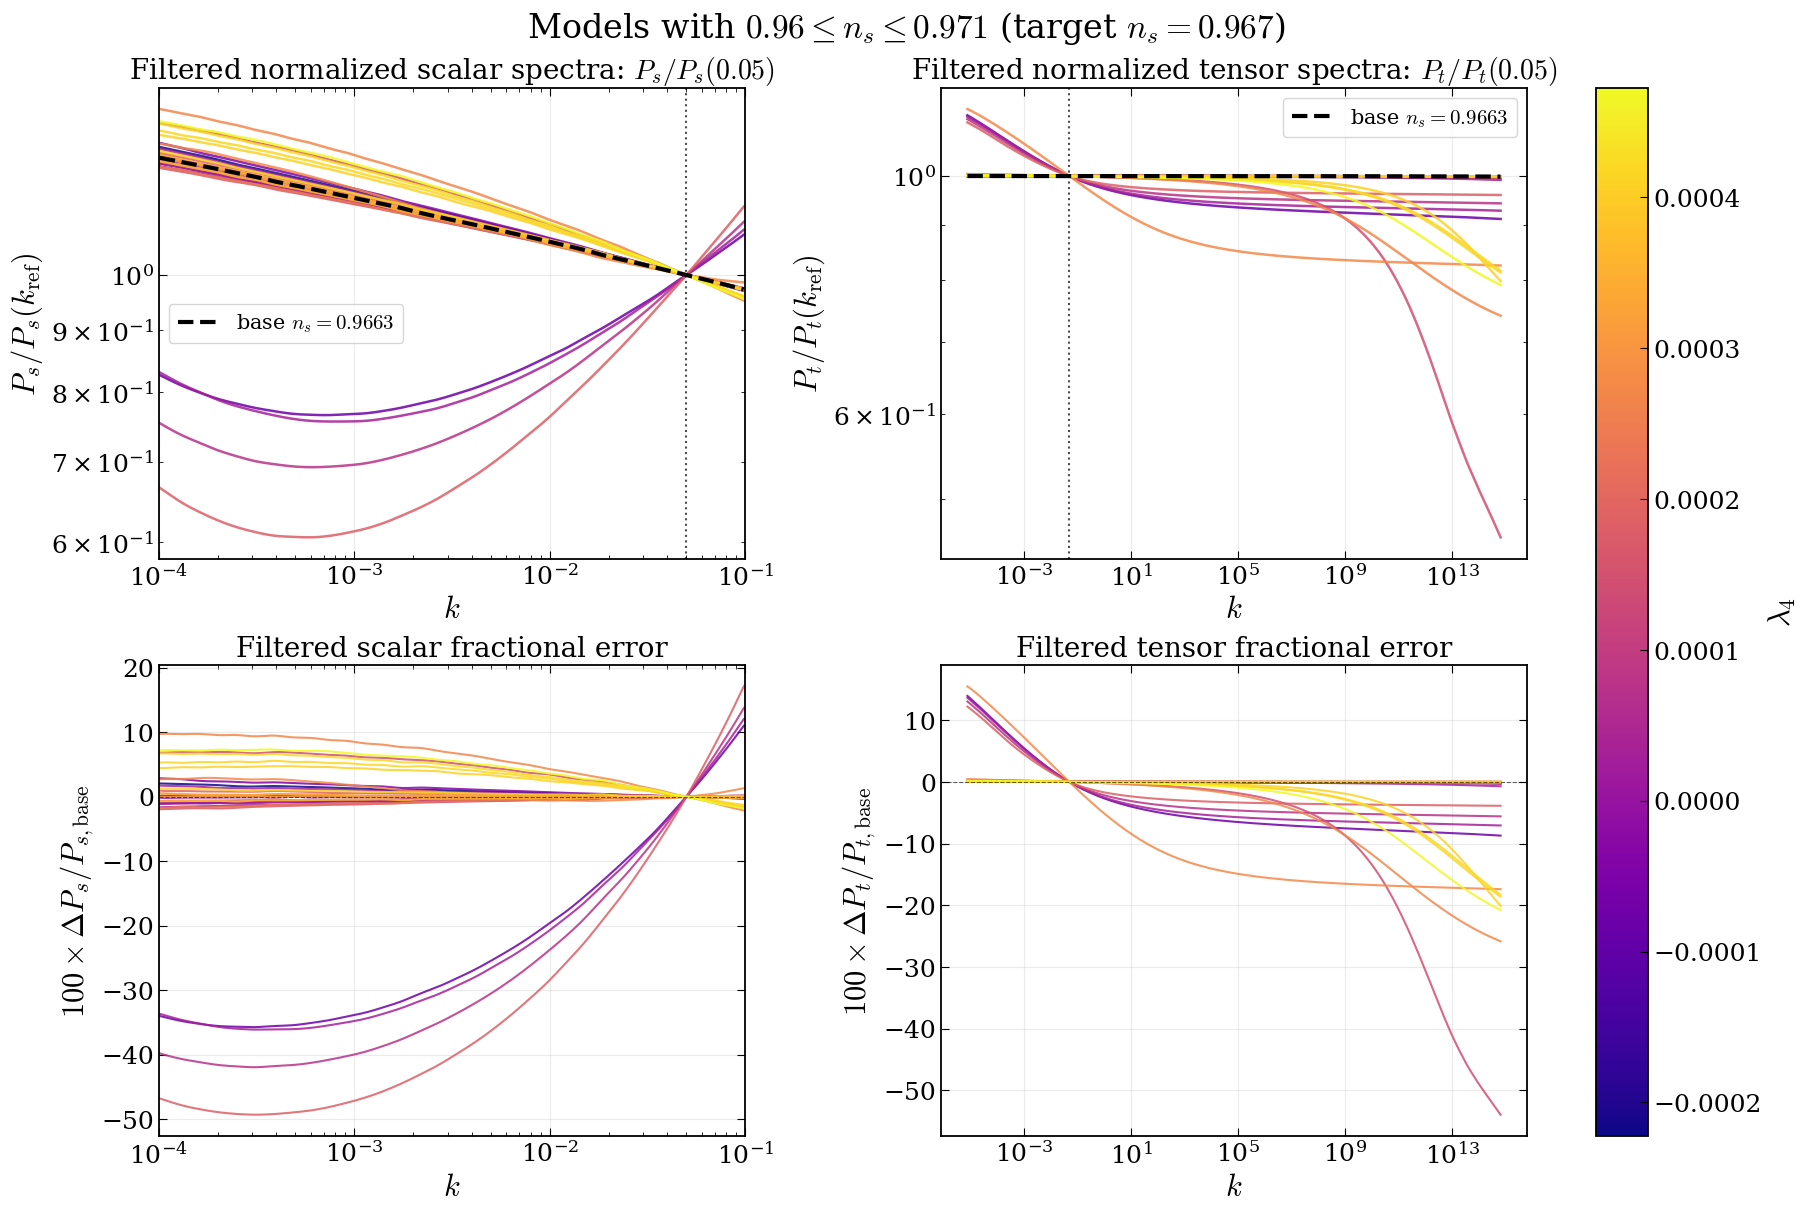


=== All models summary ===
Total loaded: 30
Base ns: 0.964340
Models in ns window [0.96, 0.971]: 30

=== Filtered models by ns cut ===
     lamX       ns  delta_ns_from_base  mean_dPs_pct  max_dPs_pct  mean_dPt_pct  max_dPt_pct
-0.000004 0.960040           -0.004300      9.189861    15.155339      3.419586     6.600653
-0.000011 0.960043           -0.004297    -17.790207    28.571112     -7.443540    68.521029
-0.000010 0.960549           -0.003791      5.502988     9.304050     10.334697    44.031302
-0.000044 0.960608           -0.003731      5.610809     9.388441     10.355094    44.146142
 0.000017 0.960961           -0.003379      5.526185     9.266756     10.323209    43.962174
-0.000009 0.961475           -0.002865      5.316667     8.771899     10.328811    44.000150
-0.000044 0.961649           -0.002691      5.265942     8.816013     10.358982    44.168155
-0.000012 0.962709           -0.001631      7.901864    12.902664      5.612907    14.160259
 0.000045 0.963405         

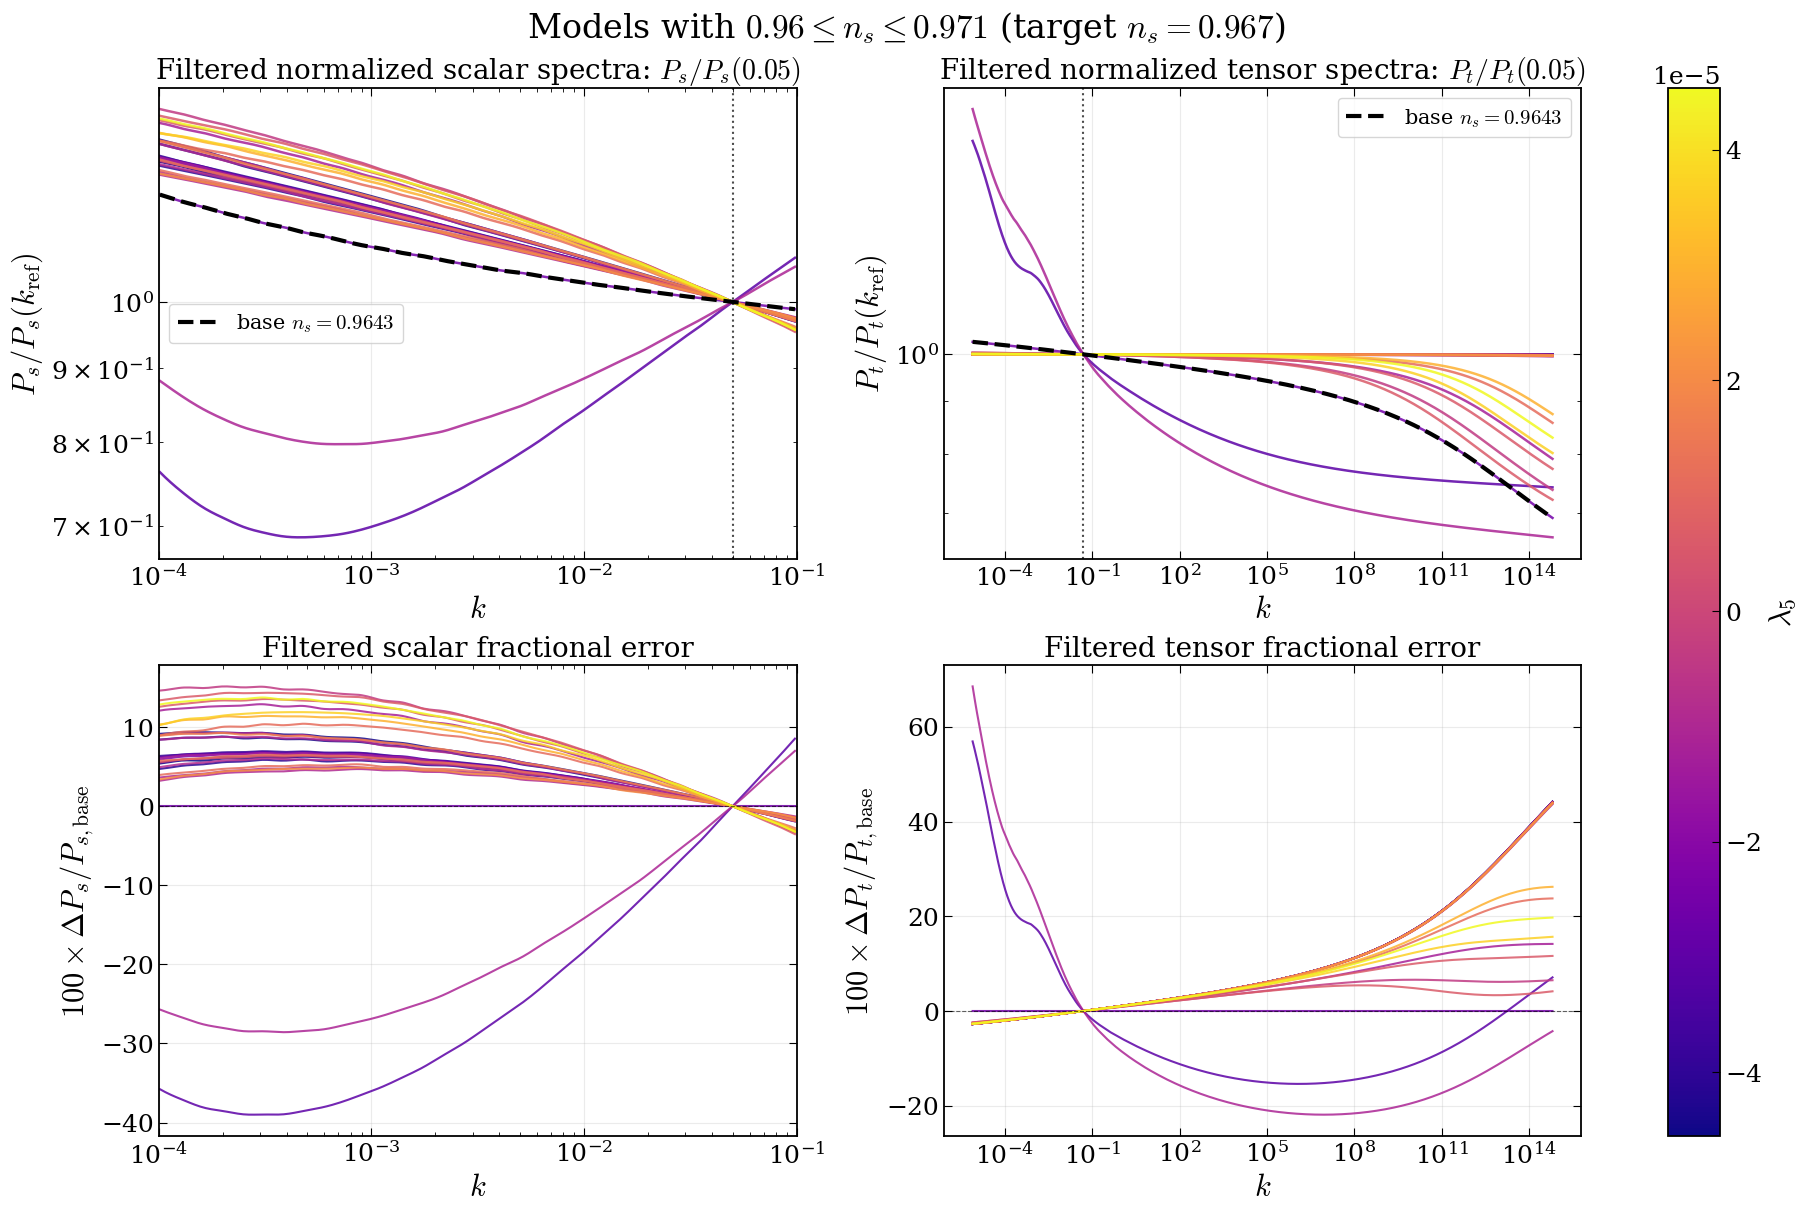

In [145]:
stats_df, kept_df = plot_filtered_spectra_by_ns(
    NEQS=7,
    lamX_values=lam4_values,
    baseX= 3.3375788071e-04,#1.7964939234e-04,
    base_path_root="/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests",
    ns_min=0.96,
    ns_max=0.971,
    ns_target=0.967,
    k_ref=0.05,
    k_min_scalar=1e-4,
    k_max_scalar=1e-1,
    save_name="neqs7_lam4_filtered_ns_spectra.png"
)


stats_df, kept_df = plot_filtered_spectra_by_ns(
    NEQS=8,
    lamX_values=lam5_values,
    baseX= -2.5481607795e-05,
    base_path_root="/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests",
    ns_min=0.96,
    ns_max=0.971,
    ns_target=0.967,
    k_ref=0.05,
    k_min_scalar=1e-4,
    k_max_scalar=1e-1,
    save_name="neqs8_lam5_filtered_ns_spectra.png"
)



In [99]:
def plot_filtered_background_by_ns(
    NEQS,
    lamX_values,
    baseX,
    base_path_root,
    ns_min=0.96,
    ns_max=0.971,
    ns_target=0.967,
    N_ref=60.0,
    N_window=None,
    cmap_name="plasma",
    frac_ylim=None,
    eps_frac_ylim=None,
    save_name=None,
    show=True,
):
    scan_name, scan_symbol = SCAN_INFO[NEQS]

    def sanitize_lam_values(vals):
        return np.array([x[0] if isinstance(x, tuple) else x for x in vals], dtype=float)

    def folder_for(value):
        val_str = f"{value:.10e}"
        return os.path.join(base_path_root, f"neqs{NEQS}", f"{scan_name}_{val_str}")

    def load_observables(value):
        arr = np.loadtxt(os.path.join(folder_for(value), f"test_nr_neqs{NEQS}.dat"))
        arr = np.atleast_1d(arr)
        return arr[0], arr[1], arr[2]

    def load_path(value):
        val_str = f"{value:.10e}"
        f = os.path.join(folder_for(value), f"path_neqs{NEQS}_{scan_name}_{val_str}.dat")
        return pd.read_csv(f, sep=r"\s+", header=None).values

    def prepare_increasing(x, y):
        x = np.asarray(x)
        y = np.asarray(y)
        order = np.argsort(x)
        return x[order], y[order]

    def normalize_at_ref(N, Y, N_ref):
        N_use, Y_use = prepare_increasing(N, Y)

        if not (np.min(N_use) <= N_ref <= np.max(N_use)):
            raise ValueError(
                f"N_ref={N_ref} outside range [{np.min(N_use)}, {np.max(N_use)}]"
            )

        Y_ref = np.interp(N_ref, N_use, Y_use)

        if np.abs(Y_ref) < 1e-30:
            raise ValueError(f"Reference value too small at N_ref={N_ref}")

        return N_use, Y_use / Y_ref, Y_ref

    def apply_N_window(N, Y):
        if N_window is None:
            return N, Y

        Nmin, Nmax = N_window
        mask = (N >= Nmin) & (N <= Nmax)
        return N[mask], Y[mask]

    def fractional_error_on_base_grid(N_base, Y_base, N_model, Y_model):
        N_base, Y_base = prepare_increasing(N_base, Y_base)
        N_model, Y_model = prepare_increasing(N_model, Y_model)

        Nmin = max(np.min(N_base), np.min(N_model))
        Nmax = min(np.max(N_base), np.max(N_model))

        if N_window is not None:
            Nmin = max(Nmin, N_window[0])
            Nmax = min(Nmax, N_window[1])

        mask = (N_base >= Nmin) & (N_base <= Nmax)

        N_use = N_base[mask]
        Y_base_use = Y_base[mask]

        if len(N_use) == 0:
            raise ValueError("No overlapping N range between model and base.")

        Y_model_interp = np.interp(N_use, N_model, Y_model)
        frac = (Y_model_interp - Y_base_use) / Y_base_use

        return N_use, frac

    plt.rcParams.update({
        "text.usetex": False,
        "mathtext.fontset": "cm",
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman", "DejaVu Serif"],

        "axes.labelsize": 20,
        "axes.titlesize": 18,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 14,
        "figure.titlesize": 22,

        "axes.linewidth": 1.3,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
    })

    lam_vals = sanitize_lam_values(lamX_values)

    r_base, ns_base, alpha_base = load_observables(baseX)
    base_data = load_path(baseX)

    H_base = base_data[:, 1]
    eps_base = base_data[:, 2]
    N_base = base_data[:, NEQS]
    V_base = base_data[:, NEQS + 1]

    N_base_H, H_base_norm, H_ref = normalize_at_ref(N_base, H_base, N_ref)
    N_base_eps, eps_base_norm, eps_ref = normalize_at_ref(N_base, eps_base, N_ref)
    N_base_V, V_base_norm, V_ref = normalize_at_ref(N_base, V_base, N_ref)

    N_base_H_plot, H_base_plot = apply_N_window(N_base_H, H_base_norm)
    N_base_eps_plot, eps_base_plot = apply_N_window(N_base_eps, eps_base_norm)
    N_base_V_plot, V_base_plot = apply_N_window(N_base_V, V_base_norm)

    rows = []
    kept_models = []

    for lamX in lam_vals:
        try:
            r, ns, alpha_s = load_observables(lamX)
            keep = ns_min <= ns <= ns_max

            row = {
                "lamX": lamX,
                "r": r,
                "ns": ns,
                "alpha_s": alpha_s,
                "delta_ns_from_base": ns - ns_base,
                "delta_ns_from_target": ns - ns_target,
                "kept_by_ns_cut": keep,
            }
            rows.append(row)

            if not keep:
                continue

            data = load_path(lamX)

            H = data[:, 1]
            eps = data[:, 2]
            N = data[:, NEQS]
            V = data[:, NEQS + 1]

            N_H, H_norm, _ = normalize_at_ref(N, H, N_ref)
            N_eps, eps_norm, _ = normalize_at_ref(N, eps, N_ref)
            N_V, V_norm, _ = normalize_at_ref(N, V, N_ref)

            N_H_plot, H_plot = apply_N_window(N_H, H_norm)
            N_eps_plot, eps_plot = apply_N_window(N_eps, eps_norm)
            N_V_plot, V_plot = apply_N_window(N_V, V_norm)

            N_frac_H, frac_H = fractional_error_on_base_grid(
                N_base_H, H_base_norm, N_H, H_norm
            )

            N_frac_eps, frac_eps = fractional_error_on_base_grid(
                N_base_eps, eps_base_norm, N_eps, eps_norm
            )

            N_frac_V, frac_V = fractional_error_on_base_grid(
                N_base_V, V_base_norm, N_V, V_norm
            )

            kept_models.append({
                **row,

                "N_H": N_H_plot,
                "H_N": H_plot,
                "N_eps": N_eps_plot,
                "eps_N": eps_plot,
                "N_V": N_V_plot,
                "V_N": V_plot,

                "N_frac_H": N_frac_H,
                "frac_H": frac_H,
                "N_frac_eps": N_frac_eps,
                "frac_eps": frac_eps,
                "N_frac_V": N_frac_V,
                "frac_V": frac_V,

                "mean_dH_pct": 100.0 * np.nanmean(frac_H),
                "max_dH_pct": 100.0 * np.nanmax(np.abs(frac_H)),
                "mean_deps_pct": 100.0 * np.nanmean(frac_eps),
                "max_deps_pct": 100.0 * np.nanmax(np.abs(frac_eps)),
                "mean_dV_pct": 100.0 * np.nanmean(frac_V),
                "max_dV_pct": 100.0 * np.nanmax(np.abs(frac_V)),
            })

        except FileNotFoundError:
            print(f"Missing files for {scan_name}={lamX:.5e}")
        except ValueError as e:
            print(f"Skipping {scan_name}={lamX:.5e}: {e}")

    stats_df = pd.DataFrame(rows).sort_values("ns")

    if len(kept_models) > 0:
        kept_df = pd.DataFrame(kept_models).drop(
            columns=[
                "N_H", "H_N",
                "N_eps", "eps_N",
                "N_V", "V_N",
                "N_frac_H", "frac_H",
                "N_frac_eps", "frac_eps",
                "N_frac_V", "frac_V",
            ]
        )
    else:
        kept_df = stats_df[stats_df["kept_by_ns_cut"]].copy()

    print("\n=== Background models summary ===")
    print(f"Total loaded: {len(stats_df)}")
    print(f"Base ns: {ns_base:.6f}")
    print(f"Models in ns window [{ns_min}, {ns_max}]: {len(kept_models)}")

    if len(kept_models) > 0:
        print("\n=== Background fractional errors in percent ===")
        print(
            kept_df[[
                "lamX",
                "ns",
                "mean_dH_pct",
                "max_dH_pct",
                "mean_deps_pct",
                "max_deps_pct",
                "mean_dV_pct",
                "max_dV_pct",
            ]].to_string(index=False)
        )

    fig, axes = plt.subplots(
        3,
        2,
        figsize=(18, 16),
        constrained_layout=True,
    )

    ax_HN, ax_VN = axes[0]
    ax_Herr, ax_Verr = axes[1]
    ax_epsN, ax_epserr = axes[2]

    if len(kept_models) > 0:
        lam_kept = np.array([m["lamX"] for m in kept_models])
        cmap = plt.get_cmap(cmap_name)
        norm = mcolors.Normalize(vmin=np.min(lam_kept), vmax=np.max(lam_kept))

        for m in kept_models:
            color = cmap(norm(m["lamX"]))

            ax_HN.plot(m["N_H"], m["H_N"], color=color, lw=1.8, alpha=0.85)
            ax_VN.plot(m["N_V"], m["V_N"], color=color, lw=1.8, alpha=0.85)
            ax_epsN.plot(m["N_eps"], m["eps_N"], color=color, lw=1.8, alpha=0.85)

            ax_Herr.plot(
                m["N_frac_H"],
                100.0 * m["frac_H"],
                color=color,
                lw=1.6,
                alpha=0.85,
            )

            ax_Verr.plot(
                m["N_frac_V"],
                100.0 * m["frac_V"],
                color=color,
                lw=1.6,
                alpha=0.85,
            )

            ax_epserr.plot(
                m["N_frac_eps"],
                100.0 * m["frac_eps"],
                color=color,
                lw=1.6,
                alpha=0.85,
            )

        sm = cm.ScalarMappable(cmap=cmap, norm=norm)
        fig.colorbar(sm, ax=axes, label=rf"${scan_symbol}$")

    ax_HN.plot(
        N_base_H_plot,
        H_base_plot,
        color="black",
        lw=3,
        ls="--",
        label=rf"base $n_s={ns_base:.4f}$",
    )

    ax_VN.plot(
        N_base_V_plot,
        V_base_plot,
        color="black",
        lw=3,
        ls="--",
        label=rf"base $n_s={ns_base:.4f}$",
    )

    ax_epsN.plot(
        N_base_eps_plot,
        eps_base_plot,
        color="black",
        lw=3,
        ls="--",
        label=rf"base $n_s={ns_base:.4f}$",
    )

    for ax in [ax_Herr, ax_Verr, ax_epserr]:
        ax.axhline(0.0, color="black", ls="--", lw=1.0, alpha=0.7)

    ax_HN.set_title(rf"Filtered normalized Hubble evolution: $H/H(N={N_ref})$")
    ax_VN.set_title(rf"Filtered normalized potential evolution: $V/V(N={N_ref})$")
    ax_epsN.set_title(rf"Filtered normalized slow-roll evolution: $\epsilon/\epsilon(N={N_ref})$")

    ax_Herr.set_title(r"Fractional difference in normalized Hubble evolution")
    ax_Verr.set_title(r"Fractional difference in normalized potential evolution")
    ax_epserr.set_title(r"Fractional difference in normalized $\epsilon(N)$")

    for ax in axes.ravel():
        ax.set_xlabel(r"$N$")
        ax.invert_xaxis()
        ax.grid(True, alpha=0.25)

        handles, labels = ax.get_legend_handles_labels()
        if len(handles) > 0:
            ax.legend(fontsize=12)

    ax_HN.set_ylabel(rf"$H/H(N={N_ref})$")
    ax_VN.set_ylabel(rf"$V/V(N={N_ref})$")
    ax_epsN.set_ylabel(rf"$\epsilon/\epsilon(N={N_ref})$")

    ax_Herr.set_ylabel(r"$100\times\Delta H/H_{\rm base}$")
    ax_Verr.set_ylabel(r"$100\times\Delta V/V_{\rm base}$")
    ax_epserr.set_ylabel(r"$100\times\Delta\epsilon/\epsilon_{\rm base}$")

    if frac_ylim is not None:
        ax_Herr.set_ylim(frac_ylim)
        ax_Verr.set_ylim(frac_ylim)

    if eps_frac_ylim is not None:
        ax_epserr.set_ylim(eps_frac_ylim)

    fig.suptitle(
        rf"Models with ${ns_min} \leq n_s \leq {ns_max}$ "
        rf"(target $n_s={ns_target}$)",
        fontsize=22,
    )

    if save_name is None:
        save_name = f"neqs{NEQS}_{scan_name}_filtered_ns_background_errors_with_epsilon.png"

    plt.savefig(save_name, dpi=300, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return kept_df


=== Background models summary ===
Total loaded: 30
Base ns: 0.966325
Models in ns window [0.96, 0.971]: 30

=== Background fractional errors in percent ===
     lamX       ns  mean_dH_pct  max_dH_pct  mean_deps_pct  max_deps_pct  mean_dV_pct  max_dV_pct
-0.000222 0.963157    -0.025978    0.077542      10.639294     20.815953    -0.052723    0.157981
-0.000186 0.968259    -0.022341    0.064050       0.078953      2.736209    -0.045357    0.130430
-0.000077 0.969593    -6.372622    7.917285     -84.477699     99.663884   -12.103817   14.984602
-0.000062 0.966195    -0.016681    0.047581       1.480069      2.783807    -0.033883    0.096900
-0.000041 0.961736    -0.034739    0.099871       7.684767     10.506988    -0.070497    0.203218
-0.000011 0.966631    -0.002031    0.006274       1.798288      4.791334    -0.004147    0.012819
 0.000007 0.967927    -0.034814    0.095632      -4.454467      9.355126    -0.070508    0.194273
 0.000025 0.968976    -0.027914    0.076159      -5.782750 

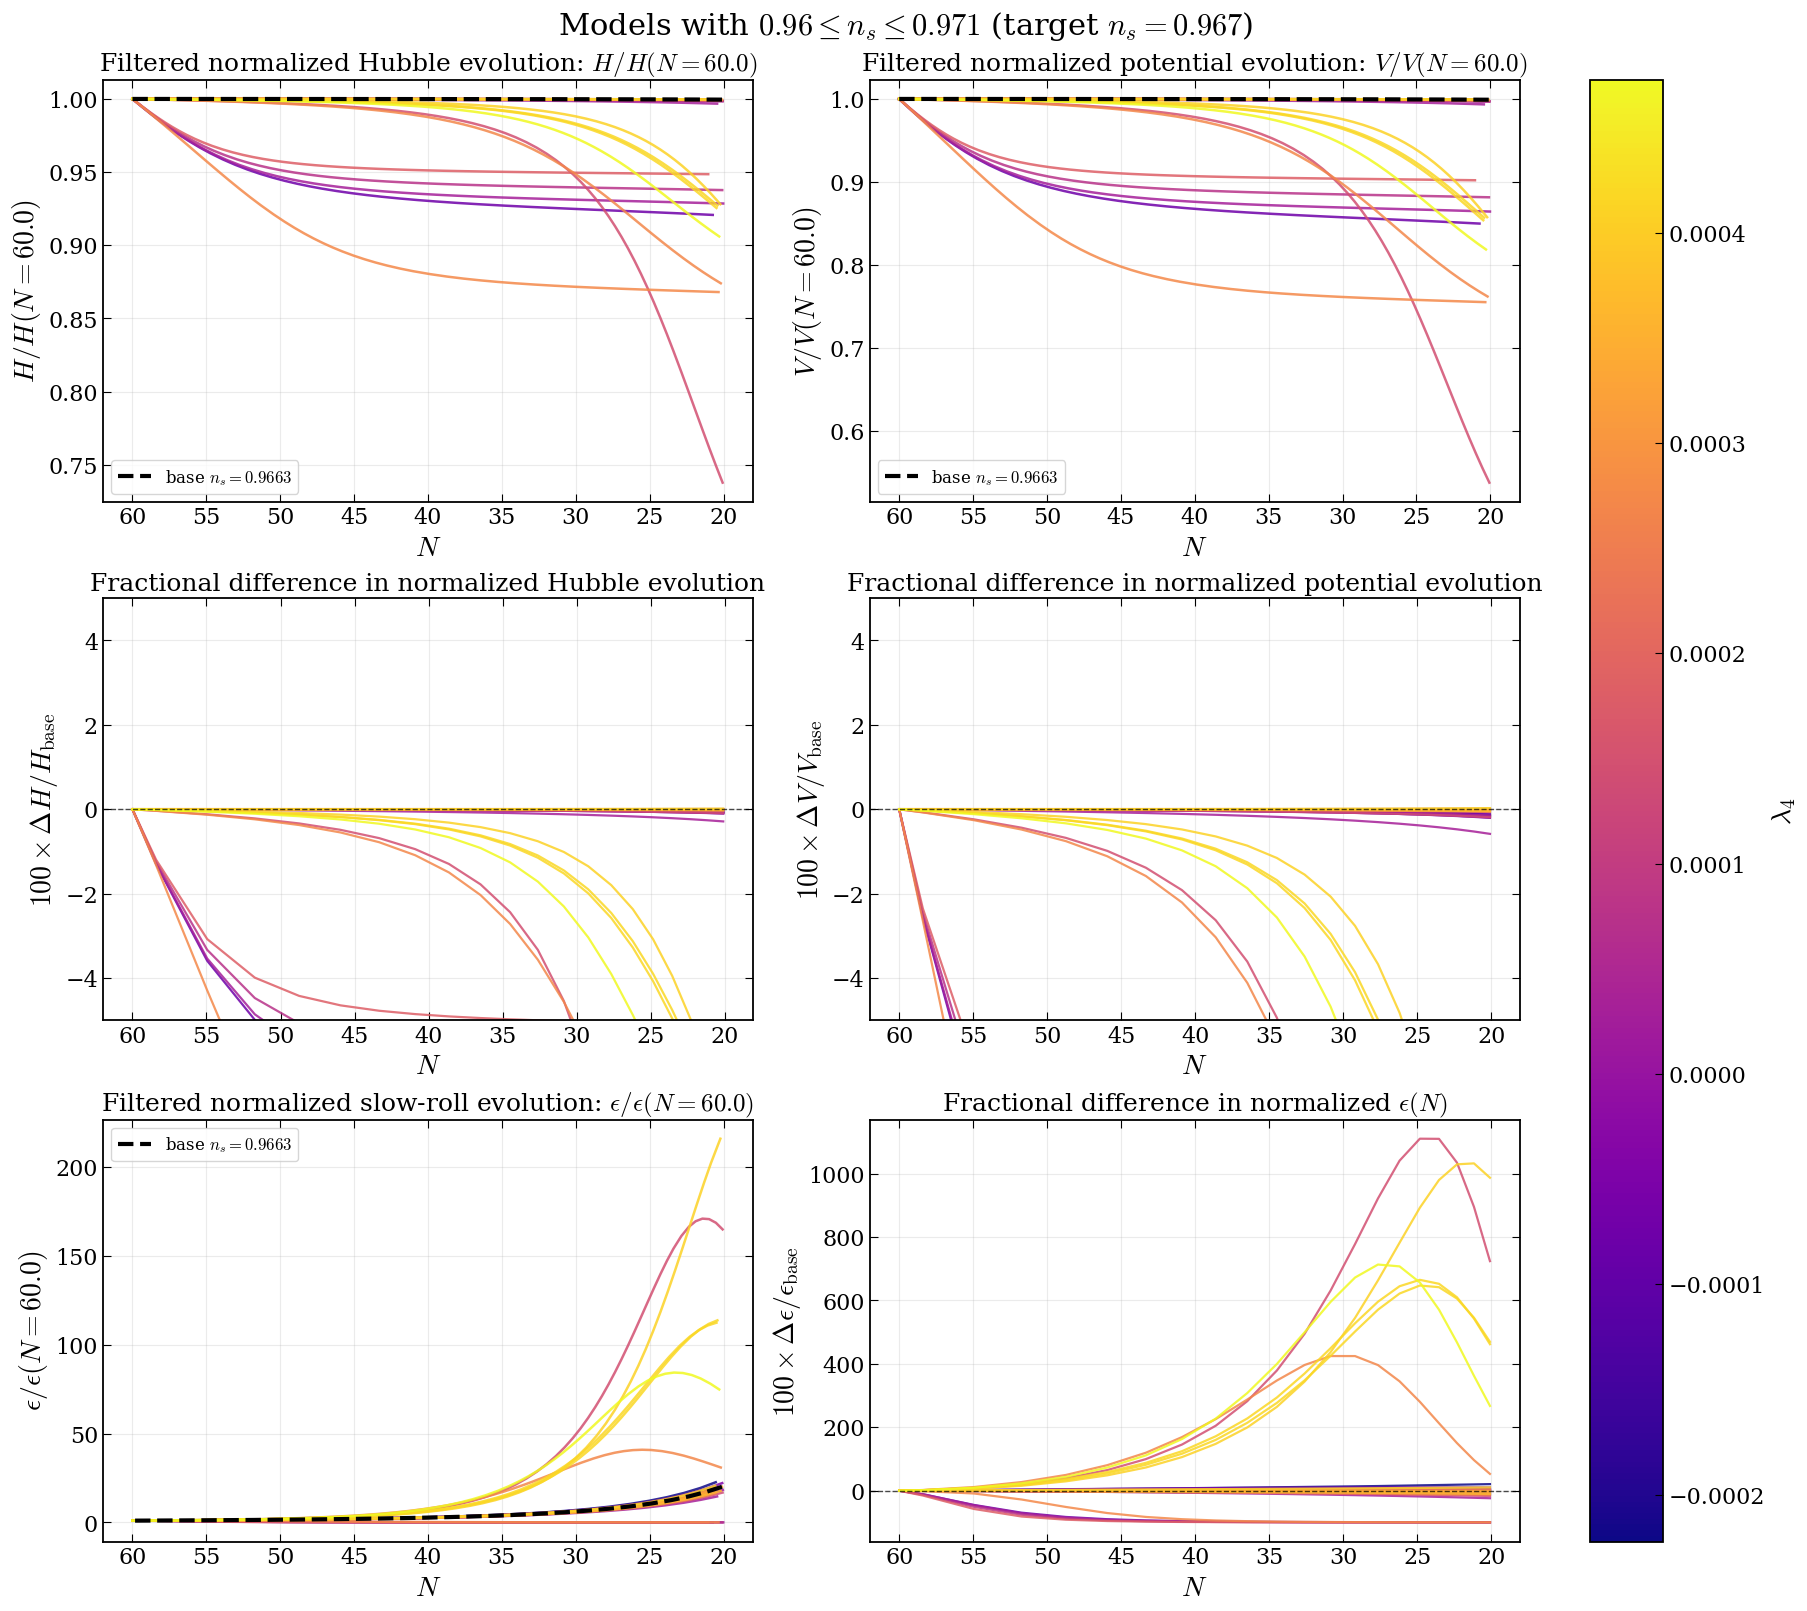


=== Background models summary ===
Total loaded: 30
Base ns: 0.964340
Models in ns window [0.96, 0.971]: 30

=== Background fractional errors in percent ===
     lamX       ns  mean_dH_pct  max_dH_pct  mean_deps_pct  max_deps_pct  mean_dV_pct  max_dV_pct
-0.000046 0.966262     7.019884   17.955379      61.333242    187.401965    14.953717   39.551618
-0.000044 0.961649     7.020435   17.956336      76.404506    224.656069    14.954974   39.553847
-0.000044 0.960608     7.018131   17.949194      77.966008    226.117206    14.949747   39.536901
-0.000041 0.967333     7.022389   17.962977      60.267239    187.359500    14.959499   39.570119
-0.000039 0.964677     7.009260   17.924450      58.943124    171.711179    14.929802   39.477445
-0.000039 0.966099     7.017503   17.948359      60.580367    183.903013    14.948407   39.534877
-0.000033 0.964947     7.009628   17.925200      59.686254    175.889805    14.930607   39.479226
-0.000031 0.967372   -15.084474   19.201249     -84.444536 

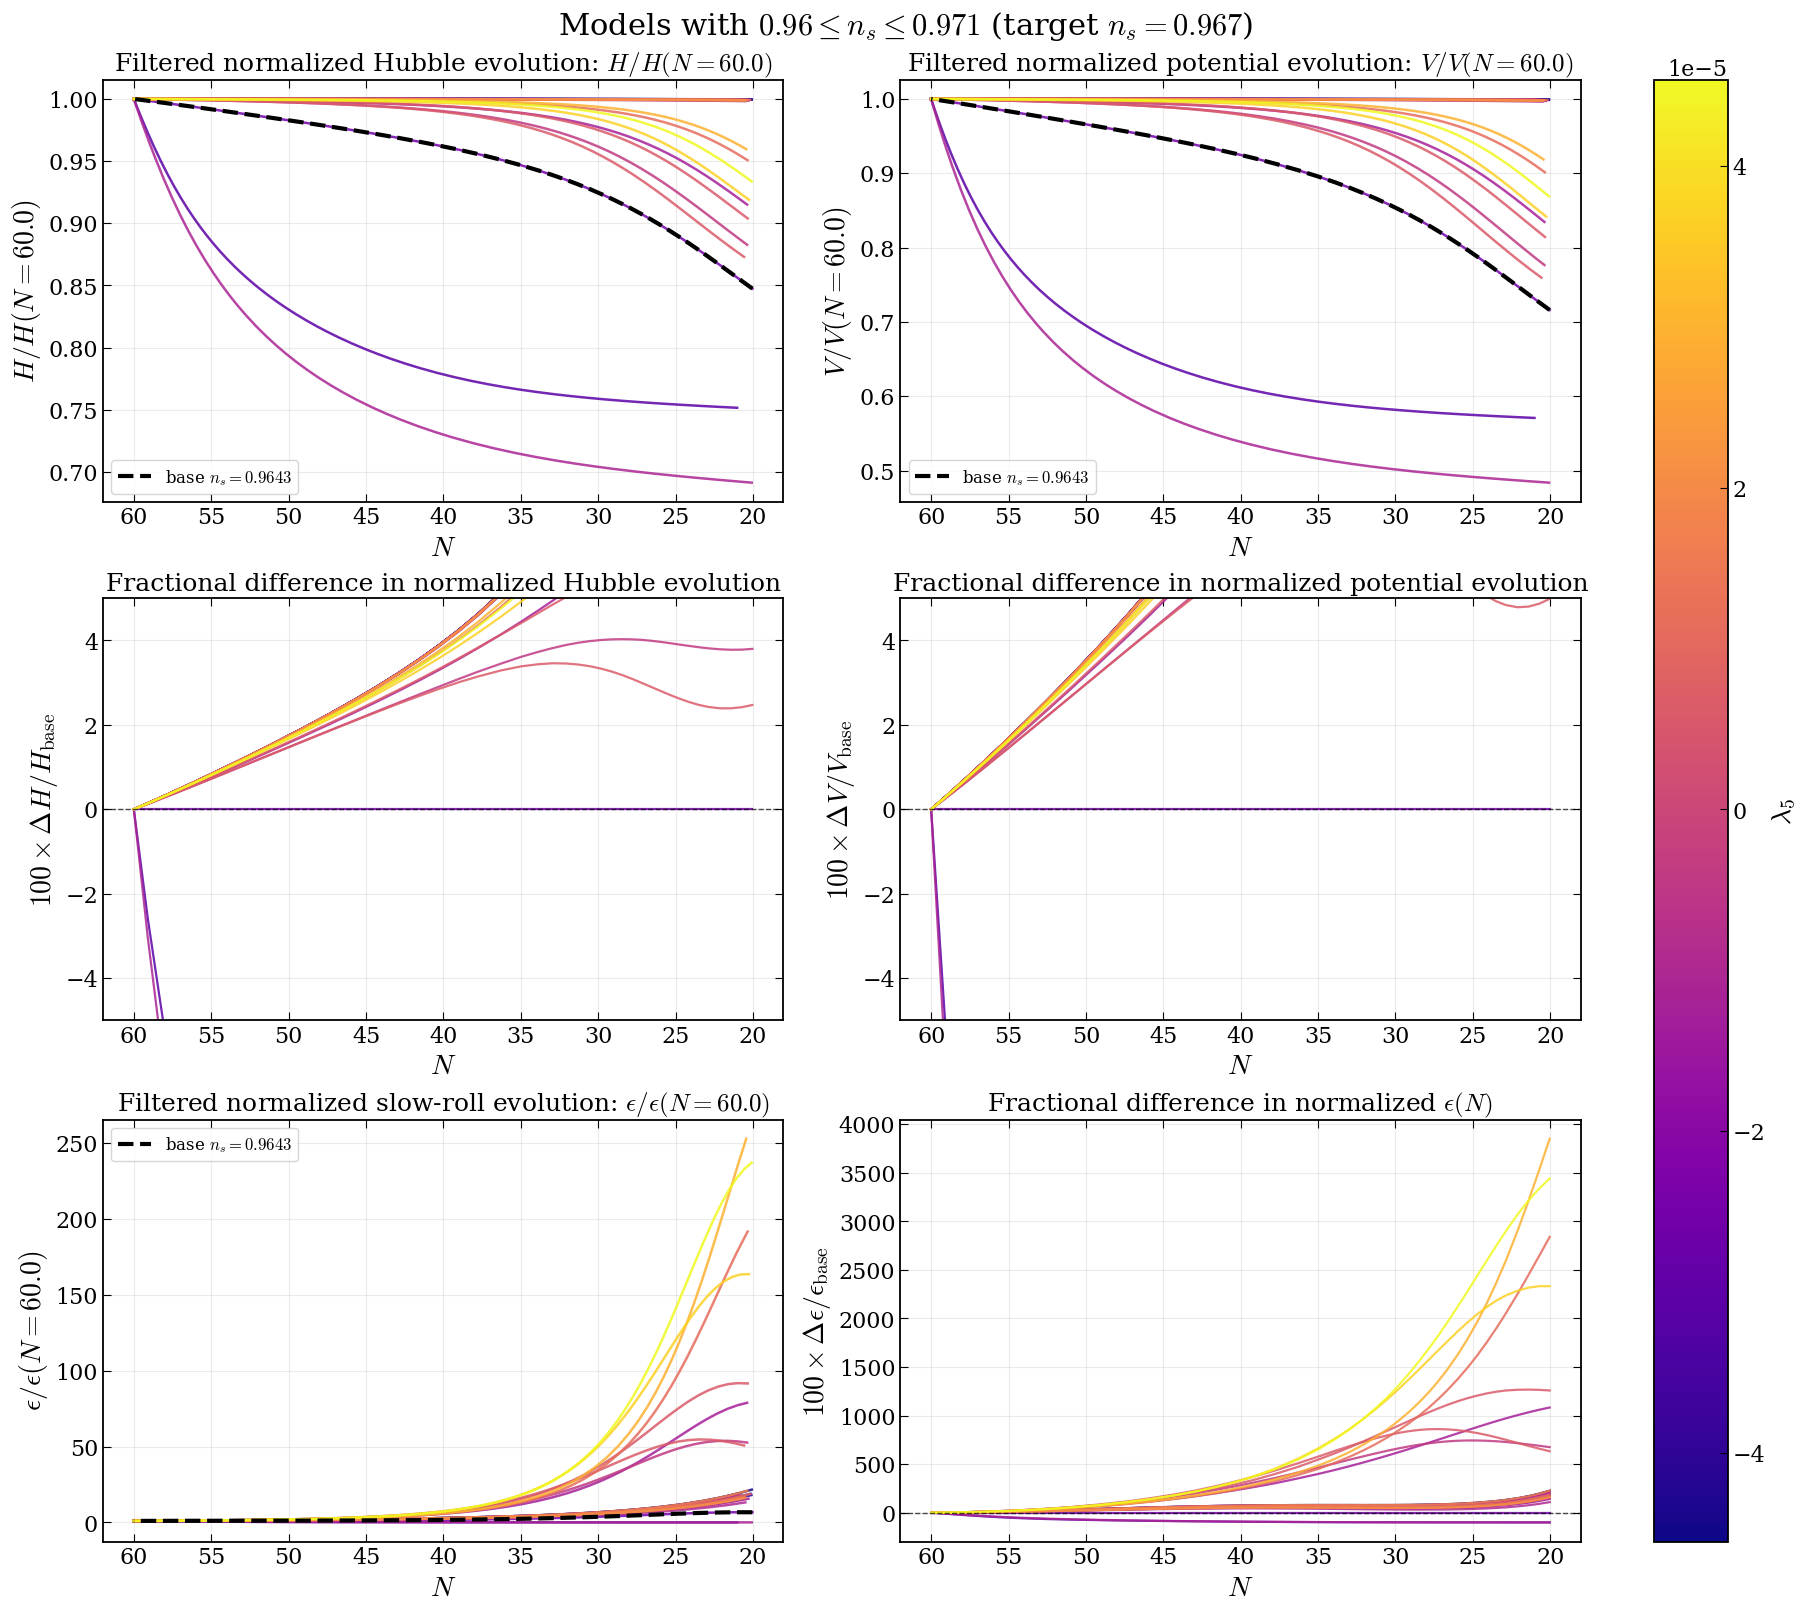

In [161]:
bg7_df = plot_filtered_background_by_ns(
    NEQS=7,
    lamX_values=lam4_values,
    baseX=3.3375788071e-04,#1.7964939234e-04,
    base_path_root=base_path_root,
    ns_min=0.96,
    ns_max=0.971,
    N_ref=60.0,
    N_window=(20, 60),
    frac_ylim=(-5, 5),
    save_name="neqs7_lam4_background_3higherorder_random.png",
)

bg8_df = plot_filtered_background_by_ns(
    NEQS=8,
    lamX_values=lam5_values,
    baseX=-2.5481607795e-05,
    base_path_root=base_path_root,
    ns_min=0.96,
    ns_max=0.971,
    N_ref=60.0,
    N_window=(20, 60),
    frac_ylim=(-5, 5),
    save_name="neqs8_lam5_background_3higherorder_random.png",
)

If my base is:

3.3375788071e-04 goes straight and then down 

1.7964939234e-04 goes down and then straight

## AFTER APPLYING SAID SHIFT

In [147]:
def plot_k_shift_equivalence_scan_2x2(
    NEQS,
    lamX_values,
    baseX,
    base_path_root,
    k_norm=0.05,
    k_min_scalar=None,
    k_max_scalar=10.0,

    frac_ylim=(-0.6, 0.6),
    scalar_ylim=None,
    tensor_ylim=None,

    cmap_name="plasma",
    save_name=None,
):
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": [
            "Computer Modern Roman",
            "Times New Roman",
            "DejaVu Serif",
        ],
        "mathtext.fontset": "cm",

        "axes.labelsize": 16,
        "axes.titlesize": 15,
        "figure.titlesize": 18,

        "xtick.labelsize": 13,
        "ytick.labelsize": 13,

        "legend.fontsize": 11,

        "axes.linewidth": 1.2,

        "xtick.direction": "in",
        "ytick.direction": "in",

        "xtick.top": True,
        "ytick.right": True,

        "xtick.major.size": 6,
        "ytick.major.size": 6,

        "xtick.minor.size": 3,
        "ytick.minor.size": 3,

        "savefig.dpi": 300,
        "savefig.bbox": "tight",
    })

    scan_name, scan_symbol = SCAN_INFO[NEQS]

    def sanitize_lam_values(vals):
        return np.array(
            [x[0] if isinstance(x, tuple) else x for x in vals],
            dtype=float,
        )

    def folder_for(value):
        val_str = f"{value:.10e}"
        return os.path.join(
            base_path_root,
            f"neqs{NEQS}",
            f"{scan_name}_{val_str}",
        )

    def load_specs_local(value):
        folder = folder_for(value)

        s = np.loadtxt(
            os.path.join(folder, f"spec_s_neqs{NEQS}.dat")
        )

        t = np.loadtxt(
            os.path.join(folder, f"spec_t_neqs{NEQS}.dat")
        )

        k_s = s[:, 0]
        Ps = np.abs(s[:, 1])

        k_t = t[:, 0]
        Pt = np.abs(t[:, 1])

        k_s, Ps = prepare_increasing(k_s, Ps)
        k_t, Pt = prepare_increasing(k_t, Pt)

        return k_s, Ps, k_t, Pt

    def get_original_N_end(value):
        summary_file = os.path.join(
            base_path_root,
            f"neqs{NEQS}",
            f"neqs{NEQS}_summary.csv",
        )

        summary_df = pd.read_csv(summary_file)

        matches = summary_df.loc[
            np.isclose(summary_df[scan_name], value)
        ]

        if len(matches) == 0:
            raise ValueError(
                f"No summary row found for {scan_name}={value:.10e}"
            )

        return float(matches.iloc[0]["original_N_end"])

    def normalize_at_k(k, P, k_ref):
        k, P = prepare_increasing(k, P)

        if not (k.min() <= k_ref <= k.max()):
            raise ValueError(
                f"k_ref={k_ref} outside shifted k range "
                f"[{k.min():.3e}, {k.max():.3e}]"
            )

        P_ref = np.interp(k_ref, k, P)

        if np.abs(P_ref) < 1e-30:
            raise ValueError(
                f"Reference spectrum too small at k={k_ref}"
            )

        return k, P / P_ref, P_ref

    def frac_on_base_grid(
        k_base,
        P_base,
        k_cmp,
        P_cmp,
        kmin=None,
        kmax=None,
    ):
        k_base, P_base = prepare_increasing(k_base, P_base)
        k_cmp, P_cmp = prepare_increasing(k_cmp, P_cmp)

        xmin = max(k_base.min(), k_cmp.min())
        xmax = min(k_base.max(), k_cmp.max())

        if kmin is not None:
            xmin = max(xmin, kmin)

        if kmax is not None:
            xmax = min(xmax, kmax)

        mask = (k_base >= xmin) & (k_base <= xmax)

        k_use = k_base[mask]
        P_base_use = P_base[mask]

        if len(k_use) == 0:
            raise ValueError(
                f"No overlapping k range after cuts: "
                f"kmin={kmin}, kmax={kmax}"
            )

        P_cmp_interp = np.interp(k_use, k_cmp, P_cmp)

        frac = (P_cmp_interp - P_base_use) / P_base_use

        return k_use, frac

    def scalar_k_mask(k):
        mask = np.ones_like(k, dtype=bool)

        if k_min_scalar is not None:
            mask &= k >= k_min_scalar

        if k_max_scalar is not None:
            mask &= k <= k_max_scalar

        return mask

    lam_vals = sanitize_lam_values(lamX_values)

    base_N_end = get_original_N_end(baseX)

    (
        k_s_base_raw,
        Ps_base_raw,
        k_t_base_raw,
        Pt_base_raw,
    ) = load_specs_local(baseX)

    k_s_base, Ps_base_norm, _ = normalize_at_k(
        k_s_base_raw,
        Ps_base_raw,
        k_norm,
    )

    k_t_base, Pt_base_norm, _ = normalize_at_k(
        k_t_base_raw,
        Pt_base_raw,
        k_norm,
    )

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(13.5, 9.5),
        constrained_layout=True,
    )

    ax_ps, ax_pt = axes[0]
    ax_ps_err, ax_pt_err = axes[1]

    cmap = plt.get_cmap(cmap_name)

    norm = mcolors.Normalize(
        vmin=np.min(lam_vals),
        vmax=np.max(lam_vals),
    )

    rows = []

    for value in lam_vals:
        try:
            model_N_end = get_original_N_end(value)
            deltaN = model_N_end - base_N_end

            (
                k_s_raw,
                Ps_raw,
                k_t_raw,
                Pt_raw,
            ) = load_specs_local(value)

            k_s_shifted = k_s_raw * np.exp(-deltaN)
            k_t_shifted = k_t_raw * np.exp(-deltaN)

            k_s, Ps_norm, _ = normalize_at_k(
                k_s_shifted,
                Ps_raw,
                k_norm,
            )

            k_t, Pt_norm, _ = normalize_at_k(
                k_t_shifted,
                Pt_raw,
                k_norm,
            )

            k_ps_err, frac_ps = frac_on_base_grid(
                k_s_base,
                Ps_base_norm,
                k_s,
                Ps_norm,
                kmin=k_min_scalar,
                kmax=k_max_scalar,
            )

            k_pt_err, frac_pt = frac_on_base_grid(
                k_t_base,
                Pt_base_norm,
                k_t,
                Pt_norm,
                kmin=None,
                kmax=None,
            )

            color = cmap(norm(value))

            mask_s = scalar_k_mask(k_s)

            ax_ps.loglog(
                k_s[mask_s],
                Ps_norm[mask_s],
                color=color,
                lw=1.25,
                alpha=0.75,
            )

            ax_pt.loglog(
                k_t,
                Pt_norm,
                color=color,
                lw=1.25,
                alpha=0.75,
            )

            ax_ps_err.semilogx(
                k_ps_err,
                100.0 * frac_ps,
                color=color,
                lw=1.1,
                alpha=0.75,
            )

            ax_pt_err.semilogx(
                k_pt_err,
                100.0 * frac_pt,
                color=color,
                lw=1.1,
                alpha=0.75,
            )

            rows.append({
                scan_name: value,
                "original_N_end": model_N_end,
                "deltaN_from_base": deltaN,
                "exp_minus_deltaN": np.exp(-deltaN),
                "mean_dPs_pct": 100.0 * np.nanmean(frac_ps),
                "max_dPs_pct": 100.0 * np.nanmax(np.abs(frac_ps)),
                "mean_dPt_pct": 100.0 * np.nanmean(frac_pt),
                "max_dPt_pct": 100.0 * np.nanmax(np.abs(frac_pt)),
            })

        except FileNotFoundError:
            print(
                f"Missing files for {scan_name}={value:.5e}"
            )

        except ValueError as e:
            print(
                f"Skipping {scan_name}={value:.5e}: {e}"
            )

    mask_base_s = scalar_k_mask(k_s_base)

    ax_ps.loglog(
        k_s_base[mask_base_s],
        Ps_base_norm[mask_base_s],
        color="black",
        lw=2.4,
        ls="--",
        label=rf"Reference ${scan_symbol}={baseX:.2e}$",
    )

    ax_pt.loglog(
        k_t_base,
        Pt_base_norm,
        color="black",
        lw=2.4,
        ls="--",
        label=rf"Reference ${scan_symbol}={baseX:.2e}$",
    )

    for ax in [ax_ps_err, ax_pt_err]:
        ax.axhline(
            0.0,
            color="black",
            ls="--",
            lw=1.0,
            alpha=0.6,
        )

    ax_ps.axvline(
        k_norm,
        color="black",
        ls=":",
        lw=1.1,
        alpha=0.7,
    )

    ax_pt.axvline(
        k_norm,
        color="black",
        ls=":",
        lw=1.1,
        alpha=0.7,
    )

    ax_ps.set_title(r"Scalar spectra")
    ax_pt.set_title(r"Tensor spectra")

    ax_ps_err.set_title(r"Scalar fractional differences")
    ax_pt_err.set_title(r"Tensor fractional differences")

    ax_ps.set_xlabel(r"$k$")
    ax_pt.set_xlabel(r"$k$")
    ax_ps_err.set_xlabel(r"$k$")
    ax_pt_err.set_xlabel(r"$k$")

    ax_ps.set_ylabel(rf"$P_s/P_s(k={k_norm})$")
    ax_pt.set_ylabel(rf"$P_t/P_t(k={k_norm})$")

    ax_ps_err.set_ylabel(r"$100 \times \Delta P_s/P_s \; (\%)$")
    ax_pt_err.set_ylabel(r"$100 \times \Delta P_t/P_t \; (\%)$")

    xmin_scalar = (
        k_min_scalar
        if k_min_scalar is not None
        else np.min(k_s_base[mask_base_s])
    )

    xmax_scalar = (
        k_max_scalar
        if k_max_scalar is not None
        else np.max(k_s_base[mask_base_s])
    )

    ax_ps.set_xlim(xmin_scalar, xmax_scalar)
    ax_ps_err.set_xlim(xmin_scalar, xmax_scalar)

    ax_pt.set_xlim(k_t_base.min(), k_t_base.max())
    ax_pt_err.set_xlim(k_t_base.min(), k_t_base.max())

    ax_ps_err.set_ylim(*frac_ylim)
    ax_pt_err.set_ylim(*frac_ylim)

    if scalar_ylim is not None:
        ax_ps.set_ylim(*scalar_ylim)

    if tensor_ylim is not None:
        ax_pt.set_ylim(*tensor_ylim)

    for ax in axes.ravel():
        ax.minorticks_on()

        ax.grid(
            True,
            which="major",
            alpha=0.25,
            lw=0.8,
        )

        ax.grid(
            True,
            which="minor",
            alpha=0.12,
            lw=0.5,
        )

        ax.tick_params(
            which="both",
            direction="in",
            top=True,
            right=True,
        )

        handles, labels = ax.get_legend_handles_labels()

        if len(handles) > 0:
            ax.legend(
                frameon=False,
                loc="best",
                handlelength=2.6,
                borderpad=0.4,
            )

    sm = cm.ScalarMappable(
        cmap=cmap,
        norm=norm,
    )
    sm.set_array([])

    cbar = fig.colorbar(
        sm,
        ax=axes,
        pad=0.025,
        fraction=0.035,
    )

    cbar.set_label(
        rf"${scan_symbol}$",
        fontsize=16,
    )

    cbar.ax.tick_params(
        labelsize=12,
        direction="in",
    )

    fig.suptitle(
        rf"NEQS={NEQS}: spectra shifted relative to the reference model",
        y=1.02,
    )

    if save_name is None:
        save_name = (
            f"neqs{NEQS}_"
            f"{scan_name}_"
            f"kshifted_spectra_"
            f"kmin{k_min_scalar}_"
            f"kmax{k_max_scalar}.png"
        )

    plt.savefig(save_name, dpi=300, bbox_inches="tight")
    plt.show()

    stats_df = pd.DataFrame(rows)

    if not stats_df.empty:
        print(
            "\n=== Shifted spectra fractional-error summary ==="
        )

        print(
            stats_df[[
                scan_name,
                "deltaN_from_base",
                "mean_dPs_pct",
                "max_dPs_pct",
                "mean_dPt_pct",
                "max_dPt_pct",
            ]].to_string(index=False)
        )

    return stats_df

Skipping lam4=-7.65758e-05: k_ref=0.05 outside shifted k range [6.210e-70, 5.157e-50]
Skipping lam4=-4.12273e-05: k_ref=0.05 outside shifted k range [1.372e+02, 1.139e+22]
Skipping lam4=2.99582e-05: k_ref=0.05 outside shifted k range [7.149e-70, 5.936e-50]
Skipping lam4=3.23807e-05: k_ref=0.05 outside shifted k range [5.498e+01, 4.566e+21]
Skipping lam4=3.71746e-05: k_ref=0.05 outside shifted k range [1.623e+01, 1.348e+21]
Skipping lam4=7.48095e-05: k_ref=0.05 outside shifted k range [1.325e-69, 1.100e-49]
Skipping lam4=1.38564e-04: k_ref=0.05 outside shifted k range [2.456e+03, 2.039e+23]
Skipping lam4=1.46807e-04: k_ref=0.05 outside shifted k range [1.546e-90, 1.284e-70]
Skipping lam4=1.79649e-04: k_ref=0.05 outside shifted k range [2.415e-69, 2.005e-49]
Skipping lam4=2.71438e-04: k_ref=0.05 outside shifted k range [8.782e-86, 7.292e-66]
Skipping lam4=2.72680e-04: k_ref=0.05 outside shifted k range [4.182e-73, 3.473e-53]
Skipping lam4=3.39431e-04: k_ref=0.05 outside shifted k range [

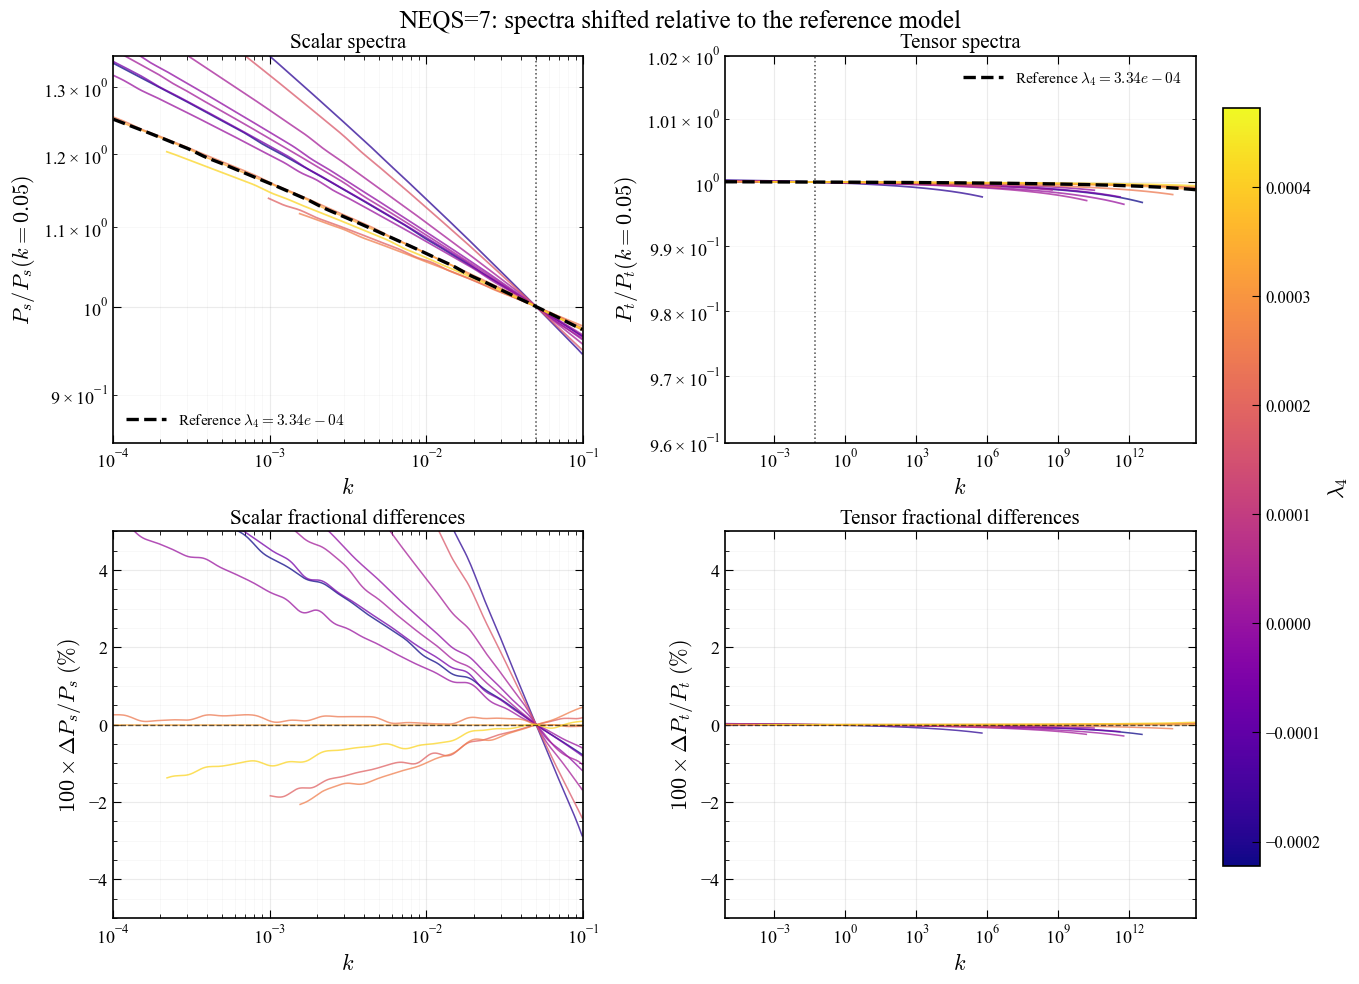


=== Shifted spectra fractional-error summary ===
     lam4  deltaN_from_base  mean_dPs_pct  max_dPs_pct  mean_dPt_pct  max_dPt_pct
-0.000222          5.192230      3.122404     6.924455     -0.047491     0.251246
-0.000186         20.779412     11.677817    26.371963     -0.041719     0.216100
-0.000062          7.346716      3.206244     7.134778     -0.035025     0.178707
-0.000011          9.858591      4.438048     9.886267     -0.015956     0.085905
 0.000007          6.981287      2.422392     5.387207     -0.060049     0.291505
 0.000025         10.608469      3.877397     8.658700     -0.051765     0.249314
 0.000033         13.978372      6.437034    14.217172     -0.018866     0.096641
 0.000166         19.035045      9.753173    21.889736     -0.012504     0.065187
 0.000188         -4.841180     -0.802333     1.871027      0.005393     0.034881
 0.000242          2.225952      0.127191     0.257509     -0.021077     0.103572
 0.000255         -5.296994     -0.802323     2.

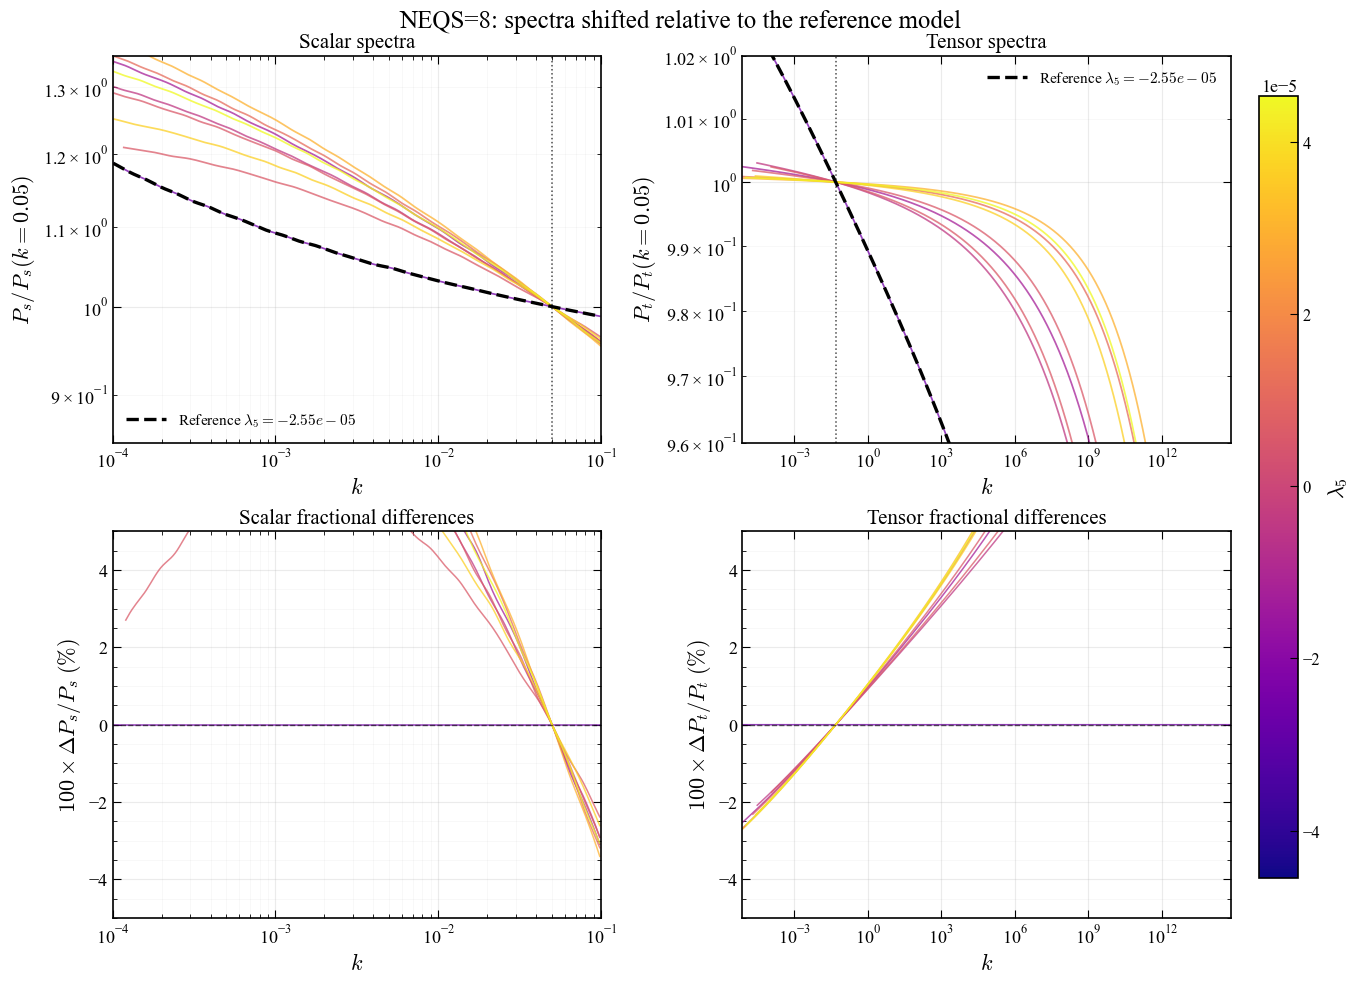


=== Shifted spectra fractional-error summary ===
     lam5  deltaN_from_base  mean_dPs_pct  max_dPs_pct  mean_dPt_pct  max_dPt_pct
-0.000025          0.000000      0.000000     0.000000      0.000000     0.000000
-0.000012          0.303268      8.309497    13.671356      5.390359    13.497964
-0.000004         -1.385057      6.966712    11.059807      4.506167     9.238013
 0.000006         -0.977942      6.701801    10.565361      5.804828    13.670024
 0.000006         -2.710579      3.972594     6.475956      4.832439     9.316241
 0.000011          1.366898      8.789756    14.385669      6.896756    20.433216
 0.000030          1.593324      9.667920    16.223983      7.204012    22.240973
 0.000037         -1.234241      5.413140     8.495029      7.119483    18.301049
 0.000045         -0.326478      7.981819    12.661533      7.415085    20.443721


In [148]:
shift_df = plot_k_shift_equivalence_scan_2x2(
    NEQS=7,
    lamX_values=lam4_values,
    baseX=3.3375788071e-04, #1.7964939234e-04,
    base_path_root=base_path_root,
    k_norm=0.05,
    k_min_scalar=1e-4,
    k_max_scalar=1e-1,
    frac_ylim=(-5, 5),
    scalar_ylim=(0.85, 1.35),
    tensor_ylim=(0.96, 1.02),
    cmap_name="plasma",
    save_name="neqs7_lam4_shifted_spectra_2x2.png",
)


shift_df = plot_k_shift_equivalence_scan_2x2(
    NEQS=8,
    lamX_values=lam5_values,
    baseX=-2.5481607795e-05,
    base_path_root=base_path_root,
    k_norm=0.05,
    k_min_scalar=1e-4,
    k_max_scalar=1e-1,
    frac_ylim=(-5, 5),
    scalar_ylim=(0.85, 1.35),
    tensor_ylim=(0.96, 1.02),
    cmap_name="plasma",
    save_name="neqs8_lam5_shifted_spectra_2x2.png",
)



The span I am seeing for $\Delta$$N$:

In [150]:
def plot_deltaN_histograms_neqs7_neqs8(
    base_path_root,
    base7_value=3.3375788071e-04, #1.7964939234e-04,
    base8_value=-2.5481607795e-05,
    ns_min=None,
    ns_max=None,
    bins=30,
    save_name=None,
    show=True,
):
    plt.rcParams.update({
        "text.usetex": False,
        "mathtext.fontset": "cm",
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman", "DejaVu Serif"],
        "axes.labelsize": 20,
        "axes.titlesize": 18,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 13,
        "figure.titlesize": 22,
        "axes.linewidth": 1.3,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
    })

    configs = [
        {
            "NEQS": 7,
            "param": "lam4",
            "base_value": base7_value,
            "label": r"NEQS=7, $\lambda_4$ scan",
            "color": "plum",
        },
        {
            "NEQS": 8,
            "param": "lam5",
            "base_value": base8_value,
            "label": r"NEQS=8, $\lambda_5$ scan",
            "color": "mediumslateblue",
        },
    ]

    dfs = {}

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(18, 6.5),
        constrained_layout=True,
        sharey=False,
    )

    for ax, cfg in zip(axes, configs):
        NEQS = cfg["NEQS"]
        param = cfg["param"]

        summary_file = os.path.join(
            base_path_root,
            f"neqs{NEQS}",
            f"neqs{NEQS}_summary.csv",
        )

        df = pd.read_csv(summary_file)

        base_row = df.loc[np.isclose(df[param], cfg["base_value"])]

        if len(base_row) == 0:
            raise ValueError(
                f"Could not find base {param}={cfg['base_value']:.10e} "
                f"in {summary_file}"
            )

        base_N_end = float(base_row.iloc[0]["original_N_end"])

        df["deltaN_from_base"] = df["original_N_end"] - base_N_end
        df["abs_deltaN_from_base"] = np.abs(df["deltaN_from_base"])

        if ns_min is not None:
            df = df[df["n_s"] >= ns_min].copy()

        if ns_max is not None:
            df = df[df["n_s"] <= ns_max].copy()

        dfs[f"neqs{NEQS}"] = df

        ax.hist(
            df["deltaN_from_base"],
            bins=bins,
            color=cfg["color"],
            alpha=0.75,
            edgecolor="black",
            linewidth=0.8,
        )

        ax.axvline(
            0.0,
            color="black",
            ls="--",
            lw=1.5,
            label="base model",
        )

        ax.set_title(cfg["label"])
        ax.set_xlabel(r"$\Delta N_{\rm end}=N_{\rm end}-N_{\rm end,base}$")
        ax.set_ylabel("number of models")

        ax.grid(True, alpha=0.25)
        ax.legend(frameon=False)

        print("\n" + "=" * 70)
        print(cfg["label"])
        print("=" * 70)
        print(f"N models shown: {len(df)}")
        print(f"base original_N_end = {base_N_end:.6f}")
        print(df["deltaN_from_base"].describe().to_string())
        print("\nLargest |deltaN| models:")
        print(
            df[[param, "n_s", "original_N_end", "deltaN_from_base", "abs_deltaN_from_base"]]
            .sort_values("abs_deltaN_from_base", ascending=False)
            .head(15)
            .to_string(index=False)
        )

    title = r"Distribution of end-of-inflation offsets"

    if ns_min is not None or ns_max is not None:
        title += rf" for selected $n_s$ models"
    else:
        title += r" for all models"

    fig.suptitle(title, fontsize=22)

    if save_name is None:
        save_name = "deltaN_histograms_neqs7_neqs8.png"

    plt.savefig(save_name, dpi=300, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return dfs


NEQS=7, $\lambda_4$ scan
N models shown: 30
base original_N_end = 794.898142
count     30.000000
mean      62.094592
std       85.955841
min      -23.591479
25%       -4.467846
50%       10.233530
75%      147.557079
max      195.034548

Largest |deltaN| models:
     lam4      n_s  original_N_end  deltaN_from_base  abs_deltaN_from_base
 0.000147 0.964029      989.932690        195.034548            195.034548
 0.000409 0.966168      989.923648        195.025506            195.025506
 0.000420 0.965591      984.880379        189.982237            189.982237
 0.000416 0.963215      984.475582        189.577440            189.577440
 0.000473 0.964574      980.032640        185.134498            185.134498
 0.000271 0.961065      978.985308        184.087166            184.087166
 0.000273 0.961685      949.793568        154.895426            154.895426
-0.000077 0.969593      942.490400        147.592258            147.592258
 0.000030 0.961268      942.349682        147.451540         

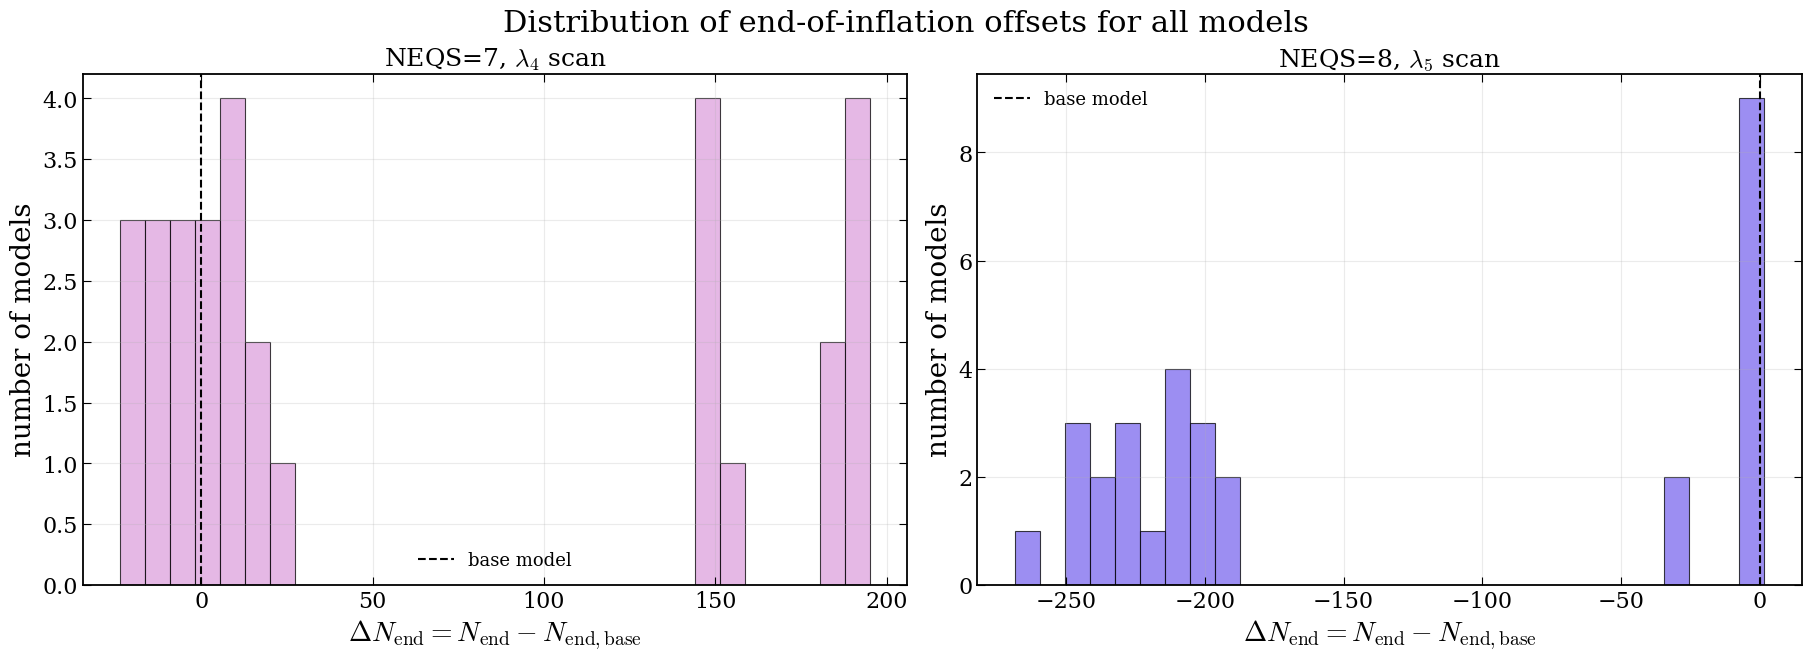

In [151]:
deltaN_dfs = plot_deltaN_histograms_neqs7_neqs8(
    base_path_root=base_path_root,
    bins=30,
    save_name="deltaN_histograms_neqs7_neqs8_all.png",
) 
  

Finally,

In [152]:
def plot_valid_ns_before_after_kshift_envelopes(
    base_path_root,
    lam_values_by_neqs,
    ref_NEQS=7,
    ref_param="lam4",
    ref_value=6.87065e-8,
    ns_min=0.963,
    ns_max=0.970,
    k_norm=0.05,
    k_min_scalar=1e-4,
    k_max_scalar=1e-1,
    max_abs_deltaN=None,
    tolerance=5.0,
    skip_zero=True,
    zero_tol=1e-30,
    save_name=None,
):
    plt.rcParams.update({
        "text.usetex": False,
        "mathtext.fontset": "cm",
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman", "DejaVu Serif"],
        "axes.labelsize": 18,
        "axes.titlesize": 17,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 11,
        "figure.titlesize": 22,
        "axes.linewidth": 1.3,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
    })

    colors_by_neqs = {
        7: "plum",
        8: "mediumslateblue",
    }

    def folder_for(NEQS, param_name, value):
        val_str = f"{value:.10e}"
        return os.path.join(
            base_path_root,
            f"neqs{NEQS}",
            f"{param_name}_{val_str}",
        )

    def load_specs(NEQS, param_name, value):
        folder = folder_for(NEQS, param_name, value)

        s = np.loadtxt(os.path.join(folder, f"spec_s_neqs{NEQS}.dat"))
        t = np.loadtxt(os.path.join(folder, f"spec_t_neqs{NEQS}.dat"))

        k_s, Ps = prepare_increasing(s[:, 0], np.abs(s[:, 1]))
        k_t, Pt = prepare_increasing(t[:, 0], np.abs(t[:, 1]))

        return k_s, Ps, k_t, Pt

    def load_observables(NEQS, param_name, value):
        folder = folder_for(NEQS, param_name, value)
        arr = np.loadtxt(os.path.join(folder, f"test_nr_neqs{NEQS}.dat"))
        arr = np.atleast_1d(arr)
        return arr[0], arr[1], arr[2]

    def get_original_N_end(NEQS, param_name, value):
        summary_file = os.path.join(
            base_path_root,
            f"neqs{NEQS}",
            f"neqs{NEQS}_summary.csv",
        )

        summary_df = pd.read_csv(summary_file)
        matches = summary_df.loc[np.isclose(summary_df[param_name], value)]

        if len(matches) == 0:
            raise ValueError(
                f"No summary row found for NEQS={NEQS}, "
                f"{param_name}={value:.10e}"
            )

        return float(matches.iloc[0]["original_N_end"])

    def normalize_at_k(k, P, k_ref):
        k, P = prepare_increasing(k, P)

        if not (k.min() <= k_ref <= k.max()):
            raise ValueError(
                f"k_ref={k_ref} outside range [{k.min():.3e}, {k.max():.3e}]"
            )

        P_ref = np.interp(k_ref, k, P)

        if np.abs(P_ref) < 1e-30:
            raise ValueError(f"Reference spectrum too small at k={k_ref}")

        return k, P / P_ref

    def frac_on_ref_grid(
        k_ref_grid,
        P_ref_norm,
        k_cmp,
        P_cmp_norm,
        kmin=None,
        kmax=None,
    ):
        k_ref_grid, P_ref_norm = prepare_increasing(k_ref_grid, P_ref_norm)
        k_cmp, P_cmp_norm = prepare_increasing(k_cmp, P_cmp_norm)

        xmin = max(k_ref_grid.min(), k_cmp.min())
        xmax = min(k_ref_grid.max(), k_cmp.max())

        if kmin is not None:
            xmin = max(xmin, kmin)

        if kmax is not None:
            xmax = min(xmax, kmax)

        if xmin >= xmax:
            return np.array([]), np.array([])

        mask = (k_ref_grid >= xmin) & (k_ref_grid <= xmax)
        k_use = k_ref_grid[mask]

        if len(k_use) == 0:
            return np.array([]), np.array([])

        P_ref_use = P_ref_norm[mask]
        P_cmp_interp = np.interp(k_use, k_cmp, P_cmp_norm)

        frac = (P_cmp_interp - P_ref_use) / P_ref_use
        return k_use, frac

    def collect_envelope(frac_curves, k_ref_grid):
        if len(frac_curves) == 0:
            return None, None, None

        k_env = k_ref_grid.copy()
        frac_stack = []

        for k_curve, frac_curve in frac_curves:
            if len(k_curve) < 2:
                continue

            interp = np.interp(
                k_env,
                k_curve,
                frac_curve,
                left=np.nan,
                right=np.nan,
            )

            if np.all(~np.isfinite(interp)):
                continue

            frac_stack.append(interp)

        if len(frac_stack) == 0:
            return None, None, None

        frac_stack = np.array(frac_stack)

        valid_cols = np.any(np.isfinite(frac_stack), axis=0)
        frac_stack = frac_stack[:, valid_cols]
        k_env = k_env[valid_cols]

        abs_stack = np.abs(frac_stack)

        mean_abs = 100.0 * np.nanmean(abs_stack, axis=0)
        max_abs = 100.0 * np.nanmax(abs_stack, axis=0)

        return k_env, mean_abs, max_abs

    # Reference spectra
    ref_N_end = get_original_N_end(ref_NEQS, ref_param, ref_value)

    k_s_ref_raw, Ps_ref_raw, k_t_ref_raw, Pt_ref_raw = load_specs(
        ref_NEQS,
        ref_param,
        ref_value,
    )

    k_s_ref, Ps_ref_norm = normalize_at_k(k_s_ref_raw, Ps_ref_raw, k_norm)
    k_t_ref, Pt_ref_norm = normalize_at_k(k_t_ref_raw, Pt_ref_raw, k_norm)

    curves = {
        NEQS: {
            "Ps_unshift": [],
            "Ps_shift": [],
            "Pt_unshift": [],
            "Pt_shift": [],
            "rows": [],
            "skipped_deltaN": 0,
            "skipped_ns": 0,
            "skipped_other": 0,
        }
        for NEQS in lam_values_by_neqs.keys()
    }

    for NEQS, lam_values in lam_values_by_neqs.items():
        param_name, _ = SCAN_INFO[NEQS]

        for item in lam_values:
            value = item[0] if isinstance(item, tuple) else item
            value = float(value)

            if skip_zero and np.isclose(value, 0.0, atol=zero_tol):
                continue

            try:
                r, ns, alpha_s = load_observables(NEQS, param_name, value)

                if not (ns_min <= ns <= ns_max):
                    curves[NEQS]["skipped_ns"] += 1
                    continue

                model_N_end = get_original_N_end(NEQS, param_name, value)
                deltaN = model_N_end - ref_N_end
                abs_deltaN = np.abs(deltaN)

                if max_abs_deltaN is not None and abs_deltaN > max_abs_deltaN:
                    curves[NEQS]["skipped_deltaN"] += 1
                    continue

                k_s_raw, Ps_raw, k_t_raw, Pt_raw = load_specs(
                    NEQS,
                    param_name,
                    value,
                )

                # Unshifted comparison
                k_s_un, Ps_un = normalize_at_k(k_s_raw, Ps_raw, k_norm)
                k_t_un, Pt_un = normalize_at_k(k_t_raw, Pt_raw, k_norm)

                k_ps_un, frac_ps_un = frac_on_ref_grid(
                    k_s_ref,
                    Ps_ref_norm,
                    k_s_un,
                    Ps_un,
                    kmin=k_min_scalar,
                    kmax=k_max_scalar,
                )

                k_pt_un, frac_pt_un = frac_on_ref_grid(
                    k_t_ref,
                    Pt_ref_norm,
                    k_t_un,
                    Pt_un,
                )

                # Shifted comparison
                k_s_shifted = k_s_raw * np.exp(-deltaN)
                k_t_shifted = k_t_raw * np.exp(-deltaN)

                k_s_sh, Ps_sh = normalize_at_k(k_s_shifted, Ps_raw, k_norm)
                k_t_sh, Pt_sh = normalize_at_k(k_t_shifted, Pt_raw, k_norm)

                k_ps_sh, frac_ps_sh = frac_on_ref_grid(
                    k_s_ref,
                    Ps_ref_norm,
                    k_s_sh,
                    Ps_sh,
                    kmin=k_min_scalar,
                    kmax=k_max_scalar,
                )

                k_pt_sh, frac_pt_sh = frac_on_ref_grid(
                    k_t_ref,
                    Pt_ref_norm,
                    k_t_sh,
                    Pt_sh,
                )

                if (
                    len(frac_ps_un) == 0
                    or len(frac_ps_sh) == 0
                    or len(frac_pt_un) == 0
                    or len(frac_pt_sh) == 0
                ):
                    curves[NEQS]["skipped_other"] += 1
                    continue

                curves[NEQS]["Ps_unshift"].append((k_ps_un, frac_ps_un))
                curves[NEQS]["Ps_shift"].append((k_ps_sh, frac_ps_sh))
                curves[NEQS]["Pt_unshift"].append((k_pt_un, frac_pt_un))
                curves[NEQS]["Pt_shift"].append((k_pt_sh, frac_pt_sh))

                curves[NEQS]["rows"].append({
                    "NEQS": NEQS,
                    "param_name": param_name,
                    "value": value,
                    "r": r,
                    "ns": ns,
                    "alpha_s": alpha_s,
                    "original_N_end": model_N_end,
                    "deltaN_from_ref_base": deltaN,
                    "abs_deltaN_from_ref_base": abs_deltaN,
                    "k_min_scalar": k_min_scalar,
                    "k_max_scalar": k_max_scalar,
                    "max_abs_deltaN_cut": max_abs_deltaN,

                    "max_Ps_unshift_pct": 100.0 * np.nanmax(np.abs(frac_ps_un)),
                    "max_Ps_shift_pct": 100.0 * np.nanmax(np.abs(frac_ps_sh)),
                    "max_Pt_unshift_pct": 100.0 * np.nanmax(np.abs(frac_pt_un)),
                    "max_Pt_shift_pct": 100.0 * np.nanmax(np.abs(frac_pt_sh)),

                    "mean_Ps_unshift_pct": 100.0 * np.nanmean(np.abs(frac_ps_un)),
                    "mean_Ps_shift_pct": 100.0 * np.nanmean(np.abs(frac_ps_sh)),
                    "mean_Pt_unshift_pct": 100.0 * np.nanmean(np.abs(frac_pt_un)),
                    "mean_Pt_shift_pct": 100.0 * np.nanmean(np.abs(frac_pt_sh)),
                })

            except FileNotFoundError:
                print(f"Missing files for NEQS={NEQS}, {param_name}={value:.5e}")
                curves[NEQS]["skipped_other"] += 1

            except ValueError as e:
                print(f"Skipping NEQS={NEQS}, {param_name}={value:.5e}: {e}")
                curves[NEQS]["skipped_other"] += 1

    # Plot
    fig, axes = plt.subplots(
        2,
        2,
        figsize=(16, 10.5),
        constrained_layout=True,
    )

    ax_ps_un, ax_ps_sh = axes[0]
    ax_pt_un, ax_pt_sh = axes[1]

    plot_specs = [
        ("Ps_unshift", ax_ps_un, k_s_ref, k_min_scalar, k_max_scalar, r"$P_s$", "Before $k$-shift"),
        ("Ps_shift", ax_ps_sh, k_s_ref, k_min_scalar, k_max_scalar, r"$P_s$", r"After $k \to k e^{-\Delta N}$"),
        ("Pt_unshift", ax_pt_un, k_t_ref, None, None, r"$P_t$", "Before $k$-shift"),
        ("Pt_shift", ax_pt_sh, k_t_ref, None, None, r"$P_t$", r"After $k \to k e^{-\Delta N}$"),
    ]

    envelope_rows = []

    for key, ax, k_ref_grid, kmin, kmax, quantity_label, title_suffix in plot_specs:
        for NEQS in lam_values_by_neqs.keys():
            color = colors_by_neqs.get(NEQS, None)

            k_env, mean_abs, max_abs = collect_envelope(
                curves[NEQS][key],
                k_ref_grid,
            )

            if k_env is None:
                continue

            mask = np.ones_like(k_env, dtype=bool)

            if kmin is not None:
                mask &= k_env >= kmin

            if kmax is not None:
                mask &= k_env <= kmax

            k_env = k_env[mask]
            mean_abs = mean_abs[mask]
            max_abs = max_abs[mask]

            if len(k_env) == 0:
                continue

            ax.plot(
                k_env,
                mean_abs,
                color=color,
                lw=2.2,
                label=rf"NEQS={NEQS} mean",
            )

            ax.fill_between(
                k_env,
                0.0,
                max_abs,
                color=color,
                alpha=0.20,
                label=rf"NEQS={NEQS} max",
            )

            envelope_rows.append({
                "NEQS": NEQS,
                "case": key,
                "n_models": len(curves[NEQS][key]),
                "median_mean_abs_pct": np.nanmedian(mean_abs),
                "max_envelope_pct": np.nanmax(max_abs),
                "k_min_scalar": k_min_scalar if "Ps" in key else np.nan,
                "k_max_scalar": k_max_scalar if "Ps" in key else np.nan,
                "max_abs_deltaN_cut": max_abs_deltaN,
            })

        # 5% tolerance line
        ax.axhline(
            tolerance,
            color="black",
            lw=1.7,
            ls="--",
            label=rf"{tolerance:.0f}% tolerance",
        )

#         ax.text(
#             0.97,
#             0.92,
#             rf"{tolerance:.0f}% tolerance",
#             transform=ax.transAxes,
#             ha="right",
#             va="top",
#             fontsize=11,
#             bbox=dict(
#                 facecolor="white",
#                 edgecolor="none",
#                 alpha=0.80,
#             ),
#         )

        ax.set_xscale("log")
#         ax.set_yscale("log")

        ax.grid(True, which="major", alpha=0.25)
        ax.grid(True, which="minor", alpha=0.12)
        ax.minorticks_on()

        ax.set_title(rf"{quantity_label} error envelope: {title_suffix}")
        ax.set_xlabel(r"$k$")
        ax.set_ylabel(rf"$|\Delta {quantity_label}/{quantity_label}|$ [\%]")

        if kmin is not None or kmax is not None:
            xmin = kmin if kmin is not None else k_ref_grid.min()
            xmax = kmax if kmax is not None else k_ref_grid.max()
            ax.set_xlim(xmin, xmax)

        ax.legend(
            fontsize=9,
            frameon=False,
            loc="best",
        )

    cut_text = ""

    if max_abs_deltaN is not None:
        cut_text += rf", $|\Delta N| \leq {max_abs_deltaN}$"

    if k_min_scalar is not None or k_max_scalar is not None:
        kmin_text = k_min_scalar if k_min_scalar is not None else k_s_ref.min()
        kmax_text = k_max_scalar if k_max_scalar is not None else k_s_ref.max()
        cut_text += rf", scalar $k\in[{kmin_text:.0e},{kmax_text:.0e}]$"

    fig.suptitle(
        rf"Valid-$n_s$ spectral-error envelopes relative to NEQS={ref_NEQS} base "
        rf"(${ns_min}<n_s<{ns_max}$){cut_text}",
        fontsize=20,
    )

    if save_name is None:
        save_name = (
            f"valid_ns_error_envelopes_before_after_shift_"
            f"ref_neqs{ref_NEQS}.png"
        )

    plt.savefig(save_name, dpi=300, bbox_inches="tight")
    plt.show()

    model_rows = []
    for NEQS in lam_values_by_neqs.keys():
        model_rows.extend(curves[NEQS]["rows"])

    model_df = pd.DataFrame(model_rows)
    envelope_df = pd.DataFrame(envelope_rows)

    print("\n=== Cut summary ===")
    for NEQS in lam_values_by_neqs.keys():
        print(
            f"NEQS={NEQS}: kept={len(curves[NEQS]['rows'])}, "
            f"skipped_ns={curves[NEQS]['skipped_ns']}, "
            f"skipped_deltaN={curves[NEQS]['skipped_deltaN']}, "
            f"skipped_other={curves[NEQS]['skipped_other']}"
        )

    print("\n=== Envelope summary ===")
    if not envelope_df.empty:
        print(envelope_df.to_string(index=False))

    print("\n=== Model-level summary ===")
    if not model_df.empty:
        print(model_df.to_string(index=False))

    return model_df, envelope_df

Skipping NEQS=7, lam4=3.23807e-05: k_ref=0.05 outside range [5.498e+01, 4.566e+21]
Skipping NEQS=7, lam4=3.71746e-05: k_ref=0.05 outside range [1.623e+01, 1.348e+21]
Skipping NEQS=7, lam4=1.38564e-04: k_ref=0.05 outside range [2.456e+03, 2.039e+23]
Skipping NEQS=7, lam4=3.66731e-04: k_ref=0.05 outside range [6.744e-01, 5.600e+19]
Skipping NEQS=8, lam5=-4.55299e-05: k_ref=0.05 outside range [1.950e+01, 1.619e+21]
Skipping NEQS=8, lam5=-3.87638e-05: k_ref=0.05 outside range [4.592e+02, 3.814e+22]
Skipping NEQS=8, lam5=-8.46131e-06: k_ref=0.05 outside range [6.371e-02, 5.291e+18]
Skipping NEQS=8, lam5=1.17035e-05: k_ref=0.05 outside range [4.823e+01, 4.005e+21]


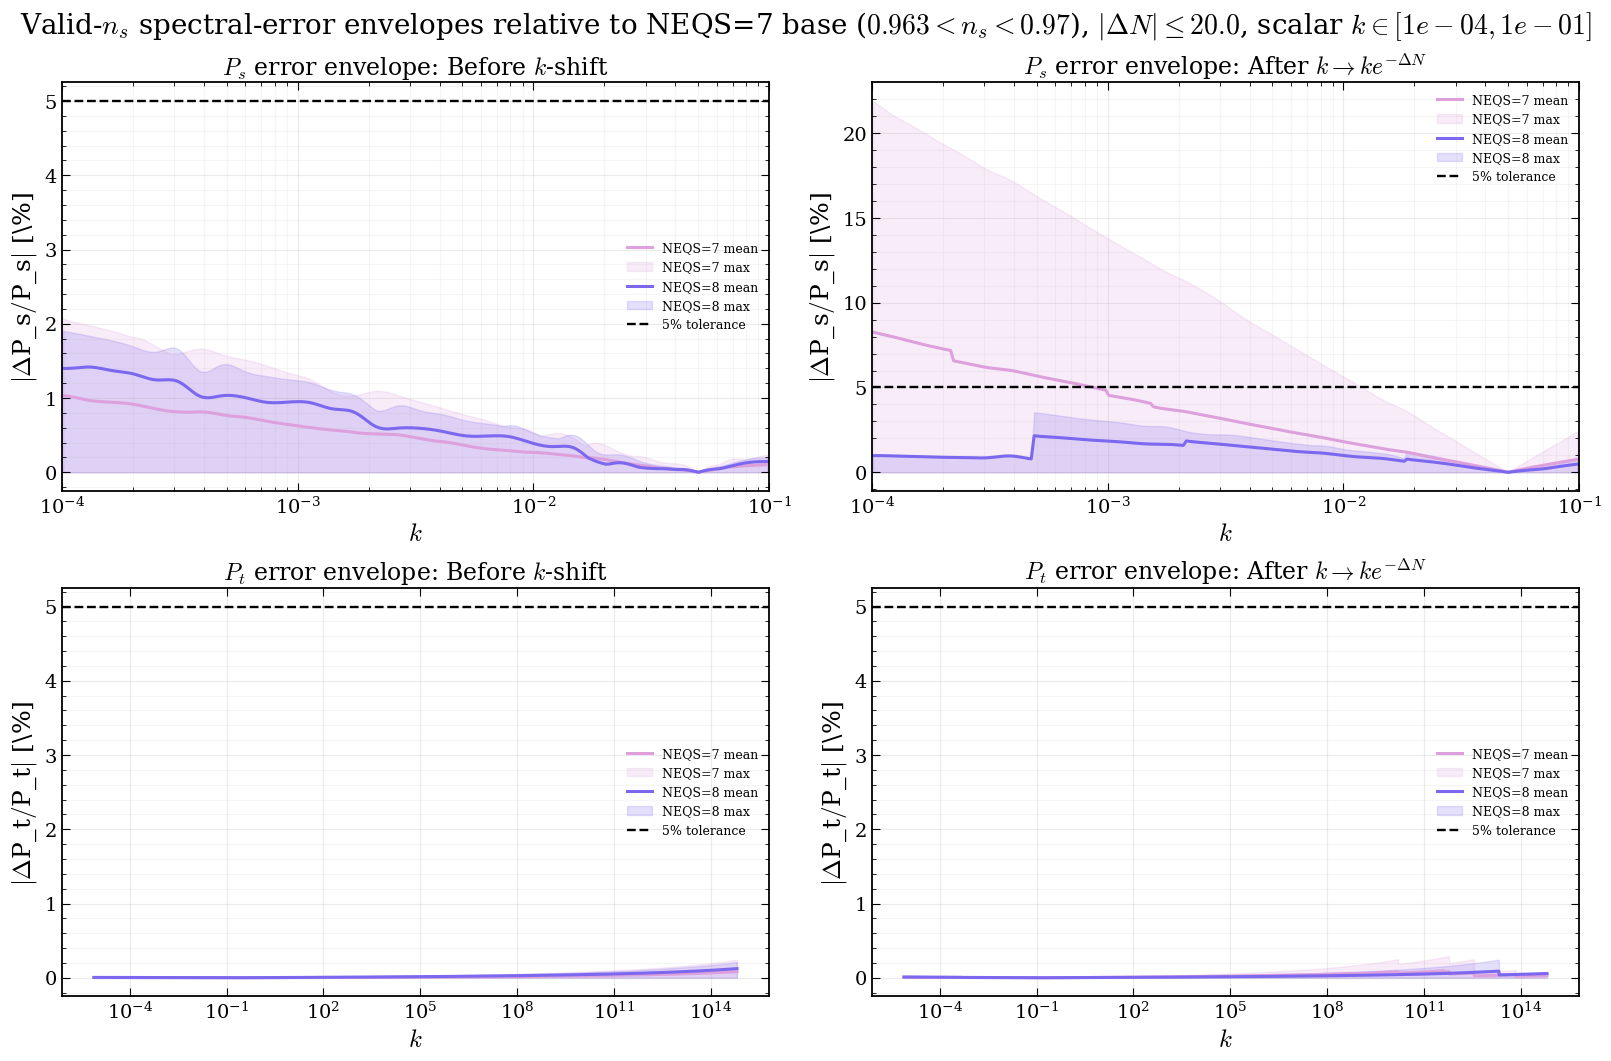


=== Cut summary ===
NEQS=7: kept=12, skipped_ns=4, skipped_deltaN=10, skipped_other=4
NEQS=8: kept=4, skipped_ns=8, skipped_deltaN=14, skipped_other=4

=== Envelope summary ===
 NEQS       case  n_models  median_mean_abs_pct  max_envelope_pct  k_min_scalar  k_max_scalar  max_abs_deltaN_cut
    7 Ps_unshift        12             0.468010          2.067320        0.0001           0.1                20.0
    8 Ps_unshift         4             0.587352          1.905048        0.0001           0.1                20.0
    7   Ps_shift        12             3.127201         21.889736        0.0001           0.1                20.0
    8   Ps_shift         4             0.955457          3.545221        0.0001           0.1                20.0
    7 Pt_unshift        12             0.008785          0.244211           NaN           NaN                20.0
    8 Pt_unshift         4             0.014830          0.212559           NaN           NaN                20.0
    7   Pt_shift        

In [154]:
lam_values_by_neqs = {
    7: lam4_values,
    8: lam5_values,
}

model_df, envelope_df = plot_valid_ns_before_after_kshift_envelopes(
    base_path_root=base_path_root,
    lam_values_by_neqs=lam_values_by_neqs,
    ref_NEQS=7,
    ref_param="lam4",
    ref_value= 3.3375788071e-04, #1.7964939234e-04,
    ns_min=0.963,
    ns_max=0.97,
    k_norm=0.05,
    k_min_scalar=1e-4,
    k_max_scalar=1e-1,
    max_abs_deltaN=20.0,
    skip_zero=True,
    save_name="valid_ns_before_after_kshift_envelopes_ref_neqs7_dN10_k1e-4_1e-1_nonhiggs.png",
)

In [157]:
def plot_valid_ns_before_after_kshift_envelopes_rminmax(
    base_path_root,
    lam_values_by_neqs,
    ref_NEQS=7,
    ref_param="lam4",
    ref_value=6.87065e-8,
    ns_min=0.963,
    ns_max=0.970,
    r_min=None,
    r_max=None,
    k_norm=0.05,
    k_min_scalar=1e-4,
    k_max_scalar=1e-1,
    max_abs_deltaN=None,
    tolerance=5.0,
    skip_zero=True,
    zero_tol=1e-30,
    save_name=None,
):
    plt.rcParams.update({
        "text.usetex": False,
        "mathtext.fontset": "cm",
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman", "DejaVu Serif"],
        "axes.labelsize": 18,
        "axes.titlesize": 17,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 11,
        "figure.titlesize": 22,
        "axes.linewidth": 1.3,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
    })

    colors_by_neqs = {
        7: "plum",
        8: "mediumslateblue",
        9: "royalblue",
    }

    def folder_for(NEQS, param_name, value):
        val_str = f"{value:.10e}"
        return os.path.join(
            base_path_root,
            f"neqs{NEQS}",
            f"{param_name}_{val_str}",
        )

    def load_specs(NEQS, param_name, value):
        folder = folder_for(NEQS, param_name, value)

        s = np.loadtxt(os.path.join(folder, f"spec_s_neqs{NEQS}.dat"))
        t = np.loadtxt(os.path.join(folder, f"spec_t_neqs{NEQS}.dat"))

        k_s, Ps = prepare_increasing(s[:, 0], np.abs(s[:, 1]))
        k_t, Pt = prepare_increasing(t[:, 0], np.abs(t[:, 1]))

        return k_s, Ps, k_t, Pt

    def load_observables(NEQS, param_name, value):
        folder = folder_for(NEQS, param_name, value)
        arr = np.loadtxt(os.path.join(folder, f"test_nr_neqs{NEQS}.dat"))
        arr = np.atleast_1d(arr)
        return arr[0], arr[1], arr[2]

    def get_original_N_end(NEQS, param_name, value):
        summary_file = os.path.join(
            base_path_root,
            f"neqs{NEQS}",
            f"neqs{NEQS}_summary.csv",
        )

        summary_df = pd.read_csv(summary_file)
        matches = summary_df.loc[np.isclose(summary_df[param_name], value)]

        if len(matches) == 0:
            raise ValueError(
                f"No summary row found for NEQS={NEQS}, "
                f"{param_name}={value:.10e}"
            )

        return float(matches.iloc[0]["original_N_end"])

    def normalize_at_k(k, P, k_ref):
        k, P = prepare_increasing(k, P)

        if not (k.min() <= k_ref <= k.max()):
            raise ValueError(
                f"k_ref={k_ref} outside range [{k.min():.3e}, {k.max():.3e}]"
            )

        P_ref = np.interp(k_ref, k, P)

        if np.abs(P_ref) < 1e-30:
            raise ValueError(f"Reference spectrum too small at k={k_ref}")

        return k, P / P_ref

    def frac_on_ref_grid(
        k_ref_grid,
        P_ref_norm,
        k_cmp,
        P_cmp_norm,
        kmin=None,
        kmax=None,
    ):
        k_ref_grid, P_ref_norm = prepare_increasing(k_ref_grid, P_ref_norm)
        k_cmp, P_cmp_norm = prepare_increasing(k_cmp, P_cmp_norm)

        xmin = max(k_ref_grid.min(), k_cmp.min())
        xmax = min(k_ref_grid.max(), k_cmp.max())

        if kmin is not None:
            xmin = max(xmin, kmin)

        if kmax is not None:
            xmax = min(xmax, kmax)

        if xmin >= xmax:
            return np.array([]), np.array([])

        mask = (k_ref_grid >= xmin) & (k_ref_grid <= xmax)
        k_use = k_ref_grid[mask]

        if len(k_use) == 0:
            return np.array([]), np.array([])

        P_ref_use = P_ref_norm[mask]
        P_cmp_interp = np.interp(k_use, k_cmp, P_cmp_norm)

        frac = (P_cmp_interp - P_ref_use) / P_ref_use

        return k_use, frac

    def collect_envelope(frac_curves, k_ref_grid):
        if len(frac_curves) == 0:
            return None, None, None

        k_env = k_ref_grid.copy()
        frac_stack = []

        for k_curve, frac_curve in frac_curves:
            if len(k_curve) < 2:
                continue

            interp = np.interp(
                k_env,
                k_curve,
                frac_curve,
                left=np.nan,
                right=np.nan,
            )

            if np.all(~np.isfinite(interp)):
                continue

            frac_stack.append(interp)

        if len(frac_stack) == 0:
            return None, None, None

        frac_stack = np.array(frac_stack)

        valid_cols = np.any(np.isfinite(frac_stack), axis=0)
        frac_stack = frac_stack[:, valid_cols]
        k_env = k_env[valid_cols]

        abs_stack = np.abs(frac_stack)

        mean_abs = 100.0 * np.nanmean(abs_stack, axis=0)
        max_abs = 100.0 * np.nanmax(abs_stack, axis=0)

        return k_env, mean_abs, max_abs

    # Reference spectra
    ref_N_end = get_original_N_end(ref_NEQS, ref_param, ref_value)

    k_s_ref_raw, Ps_ref_raw, k_t_ref_raw, Pt_ref_raw = load_specs(
        ref_NEQS,
        ref_param,
        ref_value,
    )

    k_s_ref, Ps_ref_norm = normalize_at_k(k_s_ref_raw, Ps_ref_raw, k_norm)
    k_t_ref, Pt_ref_norm = normalize_at_k(k_t_ref_raw, Pt_ref_raw, k_norm)

    curves = {
        NEQS: {
            "Ps_unshift": [],
            "Ps_shift": [],
            "Pt_unshift": [],
            "Pt_shift": [],
            "rows": [],
            "skipped_deltaN": 0,
            "skipped_ns": 0,
            "skipped_r": 0,
            "skipped_other": 0,
        }
        for NEQS in lam_values_by_neqs.keys()
    }

    for NEQS, lam_values in lam_values_by_neqs.items():
        param_name, _ = SCAN_INFO[NEQS]

        for item in lam_values:
            value = item[0] if isinstance(item, tuple) else item
            value = float(value)

            if skip_zero and np.isclose(value, 0.0, atol=zero_tol):
                continue

            try:
                r, ns, alpha_s = load_observables(NEQS, param_name, value)

                if not (ns_min <= ns <= ns_max):
                    curves[NEQS]["skipped_ns"] += 1
                    continue

                if r_min is not None and r < r_min:
                    curves[NEQS]["skipped_r"] += 1
                    continue

                if r_max is not None and r > r_max:
                    curves[NEQS]["skipped_r"] += 1
                    continue

                model_N_end = get_original_N_end(NEQS, param_name, value)
                deltaN = model_N_end - ref_N_end
                abs_deltaN = np.abs(deltaN)

                if max_abs_deltaN is not None and abs_deltaN > max_abs_deltaN:
                    curves[NEQS]["skipped_deltaN"] += 1
                    continue

                k_s_raw, Ps_raw, k_t_raw, Pt_raw = load_specs(
                    NEQS,
                    param_name,
                    value,
                )

                # Unshifted comparison
                k_s_un, Ps_un = normalize_at_k(k_s_raw, Ps_raw, k_norm)
                k_t_un, Pt_un = normalize_at_k(k_t_raw, Pt_raw, k_norm)

                k_ps_un, frac_ps_un = frac_on_ref_grid(
                    k_s_ref,
                    Ps_ref_norm,
                    k_s_un,
                    Ps_un,
                    kmin=k_min_scalar,
                    kmax=k_max_scalar,
                )

                k_pt_un, frac_pt_un = frac_on_ref_grid(
                    k_t_ref,
                    Pt_ref_norm,
                    k_t_un,
                    Pt_un,
                )

                # Shifted comparison
                k_s_shifted = k_s_raw * np.exp(-deltaN)
                k_t_shifted = k_t_raw * np.exp(-deltaN)

                k_s_sh, Ps_sh = normalize_at_k(k_s_shifted, Ps_raw, k_norm)
                k_t_sh, Pt_sh = normalize_at_k(k_t_shifted, Pt_raw, k_norm)

                k_ps_sh, frac_ps_sh = frac_on_ref_grid(
                    k_s_ref,
                    Ps_ref_norm,
                    k_s_sh,
                    Ps_sh,
                    kmin=k_min_scalar,
                    kmax=k_max_scalar,
                )

                k_pt_sh, frac_pt_sh = frac_on_ref_grid(
                    k_t_ref,
                    Pt_ref_norm,
                    k_t_sh,
                    Pt_sh,
                )

                if (
                    len(frac_ps_un) == 0
                    or len(frac_ps_sh) == 0
                    or len(frac_pt_un) == 0
                    or len(frac_pt_sh) == 0
                ):
                    curves[NEQS]["skipped_other"] += 1
                    continue

                curves[NEQS]["Ps_unshift"].append((k_ps_un, frac_ps_un))
                curves[NEQS]["Ps_shift"].append((k_ps_sh, frac_ps_sh))
                curves[NEQS]["Pt_unshift"].append((k_pt_un, frac_pt_un))
                curves[NEQS]["Pt_shift"].append((k_pt_sh, frac_pt_sh))

                curves[NEQS]["rows"].append({
                    "NEQS": NEQS,
                    "param_name": param_name,
                    "value": value,
                    "r": r,
                    "ns": ns,
                    "alpha_s": alpha_s,
                    "original_N_end": model_N_end,
                    "deltaN_from_ref_base": deltaN,
                    "abs_deltaN_from_ref_base": abs_deltaN,
                    "k_min_scalar": k_min_scalar,
                    "k_max_scalar": k_max_scalar,
                    "max_abs_deltaN_cut": max_abs_deltaN,

                    "max_Ps_unshift_pct": 100.0 * np.nanmax(np.abs(frac_ps_un)),
                    "max_Ps_shift_pct": 100.0 * np.nanmax(np.abs(frac_ps_sh)),
                    "max_Pt_unshift_pct": 100.0 * np.nanmax(np.abs(frac_pt_un)),
                    "max_Pt_shift_pct": 100.0 * np.nanmax(np.abs(frac_pt_sh)),

                    "mean_Ps_unshift_pct": 100.0 * np.nanmean(np.abs(frac_ps_un)),
                    "mean_Ps_shift_pct": 100.0 * np.nanmean(np.abs(frac_ps_sh)),
                    "mean_Pt_unshift_pct": 100.0 * np.nanmean(np.abs(frac_pt_un)),
                    "mean_Pt_shift_pct": 100.0 * np.nanmean(np.abs(frac_pt_sh)),
                })

            except FileNotFoundError:
                print(f"Missing files for NEQS={NEQS}, {param_name}={value:.5e}")
                curves[NEQS]["skipped_other"] += 1

            except ValueError as e:
                print(f"Skipping NEQS={NEQS}, {param_name}={value:.5e}: {e}")
                curves[NEQS]["skipped_other"] += 1

    # Plot
    fig, axes = plt.subplots(
        2,
        2,
        figsize=(16, 10.5),
        constrained_layout=True,
    )

    ax_ps_un, ax_ps_sh = axes[0]
    ax_pt_un, ax_pt_sh = axes[1]

    plot_specs = [
        ("Ps_unshift", ax_ps_un, k_s_ref, k_min_scalar, k_max_scalar, r"$P_s$", "Before $k$-shift"),
        ("Ps_shift", ax_ps_sh, k_s_ref, k_min_scalar, k_max_scalar, r"$P_s$", r"After $k \to k e^{-\Delta N}$"),
        ("Pt_unshift", ax_pt_un, k_t_ref, None, None, r"$P_t$", "Before $k$-shift"),
        ("Pt_shift", ax_pt_sh, k_t_ref, None, None, r"$P_t$", r"After $k \to k e^{-\Delta N}$"),
    ]

    envelope_rows = []

    for key, ax, k_ref_grid, kmin, kmax, quantity_label, title_suffix in plot_specs:
        for NEQS in lam_values_by_neqs.keys():
            color = colors_by_neqs.get(NEQS, None)

            k_env, mean_abs, max_abs = collect_envelope(
                curves[NEQS][key],
                k_ref_grid,
            )

            if k_env is None:
                continue

            mask = np.ones_like(k_env, dtype=bool)

            if kmin is not None:
                mask &= k_env >= kmin

            if kmax is not None:
                mask &= k_env <= kmax

            k_env = k_env[mask]
            mean_abs = mean_abs[mask]
            max_abs = max_abs[mask]

            if len(k_env) == 0:
                continue

            ax.plot(
                k_env,
                mean_abs,
                color=color,
                lw=2.2,
                label=rf"NEQS={NEQS} mean",
            )

            ax.fill_between(
                k_env,
                0.0,
                max_abs,
                color=color,
                alpha=0.20,
                label=rf"NEQS={NEQS} max",
            )

            envelope_rows.append({
                "NEQS": NEQS,
                "case": key,
                "n_models": len(curves[NEQS][key]),
                "median_mean_abs_pct": np.nanmedian(mean_abs),
                "max_envelope_pct": np.nanmax(max_abs),
                "k_min_scalar": k_min_scalar if "Ps" in key else np.nan,
                "k_max_scalar": k_max_scalar if "Ps" in key else np.nan,
                "max_abs_deltaN_cut": max_abs_deltaN,
                "r_min": r_min,
                "r_max": r_max,
            })

        ax.axhline(
            tolerance,
            color="black",
            lw=1.7,
            ls="--",
            label=rf"{tolerance:.0f}% tolerance",
        )

        ax.text(
            0.97,
            0.92,
            rf"{tolerance:.0f}% tolerance",
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=11,
            bbox=dict(
                facecolor="white",
                edgecolor="none",
                alpha=0.80,
            ),
        )

        ax.set_xscale("log")

        ax.grid(True, which="major", alpha=0.25)
        ax.grid(True, which="minor", alpha=0.12)
        ax.minorticks_on()

        ax.set_title(rf"{quantity_label} error envelope: {title_suffix}")
        ax.set_xlabel(r"$k$")
        ax.set_ylabel(rf"$|\Delta {quantity_label}/{quantity_label}|$ [\%]")

        if kmin is not None or kmax is not None:
            xmin = kmin if kmin is not None else k_ref_grid.min()
            xmax = kmax if kmax is not None else k_ref_grid.max()
            ax.set_xlim(xmin, xmax)

        ax.legend(
            fontsize=9,
            frameon=False,
            loc="best",
        )

    cut_text = ""

    if max_abs_deltaN is not None:
        cut_text += rf", $|\Delta N| \leq {max_abs_deltaN}$"

    if k_min_scalar is not None or k_max_scalar is not None:
        kmin_text = k_min_scalar if k_min_scalar is not None else k_s_ref.min()
        kmax_text = k_max_scalar if k_max_scalar is not None else k_s_ref.max()
        cut_text += rf", scalar $k\in[{kmin_text:.0e},{kmax_text:.0e}]$"

    if r_min is not None or r_max is not None:
        rmin_text = r_min if r_min is not None else 0.0
        rmax_text = r_max if r_max is not None else np.inf
        cut_text += rf", $r\in[{rmin_text:.2g},{rmax_text:.2g}]$"

    fig.suptitle(
        rf"Valid-$n_s$ spectral-error envelopes relative to NEQS={ref_NEQS} base "
        rf"(${ns_min}<n_s<{ns_max}$){cut_text}",
        fontsize=20,
    )

    if save_name is None:
        save_name = (
            f"valid_ns_r_error_envelopes_before_after_shift_"
            f"ref_neqs{ref_NEQS}.png"
        )

    plt.savefig(save_name, dpi=300, bbox_inches="tight")
    plt.show()

    model_rows = []
    for NEQS in lam_values_by_neqs.keys():
        model_rows.extend(curves[NEQS]["rows"])

    model_df = pd.DataFrame(model_rows)
    envelope_df = pd.DataFrame(envelope_rows)

    print("\n=== Cut summary ===")
    for NEQS in lam_values_by_neqs.keys():
        print(
            f"NEQS={NEQS}: kept={len(curves[NEQS]['rows'])}, "
            f"skipped_ns={curves[NEQS]['skipped_ns']}, "
            f"skipped_r={curves[NEQS]['skipped_r']}, "
            f"skipped_deltaN={curves[NEQS]['skipped_deltaN']}, "
            f"skipped_other={curves[NEQS]['skipped_other']}"
        )

    print("\n=== Envelope summary ===")
    if not envelope_df.empty:
        print(envelope_df.to_string(index=False))

    print("\n=== Model-level summary ===")
    if not model_df.empty:
        print(model_df.to_string(index=False))

    return model_df, envelope_df

Skipping NEQS=7, lam4=-4.12273e-05: k_ref=0.05 outside range [1.372e+02, 1.139e+22]
Skipping NEQS=7, lam4=3.23807e-05: k_ref=0.05 outside range [5.498e+01, 4.566e+21]
Skipping NEQS=7, lam4=3.71746e-05: k_ref=0.05 outside range [1.623e+01, 1.348e+21]
Skipping NEQS=7, lam4=1.38564e-04: k_ref=0.05 outside range [2.456e+03, 2.039e+23]
Skipping NEQS=7, lam4=3.39431e-04: k_ref=0.05 outside range [1.372e+05, 1.139e+25]
Skipping NEQS=7, lam4=3.66731e-04: k_ref=0.05 outside range [6.744e-01, 5.600e+19]
Skipping NEQS=8, lam5=-4.55299e-05: k_ref=0.05 outside range [1.950e+01, 1.619e+21]
Skipping NEQS=8, lam5=-4.44699e-05: k_ref=0.05 outside range [1.745e+12, 1.449e+32]
Skipping NEQS=8, lam5=-3.93670e-05: k_ref=0.05 outside range [2.254e+14, 1.871e+34]
Skipping NEQS=8, lam5=-3.87638e-05: k_ref=0.05 outside range [4.592e+02, 3.814e+22]
Skipping NEQS=8, lam5=-3.25552e-05: k_ref=0.05 outside range [1.762e+10, 1.463e+30]
Skipping NEQS=8, lam5=-2.30665e-05: k_ref=0.05 outside range [1.923e+06, 1.597e+2

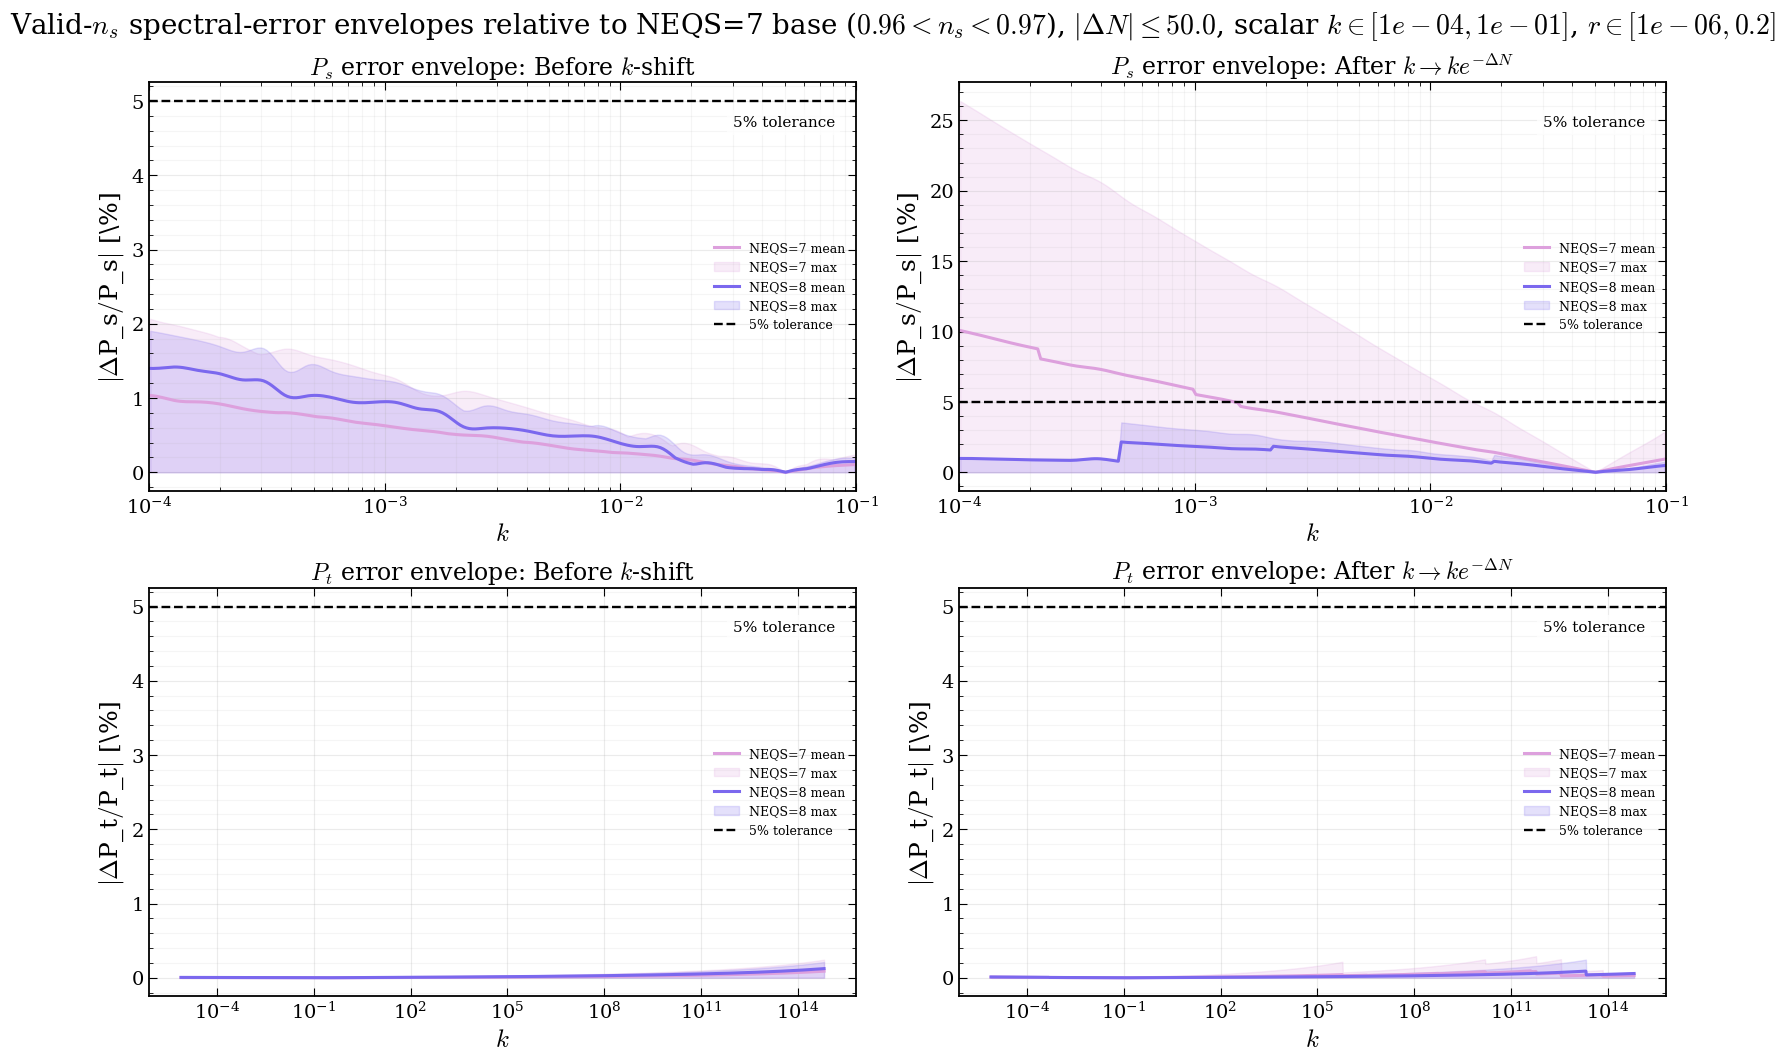


=== Cut summary ===
NEQS=7: kept=13, skipped_ns=0, skipped_r=0, skipped_deltaN=11, skipped_other=6
NEQS=8: kept=4, skipped_ns=0, skipped_r=2, skipped_deltaN=13, skipped_other=11

=== Envelope summary ===
 NEQS       case  n_models  median_mean_abs_pct  max_envelope_pct  k_min_scalar  k_max_scalar  max_abs_deltaN_cut    r_min  r_max
    7 Ps_unshift        13             0.452625          2.067320        0.0001           0.1                50.0 0.000001    0.2
    8 Ps_unshift         4             0.587352          1.905048        0.0001           0.1                50.0 0.000001    0.2
    7   Ps_shift        13             3.786802         26.371963        0.0001           0.1                50.0 0.000001    0.2
    8   Ps_shift         4             0.955457          3.545221        0.0001           0.1                50.0 0.000001    0.2
    7 Pt_unshift        13             0.009410          0.244211           NaN           NaN                50.0 0.000001    0.2
    8 Pt_unshif

In [159]:
model_df, envelope_df = plot_valid_ns_before_after_kshift_envelopes_rminmax(
    base_path_root=base_path_root,
    lam_values_by_neqs=lam_values_by_neqs,
    ref_NEQS=7,
    ref_param="lam4",
    ref_value=3.3375788071e-04, #1.7964939234e-04,
    ns_min=0.96,
    ns_max=0.97,
    r_min=1e-6,
    r_max=0.20,
    k_norm=0.05,
    k_min_scalar=1e-4,
    k_max_scalar=1e-1,
    max_abs_deltaN=50.0,
    skip_zero=True,
    save_name="valid_ns_r_before_after_kshift_nonhiggs.png",
)

We first draw from the full Kinney prior range. Since ns allowed models can end inflation hundreds of e-folds apart, we select a reference model from the densely populated observationally viable region and restrict spectral comparisons to models with comparable inflationary duration, ∣ΔN∣≤15. This avoids comparing distinct inflationary histories while preserving the broad-prior origin of the ensemble.

Typically no one would encounter this, they would have a base model as is that is better than being numerically generated.To test whether the observed convergence/truncation properties are specific to Higgs inflation, we also consider a representative generic inflationary model. This model is obtained by randomly sampling the Kinney slow-roll prior ranges and evolving the flow equations until a viable solution with 0.96<ns<0.97 is obtained. The resulting slow-roll parameters are then used as a reference point for the convergence and truncation analysis.

Unlike the Higgs case, where the reference slow-roll parameters are derived directly from the underlying inflationary potential, the generic model serves only as a numerical benchmark for testing the robustness of the truncation procedure.Higgs inflation provides the physically motivated benchmark. The generic model is not intended to represent a specific inflationary scenario; it is included to demonstrate that the convergence and truncation behavior is not unique to the Higgs-derived hierarchy.

Anotehr way to express this sentiment more fully.

For the generic inflationary test case, the reference model was selected from a viable region of the slow-roll parameter space satisfying the imposed observational constraints. An important consideration is not the precise numerical values of the reference slow-roll parameters, but rather whether the reference model lies within a sufficiently populated region of the ensemble. Models that are highly isolated in inflationary duration can lead to artificially large differences in the number of e-folds at the end of inflation, thereby complicating direct spectral comparisons.

The reference model with $\lambda_4 \simeq 3.34 \times 10^{-4}$ was found to occupy a densely populated region of the viable ensemble, with both NEQS=7 and NEQS=8 realizations exhibiting similar values of $N_{\rm end}$. Consequently, the majority of accepted models satisfy relatively small values of $\Delta N$, allowing meaningful comparisons after applying the $k$-shift correction. In contrast, earlier candidate reference models were separated from much of the viable ensemble by $|\Delta N| \sim 150$--$200$, indicating that they belonged to a substantially different inflationary trajectory. Such models are less suitable as reference points for a truncation analysis because the resulting spectral differences are dominated by large shifts in inflationary duration rather than by the truncation of the slow-roll hierarchy itself.

For this reason, the truncation study is performed using a reference model located near the center of the viable ensemble in $N_{\rm end}$, ensuring that the comparison probes the stability of the slow-roll truncation rather than differences between physically distinct inflationary histories.

The only thing I can claim right now is that for models occupying the same region of the viable slow-roll ensemble (as measured by comparable Nend, ns, r) truncation at NEQS=8 produces spectra that agree at the few-percent level after accounting for the ΔN shift. I cannot claim that the entire Kinney prior volume converges at NEQS=8.

Prettily:
The broad Kinney prior admits viable models spanning a wide range of inflationary durations. Consequently, direct comparisons between all accepted models are not meaningful, as large differences in N
end correspond to substantially different inflationary histories. Restricting attention to models within a common region of parameter space, characterized by similar Nend, allows the truncation error to be isolated from trajectory-dependent effects. Within this subset, NEQS=8 reproduces both scalar and tensor spectra to better than approximately 5% after application of the ΔN correction.